In [1]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Para el excel del mercado laboral

In [2]:
%pip install xlrd
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Para grafos

In [3]:
pip install libpysal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
!pip install matplotlib pyarrow
%pip install geopandas, libpysal, pickle, libpysal


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'geopandas,'

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
%pip install xgboost lightgbm shap scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\oriol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import json
import os
from typing import Dict, Union
import seaborn as sns
import geopandas as gpd
import pickle
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


#Limpieza de datos
from limpieza.votos import limpieza_votos_partidos, generar_columnas_pct_votos, SLOT_MAPPING_DEFAULT, SLOT_MAPPING_2023
from limpieza.rentas import procesar_archivo_ine, procesar_archivo_gini, procesar_fuente_ingresos
from limpieza.paro_contratos import limpiar_y_exportar_sepe
from limpieza.superficie import procesar_geografia_municipios
from limpieza.poblacion import procesar_poblacion_maestro
from limpieza.funciones_genericas_limpieza import leer_json, leer_archivo_csv
from limpieza.renta_navarra import generar_renta_con_navarra
from limpieza.edad_media import procesar_edad_media_municipios, procesar_edad_media_provincias

#EDA
from EDA.demografia_superficie import eda_demografia_superficie
from EDA.edad_media import eda_edad_media
from EDA.mercado_laboral import eda_mercado_laboral
from EDA.desigualdad_renta import gestion_nulos_desigualdad, eda_gini_p80p20, analizar_similitud_vecinal_economica
from EDA.fuente_ingresos_renta import eda_fuente_ingresos
from EDA.indicadores_renta import eda_indicadores_renta, visualizar_histogramas_renta
from EDA.votos import eda_votos_granularidad_total, analizar_umbral_votos_nacional, participacion_electoral, participacion_electoral_100, eda_slots_pct_votos
from EDA.funciones_generales import unificar_datos_eda, imputar_datos_socioeconomicos, analizar_correlaciones_eda
from EDA.grafos_estructura import generar_grafo_adyacencia, visualizar_grafo_maestro

#Modelos
from modelos.entrenamiento import entrenar_modelos, cargar_modelos
from modelos.evaluacion import evaluar_modelos, visualizar_metricas, comparar_real_predicho
from modelos.prediccion import pipeline_prediccion
from modelos.shap_analysis import analizar_shap_partido, analizar_shap_todos, importancia_global_shap, heatmap_importancia_shap, heatmap_direccion_shap
from modelos.tuning.busqueda import tunear_todos_modelos
from modelos.tuning.comparacion import pipeline_comparacion
from modelos.subgrupos import entrenar_modelos_subgrupos, evaluar_modelos_subgrupos, pipeline_prediccion_subgrupos
from modelos.v2 import pipeline_prediccion_v2, entrenar_modelos_v2, evaluar_modelos_v2



#Ley d'hont
import json
from calculos_electorales.pipeline_dhondt import pipeline_comparacion_dhondt
from calculos_electorales.resultados import votos_predichos_por_provincia, tabla_escanos
from calculos_electorales.dhondt import dhondt_todas_provincias, escanos_por_provincia
from calculos_electorales.visualizacion import pipeline_visualizacion


# Función ETL limpieza
Creamos una función la cual segun los años nos crea el listado de bases datos a gtraves de procesar los datos en sucio y transformarlos en data limpia.

In [7]:
def ETL_limpieza(year: Union[int, str], config_path: str = "config_path.json") -> Dict[str, pd.DataFrame]:
    """
    Funcion orquestadora ETL de los archivos de la carpeta "limpieza".
    Orquesta la ejecucion de funciones individuales de limpieza, gestiona la
    cache segun el estado de los archivos y carga los resultados
    en memoria inyectandolos como variables globales.
    Args:
        year (Union[int, str]): Anio objetivo para procesar los datos.
        config_path (str, optional): Ruta al archivo JSON de configuracion. Por defecto "config_path.json".
    Returns:
        Dict[str, pd.DataFrame]: Diccionario con los DataFrames instanciados.
    Raises:
        ValueError: Si el anio proporcionado no esta definido en el config.
    """
    year_str = str(year)

    config = leer_json(config_path)

    if year_str not in config:
        raise ValueError(f"El anio {year_str} no existe en el archivo {config_path}.")

    raw_paths = config[year_str]["raw"]
    proc_paths = config[year_str]["processed"]

    dataframes: Dict[str, pd.DataFrame] = {}

    for clave, ruta_procesada in proc_paths.items():
        nombre_df = f"df_{year_str}_{clave}"
        es_carpeta = "carpeta" in clave.lower()

        ya_procesado = False
        archivos_votos_esperados = []

        if clave == "carpeta_votos":
            archivos_votos_esperados = [
                f"arbol_candidaturas_{year_str}.json",
                f"candidaturas_ideologia_{year_str}.json",
                f"maestro_ideologia_{year_str}.json",
                f"Votos_Agrupados_Padres_{year_str}.csv",
                f"Votos_Granularidad_Total_{year_str}.csv"
            ]
            if os.path.exists(ruta_procesada):
                ya_procesado = all(
                    os.path.exists(os.path.join(ruta_procesada, arch))
                    for arch in archivos_votos_esperados
                )
        else:
            ya_procesado = os.path.exists(ruta_procesada)

        if not ya_procesado:
            if es_carpeta:
                os.makedirs(ruta_procesada, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(ruta_procesada), exist_ok=True)

            try:
                if clave in ["poblacion_csv", "poblacion_json"]:
                    ruta_json = proc_paths["poblacion_json"]
                    ruta_csv = proc_paths["poblacion_csv"]
                    if not (os.path.exists(ruta_json) and os.path.exists(ruta_csv)):
                        procesar_poblacion_maestro(
                            path_lectura=raw_paths["poblacion"],
                            path_salida_json=ruta_json,
                            path_salida_csv=ruta_csv
                        )

                elif clave == "paro_contratos":
                    limpiar_y_exportar_sepe(raw_paths["paro_contratos"], ruta_procesada)

                elif clave == "geografia":
                    procesar_geografia_municipios(raw_paths["geografia"], ruta_procesada)

                elif clave == "carpeta_votos":
                    limpieza_votos_partidos(
                        fichero_cis=raw_paths["ideologias"],
                        fichero_03=raw_paths["votos_candidaturas"],
                        fichero_05=raw_paths["votos_municipios_totales"],
                        fichero_06=raw_paths["Votos_candidaturas_agrupados"],
                        ruta_guardado=ruta_procesada,
                        anio=year_str
                    )

                elif clave == "votos_pct":
                    mapping = SLOT_MAPPING_2023 if year_str == "2023" else SLOT_MAPPING_DEFAULT
                    generar_columnas_pct_votos(
                        csv_votos_granular=os.path.join(proc_paths["carpeta_votos"], f"Votos_Granularidad_Total_{year_str}.csv"),
                        anio=year_str,
                        output_file=ruta_procesada,
                        slot_mapping=mapping
                    )

                elif clave == "datos_unificados":
                    unificar_datos_eda(int(year_str))

                elif clave == "renta_disponible":
                    procesar_archivo_ine(raw_paths["renta_disponible"], ruta_procesada)

                elif clave == "GINI_P80P20":
                    procesar_archivo_gini(raw_paths["GINI_P80P20"], ruta_procesada)

                elif clave == "fuente_ingresos":
                    procesar_fuente_ingresos(raw_paths["fuente_ingresos"], ruta_procesada)

                elif clave == "renta_navarra":
                    generar_renta_con_navarra(año=int(year_str))

                elif clave == "edad_media_municipios":
                    procesar_edad_media_municipios(
                        raw_paths["edad_media_municipios"], int(year_str), ruta_procesada
                    )

                elif clave == "edad_media_provincias":
                    procesar_edad_media_provincias(
                        raw_paths["edad_media_provincias"], int(year_str), ruta_procesada
                    )

            except Exception as e:
                print(f"Error al procesar '{clave}': {e}")

        # --- CARGA DE DATOS EN MEMORIA ---
        if not es_carpeta:
            if os.path.exists(ruta_procesada):
                try:
                    if ruta_procesada.endswith('.csv'):
                        dataframes[nombre_df] = leer_archivo_csv(ruta_procesada, decimal='.')
                    elif ruta_procesada.endswith('.json'):
                        dataframes[nombre_df] = pd.read_json(ruta_procesada)
                except Exception as e:
                    print(f"Error al cargar archivo '{nombre_df}': {e}")

        elif clave == "carpeta_votos":
            for archivo in archivos_votos_esperados:
                ruta_archivo = os.path.join(ruta_procesada, archivo)

                if os.path.exists(ruta_archivo):
                    nombre_sin_ext = os.path.splitext(archivo)[0]
                    nombre_df_carpeta = f"df_{year_str}_{nombre_sin_ext}"

                    try:
                        if archivo.endswith('.csv'):
                            dataframes[nombre_df_carpeta] = leer_archivo_csv(ruta_archivo, decimal='.')
                        elif archivo.endswith('.json'):
                            dataframes[nombre_df_carpeta] = pd.read_json(ruta_archivo)
                    except Exception as e:
                        print(f"Error al cargar el archivo '{archivo}': {e}")

    print(f"\nETL COMPLETADO ({year_str})")
    print("DataFrames generados y listos como variables:")
    for df_name in dataframes.keys():
        print(f"{df_name}")

    globals().update(dataframes)

    return dataframes

In [8]:
dataframes = ETL_limpieza(2023, "config_path.json")


ETL COMPLETADO (2023)
DataFrames generados y listos como variables:
df_2023_arbol_candidaturas_2023
df_2023_candidaturas_ideologia_2023
df_2023_maestro_ideologia_2023
df_2023_Votos_Agrupados_Padres_2023
df_2023_Votos_Granularidad_Total_2023
df_2023_votos_pct
df_2023_renta_disponible
df_2023_GINI_P80P20
df_2023_fuente_ingresos
df_2023_renta_navarra
df_2023_paro_contratos
df_2023_geografia
df_2023_poblacion_json
df_2023_poblacion_csv
df_2023_edad_media_municipios
df_2023_edad_media_provincias
df_2023_datos_unificados


In [9]:
dataframes_2019 = ETL_limpieza(2019, "config_path.json")


ETL COMPLETADO (2019)
DataFrames generados y listos como variables:
df_2019_arbol_candidaturas_2019
df_2019_candidaturas_ideologia_2019
df_2019_maestro_ideologia_2019
df_2019_Votos_Agrupados_Padres_2019
df_2019_Votos_Granularidad_Total_2019
df_2019_votos_pct
df_2019_renta_disponible
df_2019_GINI_P80P20
df_2019_fuente_ingresos
df_2019_renta_navarra
df_2019_paro_contratos
df_2019_geografia
df_2019_poblacion_json
df_2019_poblacion_csv
df_2019_edad_media_municipios
df_2019_edad_media_provincias
df_2019_datos_unificados


# EDA 2019
PAra esto planteo fases y objetivos para no perder la idea durante el proceso

## Fase 1: Análisis de "Salud" y Distribución (Univariante)
En esta fase analizamos cada fichero por separado. Trabajaremos con los datos de 2019.

### 1.1. Demografía y Superficie, contexto físico
* Calcular la Densidad de Población (población_total / superficie_km2).

RESUMEN DEMOGRÁFICO
Población total: 47,026,208 habitantes



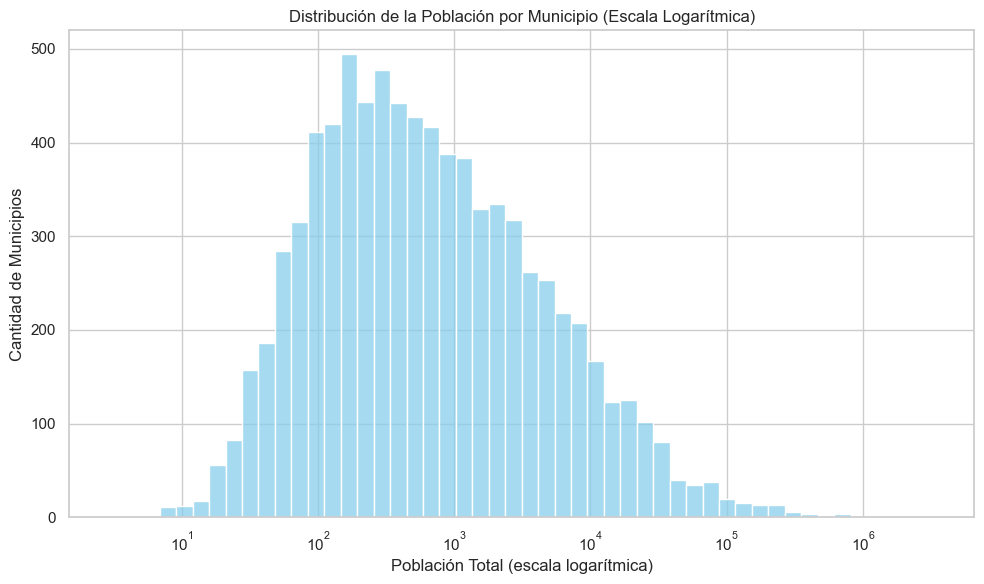

10 MUNICIPIOS MÁS POBLADOS
 1. Madrid                         |  3,266,126 habs.
 2. Barcelona                      |  1,636,762 habs.
 3. València                       |    794,288 habs.
 4. Sevilla                        |    688,592 habs.
 5. Zaragoza                       |    674,997 habs.
 6. Málaga                         |    574,654 habs.
 7. Murcia                         |    453,258 habs.
 8. Palma                          |    416,065 habs.
 9. Palmas de Gran Canaria, Las    |    379,925 habs.
10. Bilbao                         |    346,843 habs.

10 MUNICIPIOS MENOS POBLADOS
 1. Illán de Vacas                 |          3 habs.
 2. Villarroya                     |          5 habs.
 3. Jaramillo Quemado              |          7 habs.
 4. Arandilla del Arroyo           |          7 habs.
 5. Valtablado del Río             |          7 habs.
 6. Estepa de San Juan             |          7 habs.
 7. Castilnuevo                    |          8 habs.
 8. Valdemadera          

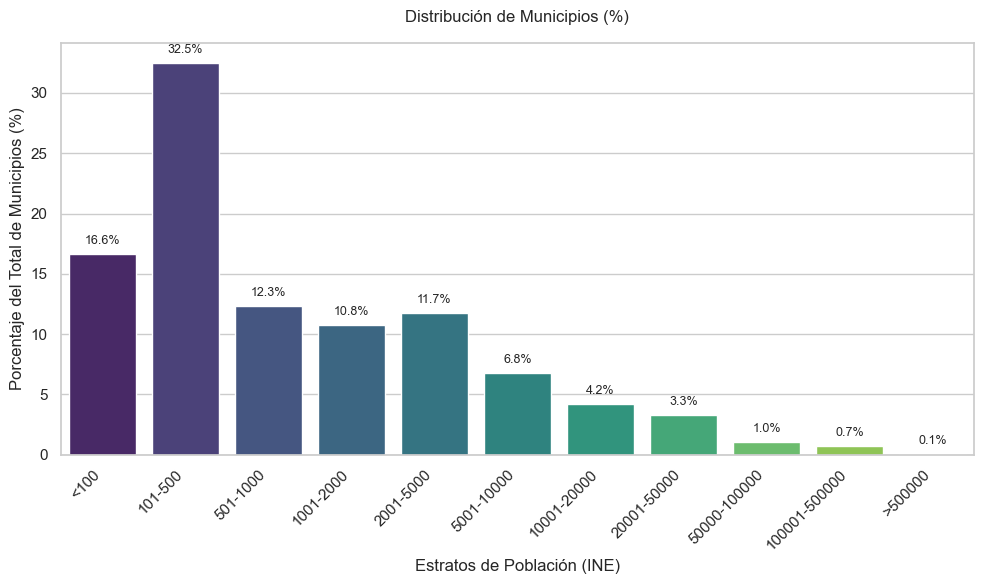

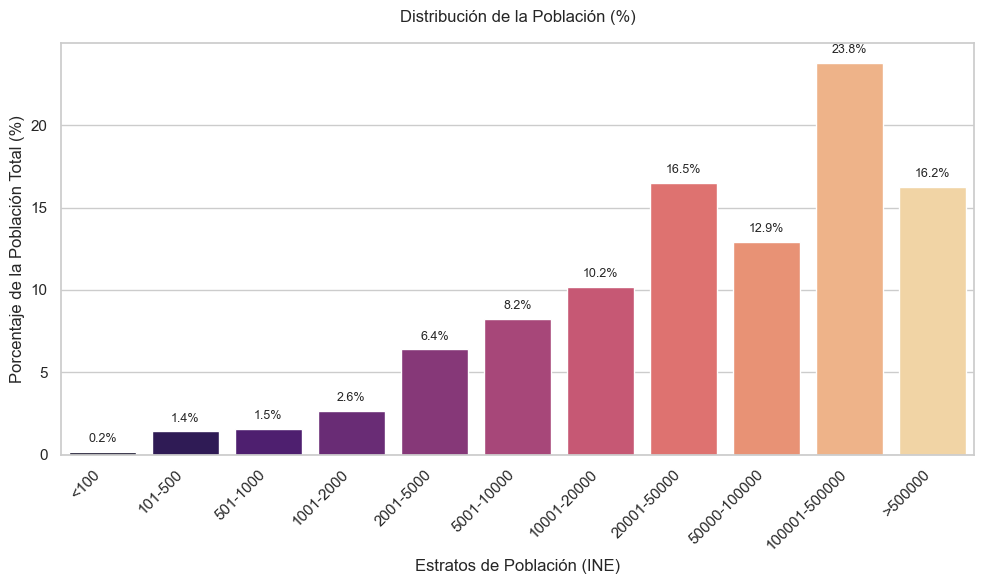

CONTROL DE CALIDAD GEOGRÁFICO
Densidad media nacional: 93.17 hab/km2
Municipios con superficie 0 o negativa: 0
Municipios con latitud fuera de rango: 0
Municipios con longitud fuera de rango: 0


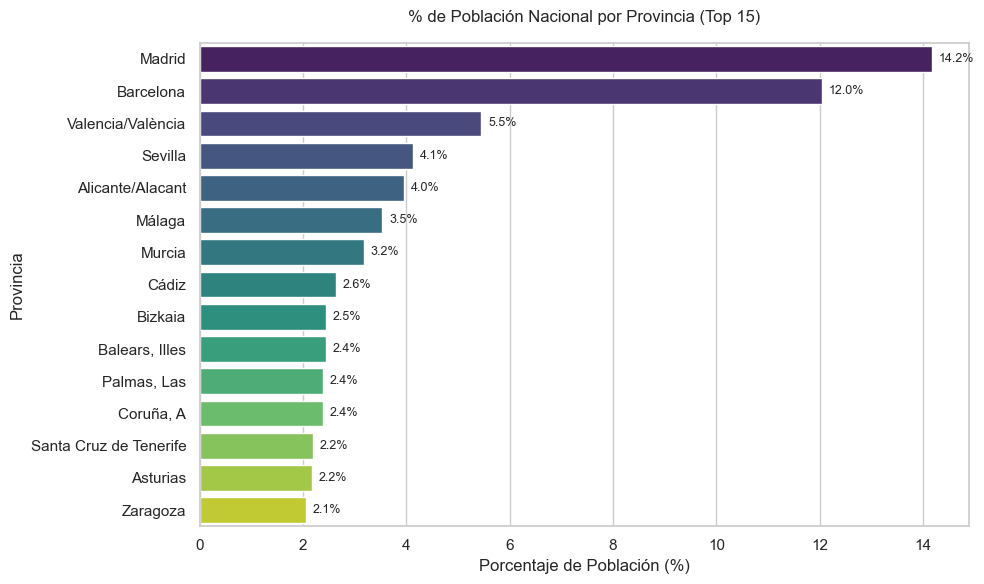

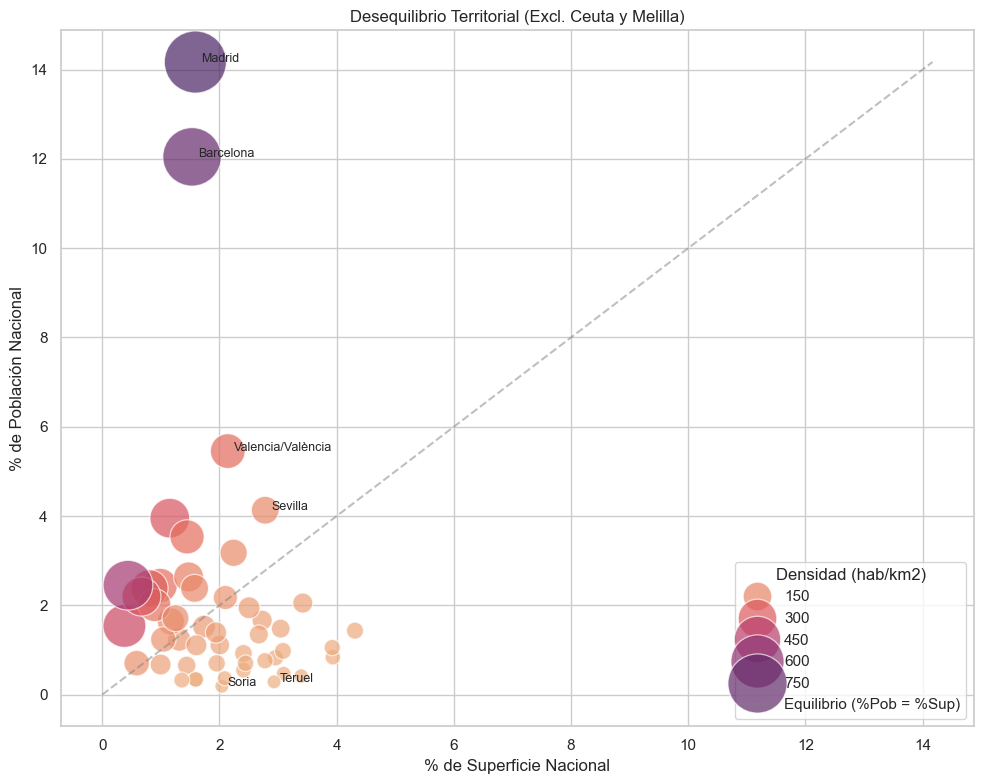

RESUMEN ESTADÍSTICO: CIUDADES AUTÓNOMAS (Excluidas del gráfico por densidad extrema)
- Ceuta: 84,777 hab | 19.87 km2 | Densidad: 4,266.58 hab/km2
- Melilla: 86,487 hab | 14.24 km2 | Densidad: 6,072.33 hab/km2


In [10]:
df_poblacion_superficie_2019 = eda_demografia_superficie(df_pob=df_2019_poblacion_csv, data_json=df_2019_poblacion_json, df_sup=df_2019_geografia)

Al hacer un primer análisis de los municipios y de cómo está distribuida la población española en 2019, podemos observar un fuerte contraste: los municipios con menos de 500 habitantes representan el 49,1% del total de municipios del Estado español, pero agrupan únicamente al 1,6% de la población. Por el contrario, los grandes municipios (aquellos de más de 100.000 habitantes) representan apenas el 0,8% de los ayuntamientos, pero concentran al 40% de la población. Destaca especialmente que la mayor acumulación demográfica se da en las ciudades de entre 100.000 y 500.000 habitantes, que por sí solas agrupan al 23,8% del total nacional.

Al observar el histograma de la distribución de la población, vemos que la mayor concentración de municipios se encuentra entre $10^2$ y $10^3$ en el eje X, lo que corresponde a poblaciones de entre 100 y 1.000 habitantes. En una escala lineal, esta variable presenta una fuerte asimetría con un marcado sesgo positivo (una larga cola hacia la derecha debido a unas pocas ciudades gigantes). Sin embargo, al aplicar la escala logarítmica, comprobamos que los datos adoptan una forma de campana, lo que indica que la población municipal en España sigue una distribución estadística log-normal.

Por último, si analizamos los extremos, vemos una enorme brecha demográfica. Los seis municipios más poblados del país superan el medio millón de habitantes, en un top 10 encabezado por Madrid (con 3.266.126 habitantes) y que cierra Bilbao en décima posición con más de 340.000 vecinos. En su contraparte, los 10 municipios menos poblados no logran superar los 8 habitantes. El municipio con menor población es Illán de Vacas, con únicamente 3 personas empadronadas, mientras que Villanueva de Gormaz marca el límite de este top 10 por abajo con 8 habitantes (un puesto que comparte con varios municipios más en esa misma situación).


Posteriormente, al trasladar el análisis al nivel provincial, se observa que Madrid y Barcelona se consolidan como los grandes polos demográficos, acumulando por sí solas el 26,2% de la población nacional. El diagrama de dispersión (scatterplot) aporta una perspectiva clave sobre este fenómeno mediante tres variables:

* Densidad Poblacional: Representada por el tamaño de las esferas, permite identificar visualmente la concentración de habitantes por kilómetro cuadrado, destacando de nuevo a las provincias de Madrid y Barcelona.

* Línea de Equilibrio (Bisectriz): Esta línea discontinua representa una distribución teórica ideal donde el peso demográfico de una provincia equivale a su peso territorial.

* Identificación de Desequilibrios: Las provincias situadas por debajo de la línea (como Soria o Teruel) muestran un claro desequilibrio territorial: poseen un alto porcentaje de superficie pero una baja carga demográfica. Al tener garantizado por ley un mínimo de dos escaños en el Congreso, estas provincias presentan una sobrerrepresentación electoral en relación con su censo.

En este análisis, se ha optado por excluir a las ciudades autónomas de Ceuta y Melilla del gráfico de dispersión. Al tratarse de entornos puramente urbanos con superficies muy reducidas, sus densidades extremas distorsionaban la escala visual del resto de provincias; no obstante, su peso ha sido documentado estadísticamente por separado. Por el contrario, las provincias situadas por encima de la línea (aquellas con mayor concentración de habitantes) sufren una subrepresentación, ya que, aunque eligen un mayor número de diputados, reciben menos de los que les corresponderían en un sistema de reparto estrictamente proporcional sin mínimos territoriales.


**Conclusiones: Impacto en el Sistema Electoral y la Ley D'Hondt**

Esta polarización demográfica es la raíz de la desproporcionalidad electoral en España. Al utilizar la provincia como circunscripción y asignar un mínimo de dos escaños fijos a cada una, el sistema transfiere peso político desde las urbes hacia el territorio.

La gran masa de municipios de menos de 500 habitantes (el 49,1% del total nacional) da lugar a provincias extensas pero poco pobladas, ubicadas bajo la línea de equilibrio, que actúan como circunscripciones pequeñas. En estas zonas, la fórmula D'Hondt agudiza el sesgo: al repartirse pocos escaños (2 o 3), el "precio" del diputado en votos es mucho más bajo, pero los partidos minoritarios quedan excluidos al no alcanzar los altos umbrales necesarios.

En consecuencia, el diseño actual otorga un peso electoral desproporcionado a las áreas rurales frente a los grandes núcleos urbanos (que concentran al 40% de la población en solo el 0,8% de los municipios), rompiendo la máxima de "un persona, un voto" en favor de la representación territorial.

*NOTA: las franjas para separar la población han sido basadas en como el INE separa las provincias según el padron: "https://www.ine.es/jaxiPx/Tabla.htm?path=/t20/e245/p04/a2002/l0/&file=000an001.px&L=0"*

Antes de abordar el mercado laboral, analizaremos la edad media de los municipios urbanos y las provincias. Debido a que el INE solo publica datos con este nivel de granularidad, no es posible realizar el análisis a escala municipal.


  EDA EDAD MEDIA - 2019

[1/3] Provincias - Ambos sexos
  Edad media Total Nacional (2019): 43.37 anos
  Rango provincial: 35.48 - 50.80 anos


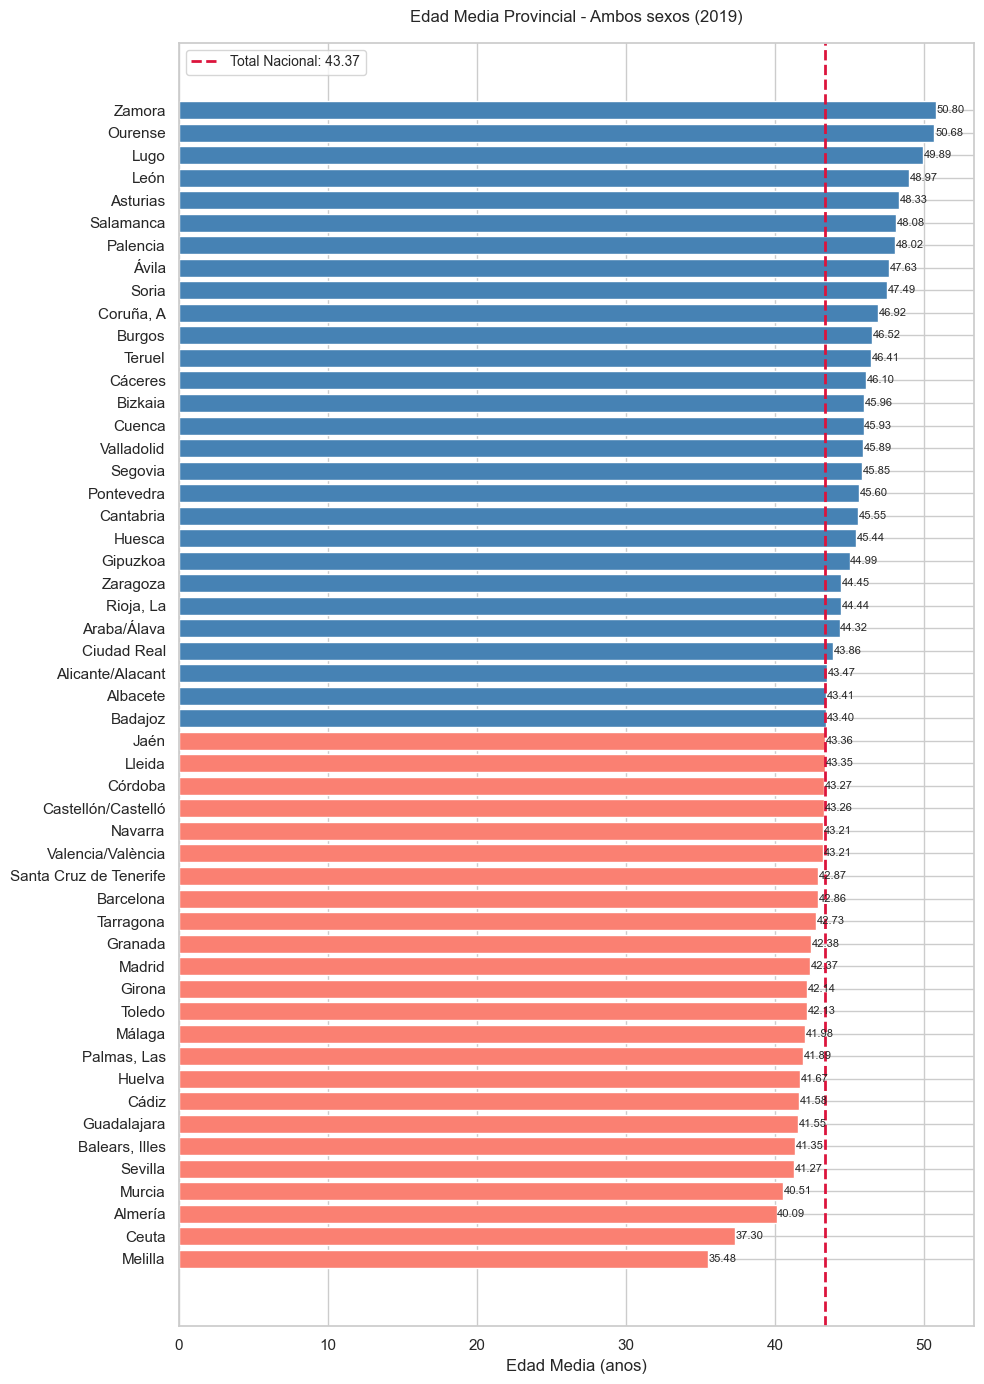


[2/3] Provincias - Por genero
  Hombres - Total Nacional (2019): 42.06 anos


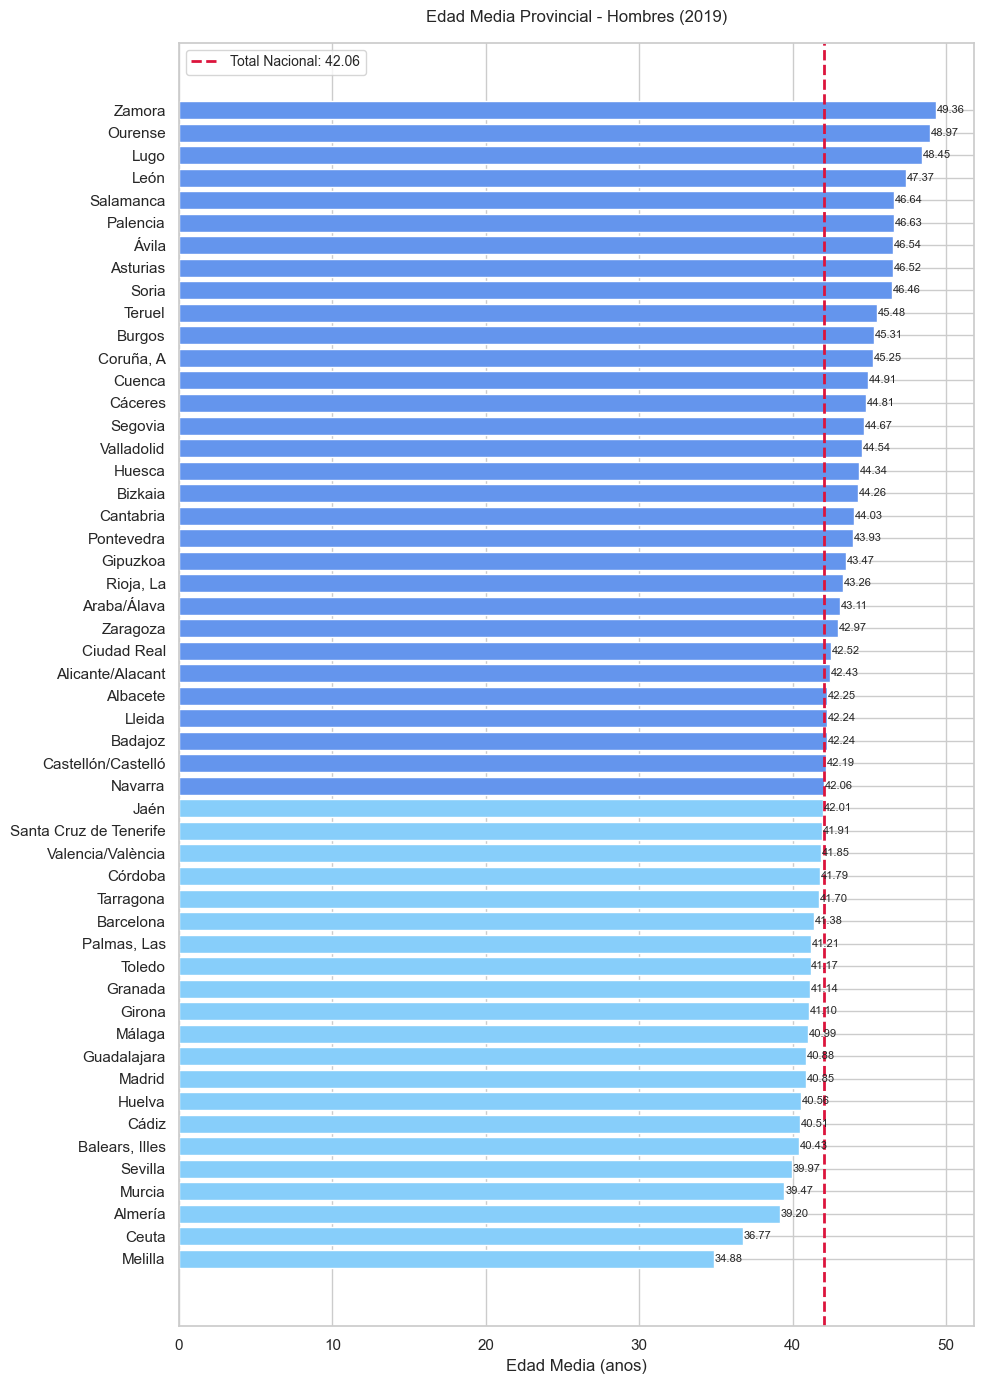

  Mujeres - Total Nacional (2019): 44.63 anos


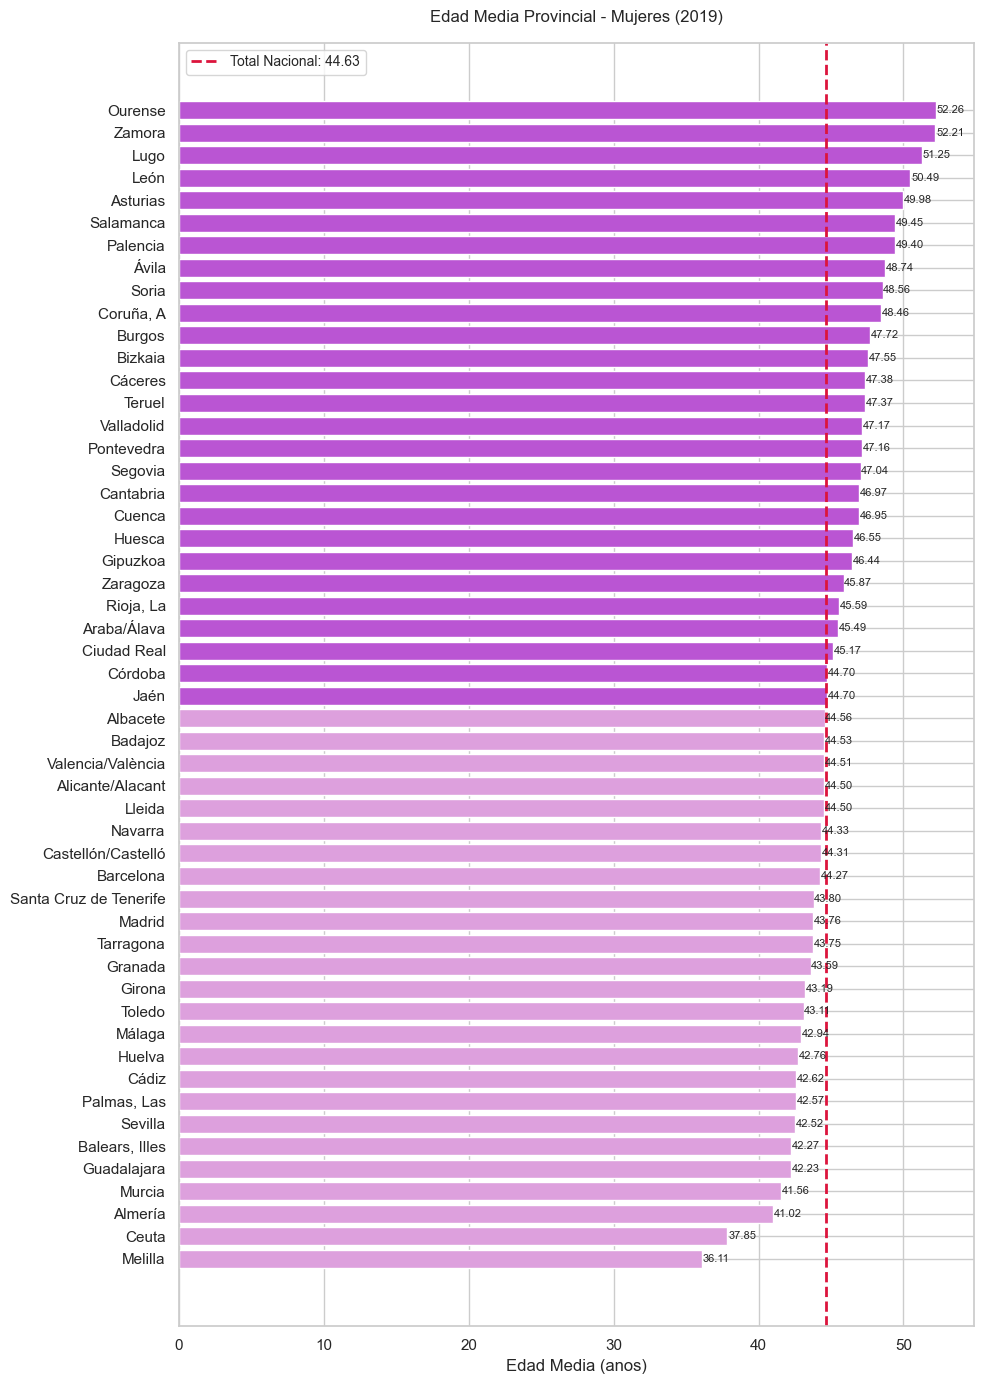


[3/3] Municipios
  Ambos sexos — municipios con dato: 150 | media: 42.50 | rango: 35.61 - 48.99 anos


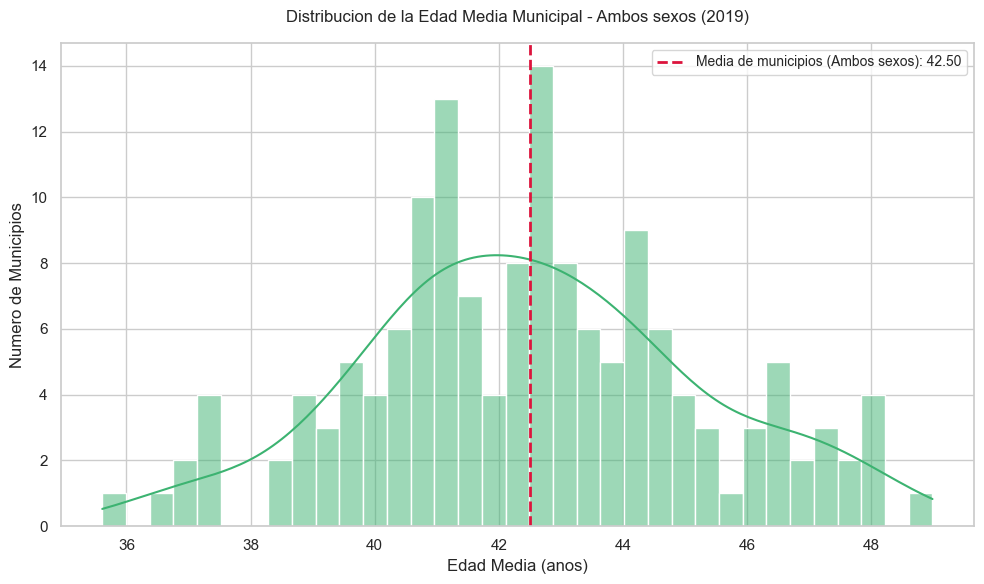

  Hombres — municipios con dato: 150 | media: 41.16 | rango: 35.04 - 46.48 anos


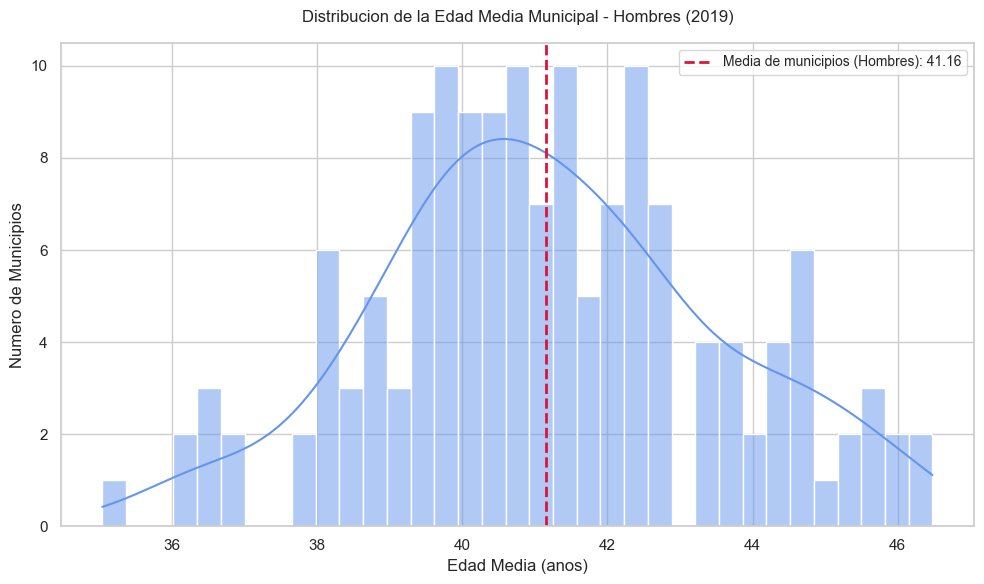

  Mujeres — municipios con dato: 150 | media: 43.75 | rango: 36.19 - 51.21 anos


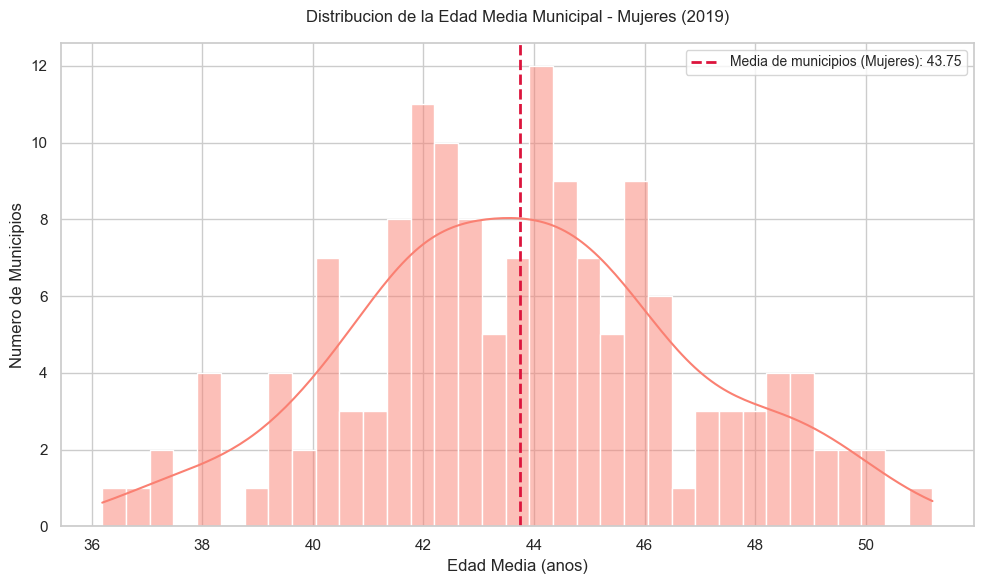

In [11]:
eda_edad_media(
      df_provincias=df_2019_edad_media_provincias,
      df_municipios=df_2019_edad_media_municipios,
      anio=2019
  )

### 1.2. Mercado Laboral (La salud del empleo)

* Sectores: ¿En cuántos municipios domina el sector servicios (p_ser) frente al agrario (p_agr)?
* Brecha: Compara total_paro de hombres vs mujeres.

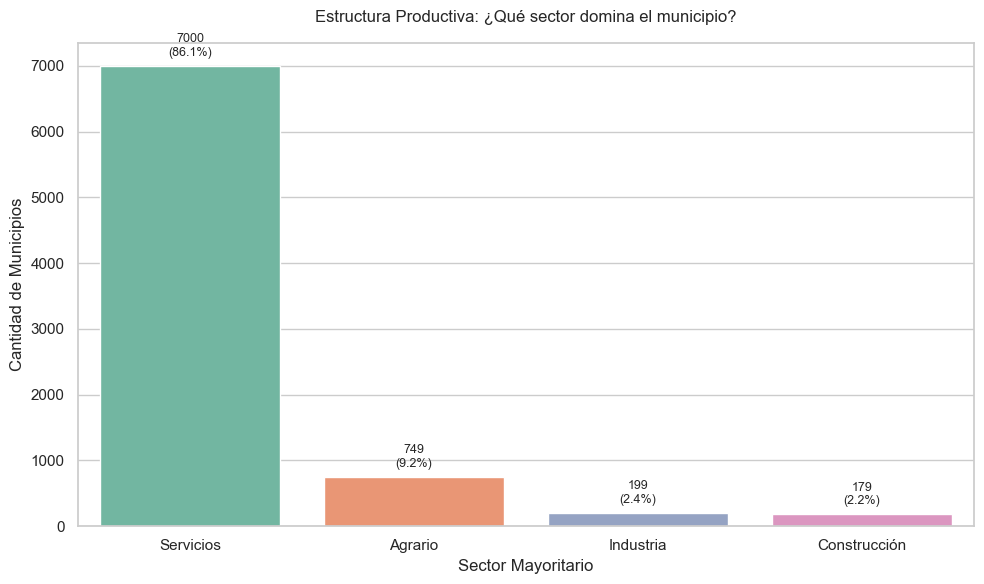

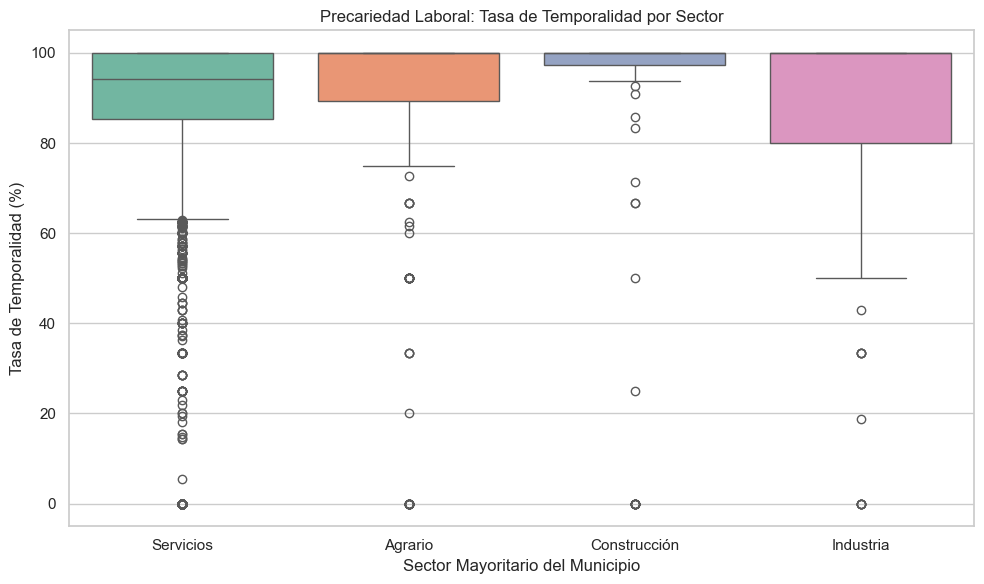

RADIOGRAFÍA DEL MERCADO LABORAL
Temporalidad real nacional (ponderada): 90.3% de los contratos
Peso medio del paro Femenino: 54.2% del total de parados
Peso medio del paro Juvenil (<25): 7.6% del total de parados
Peso medio del paro Senior (>45): 56.3% del total de parados

MÉTRICAS ESTRUCTURALES Y BRECHAS


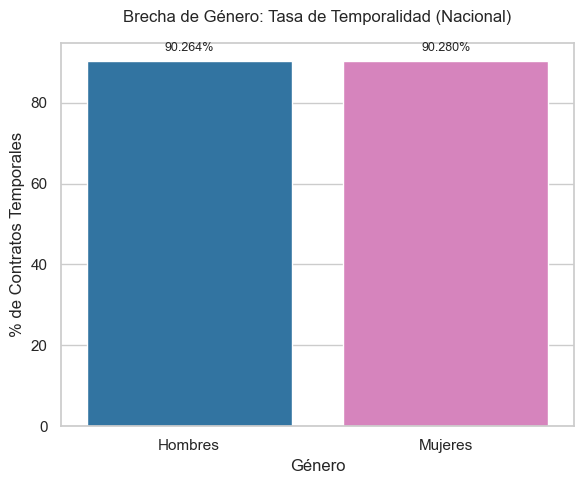

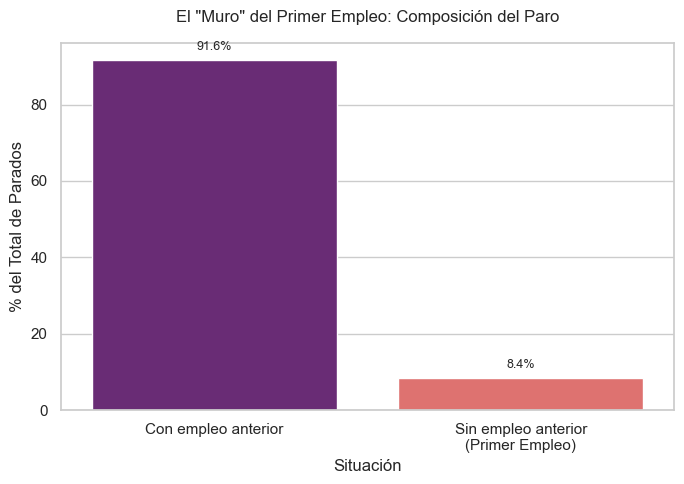

PRIMER EMPLEO: 269,615 parados (8.4% del total nacional) nunca han trabajado.


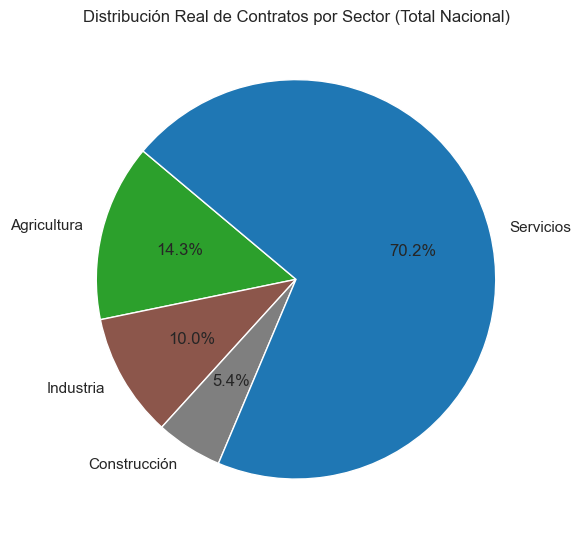

ESTRUCTURA DE CONTRATACIÓN NACIONAL:
Agricultura: 253,072 contratos
Industria: 176,832 contratos
Construcción: 95,032 contratos
Servicios: 1,238,712 contratos


In [12]:
df_mercado_laboral = eda_mercado_laboral(df_paro_contratos = df_2019_paro_contratos)

Los datos analizados corresponden a noviembre de 2019, mes en el que se celebraron las elecciones generales. En cuanto a la estructura de contratación, el sector servicios actúa como el motor principal, representando el 70,2% de los contratos a nivel nacional y consolidándose como el sector mayoritario en 7.000 municipios. Le sigue el sector agrícola, con un 14,3% de los contratos y siendo la principal fuente de empleo en 749 municipios. En tercer lugar, el sector industrial representa el 10% de las firmas, liderando la contratación en 199 localidades. Finalmente, con una presencia territorial similar a la industria pero menor volumen, la construcción agrupa el 5,4% de los contratos, siendo el sector dominante en apenas 179 municipios.

La tasa media de temporalidad nacional en este mes se sitúa en un altísimo 90,3%, al igual que la brecha por genero. Esta cifra, aunque elevada, responde fielmente al contexto socioeconómico del momento: noviembre marca el inicio de las contrataciones estacionales masivas para el Black Friday y la campaña de Navidad. Además, el mercado operaba bajo el marco legal previo a la reforma laboral de 2021, que posteriormente limitaría la contratación eventual, por lo que estas cifras reflejan la precariedad estructural de la época.

Al analizar la demografía del desempleo, se observan claras brechas. El peso medio del paro femenino asciende al 54,2% del total de desempleados. Sin embargo, el colectivo más afectado de forma estructural es el de los trabajadores sénior (mayores de 45 años), quienes suponen el 56,3% de los parados totales. En contraparte, los jóvenes menores de 25 años representan un peso medio del 7,6%. Adicionalmente, los datos revelan una fuerte barrera de entrada al mercado: 269.615 personas, el 8,4% de los parados del país, son demandantes de su primer empleo y nunca han cotizado previamente.

Por último, el análisis de dispersión (boxplot) de la temporalidad por sectores revela dinámicas muy distintas. La construcción presenta una menor dispersión en sus tasas de temporalidad, indicando un comportamiento más homogéneo en todo el país. La industria, en cambio, muestra una mayor variabilidad. Destaca especialmente el sector servicios, que acumula la mayor cantidad de valores atípicos (outliers), lo que evidencia realidades laborales extremadamente polarizadas dependiendo de la vocación turística o comercial de cada municipio.

### 1.3. Renta e Igualdad (El motor económico)
Acción: Filtrar solo las columnas de 2019.

Análisis:
* Indicador Clave: Usa Renta neta media por persona 2019. Mira su media y desviación estándar.
* Desigualdad: Analiza el Índice de Gini 2019. Un Gini alto (>35) indica mucha desigualdad. Mira si esos municipios coinciden con las rentas más altas o bajas.
* Dependencia: Calcula qué porcentaje de los ingresos viene de salario 2019 vs pensiones 2019.

Empezamos por el indice de GINI y el P80P20, tenemos que tener en cuenta que el ine no publica datos de los municipios de menos de 500 habitantes por secretos estadisticos, ademas Pais vasco y Navarra tienen regimenes forales propios por lo que puede faltar información. 


AUDITORÍA DE DATOS FALTANTES DESIGUALDAD (2019)
Total de municipios en el dataset: 8139
Nulos en Gini (Índice de Gini 2019):      1693 municipios (20.8% del total)
Nulos en P80/P20 (Distribución de la renta P80/P20 2019):   1693 municipios (20.8% del total)


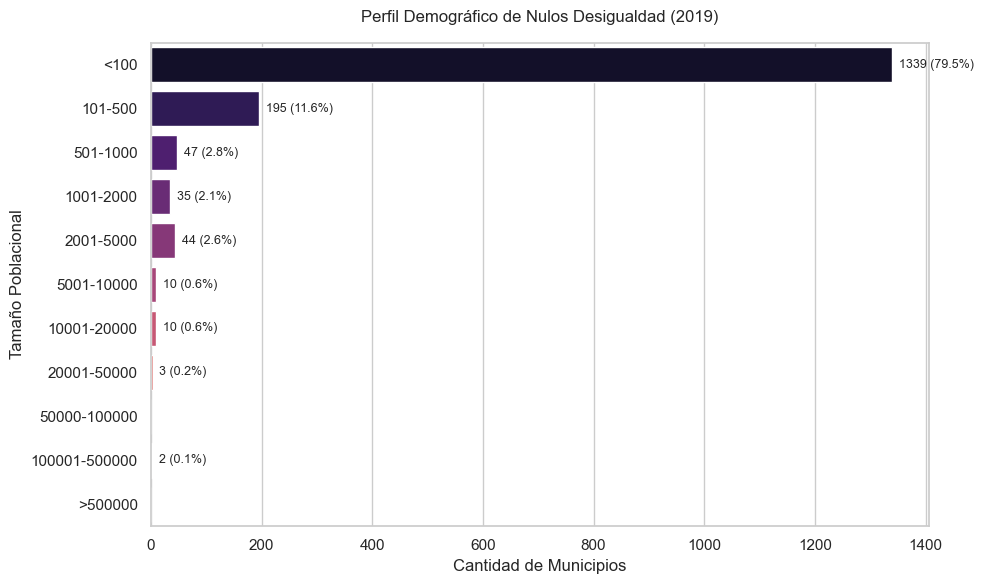


IMPACTO POR PROVINCIA Desigualdad (2019)
Top 10 provincias con más nulos Desigualdad:
 - Navarra             :  272 municipios (16.1%)
 - Guadalajara         :  182 municipios (10.8%)
 - Burgos              :  171 municipios (10.1%)
 - Soria               :  118 municipios (7.0%)
 - Ávila               :  100 municipios (5.9%)
 - Teruel              :   96 municipios (5.7%)
 - Zaragoza            :   88 municipios (5.2%)
 - Salamanca           :   87 municipios (5.2%)
 - Segovia             :   79 municipios (4.7%)
 - Cuenca              :   78 municipios (4.6%)

ANÁLISIS DE EXCEPCIONES AL SECRETO ESTADÍSTICO (<= 100 hab. en 2019)
Se han encontrado 13 municipios con datos a pesar de su pequeño tamaño (<= 100 hab).

RESUMEN DE EXCEPCIONES POR PROVINCIA:
 - Guadalajara: 2 municipio(s)
 - Cáceres: 1 municipio(s)
 - Castellón/Castelló: 1 municipio(s)
 - Cuenca: 1 municipio(s)
 - Huesca: 1 municipio(s)
 - Lleida: 1 municipio(s)
 - Salamanca: 1 municipio(s)
 - Soria: 1 municipio(s)
 - Tarra

In [13]:
gestion_nulos_desigualdad(df_gini = df_2019_GINI_P80P20, df_pob= df_poblacion_superficie_2019, anyo="2019")

En primer lugar, observamos que hay ocho municipios que ya no existen, lo cual se debe a que fueron fusionados con otros en el pasado. Por otro lado, Navarra presenta valores nulos en todos sus municipios; este es un punto clave de análisis dada su condición de comunidad foral uniprovincial. Asimismo, la norma de omitir datos en municipios con una población igual o inferior a 100 habitantes se incumple en 13 casos, una muestra demasiado pequeña para extrapolar los resultados al resto de las localidades.

Podemos observar que, en cuanto a los indicadores económicos, la Comunidad Foral de Navarra no publica sus datos junto al resto de comunidades autónomas en el INE. Por ello, obtenemos esta información de Nastat (https://nastat.navarra.es/es/tablas_powerbi/-/tag/estadistica-renta). Aunque no disponemos exactamente de los mismos indicadores que para el resto de las comunidades, sí contamos con una gran parte de ellos, lo que nos permite enriquecer nuestro conjunto de datos sobre esta región. Aplicamos nuevamente las funciones de ETL, las cuales nos devuelven un dataframe con todos los indicadores económicos del conjunto del Estado español. 

In [14]:
df_renta_completa = generar_renta_con_navarra(año=2019)

Iniciando proceso de integración para el año 2019...
Éxito: Archivo 'renta_con_navarra_2019.csv' generado correctamente.


Volvemos a mirar la cantidad de NA, pero con los datos de Navarra.


AUDITORÍA DE DATOS FALTANTES DESIGUALDAD (2019)
Total de municipios en el dataset: 8139
Nulos en Gini (Índice de Gini):      1421 municipios (17.5% del total)
Nulos en P80/P20 (Distribución de la renta P80/P20):   1421 municipios (17.5% del total)


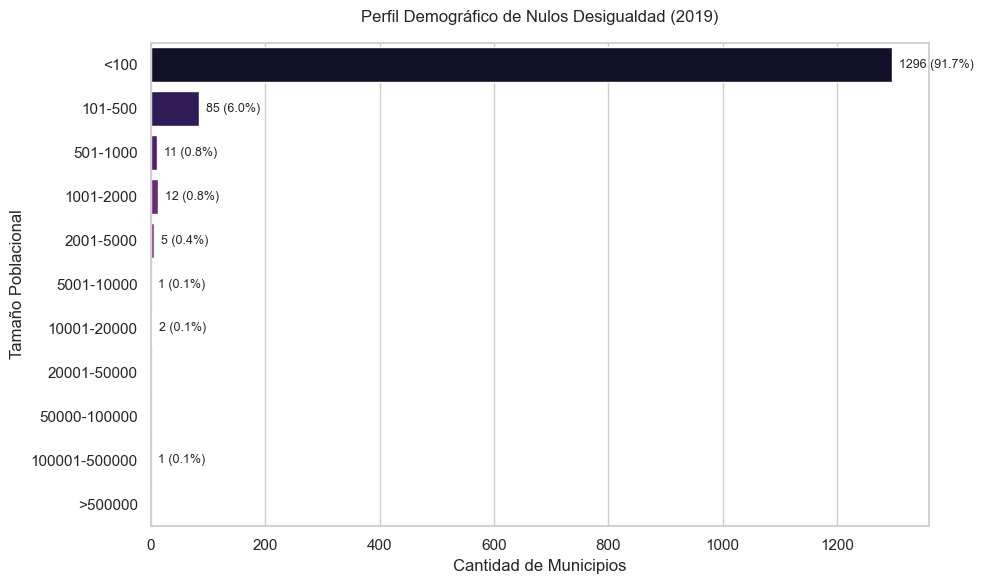


IMPACTO POR PROVINCIA Desigualdad (2019)
Top 10 provincias con más nulos Desigualdad:
 - Guadalajara         :  182 municipios (12.9%)
 - Burgos              :  171 municipios (12.1%)
 - Soria               :  118 municipios (8.4%)
 - Ávila               :  100 municipios (7.1%)
 - Teruel              :   96 municipios (6.8%)
 - Zaragoza            :   88 municipios (6.2%)
 - Salamanca           :   87 municipios (6.2%)
 - Segovia             :   79 municipios (5.6%)
 - Cuenca              :   78 municipios (5.5%)
 - Palencia            :   76 municipios (5.4%)

ANÁLISIS DE EXCEPCIONES AL SECRETO ESTADÍSTICO (<= 100 hab. en 2019)
Se han encontrado 56 municipios con datos a pesar de su pequeño tamaño (<= 100 hab).

RESUMEN DE EXCEPCIONES POR PROVINCIA:
 - Navarra: 43 municipio(s)
 - Guadalajara: 2 municipio(s)
 - Cáceres: 1 municipio(s)
 - Cuenca: 1 municipio(s)
 - Castellón/Castelló: 1 municipio(s)
 - Huesca: 1 municipio(s)
 - Lleida: 1 municipio(s)
 - Salamanca: 1 municipio(s)
 - Sor

In [15]:
gestion_nulos_desigualdad( df_gini = df_renta_completa.reset_index(), df_pob = df_poblacion_superficie_2019, anyo = "2019")

 INICIANDO ANÁLISIS DE DESIGUALDAD Y RENTA (2019)
Info: 1421 de 8139 municipios NO tienen datos de renta en 2019.

TOP 10 MUNICIPIOS MÁS DESIGUALES (2019)
 1. 25363.0                   | Gini: 45.2 | Los ricos ganan 2.3x más que los pobres
 2. 25497.0                   | Gini: 45.2 | Los ricos ganan 3.6x más que los pobres
 3. 12835.0                   | Gini: 45.2 | Los ricos ganan 4.6x más que los pobres
 4. 31650.0                   | Gini: 45.2 | Los ricos ganan 2.7x más que los pobres
 5. 21552.0                   | Gini: 45.2 | Los ricos ganan 2.3x más que los pobres
 6. 21134.0                   | Gini: 45.2 | Los ricos ganan 4.6x más que los pobres
 7. 19703.0                   | Gini: 44.9 | Los ricos ganan 4.2x más que los pobres
 8. 16090.0                   | Gini: 44.9 | Los ricos ganan 2.9x más que los pobres
 9. 18400.0                   | Gini: 44.6 | Los ricos ganan 3.0x más que los pobres
10. 17847.0                   | Gini: 44.2 | Los ricos ganan 4.6x más que los po

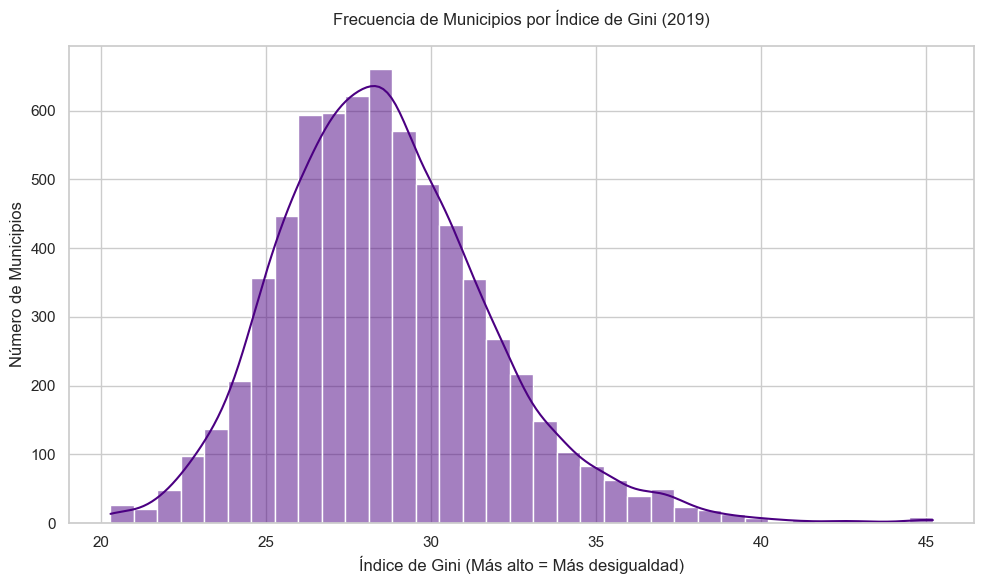

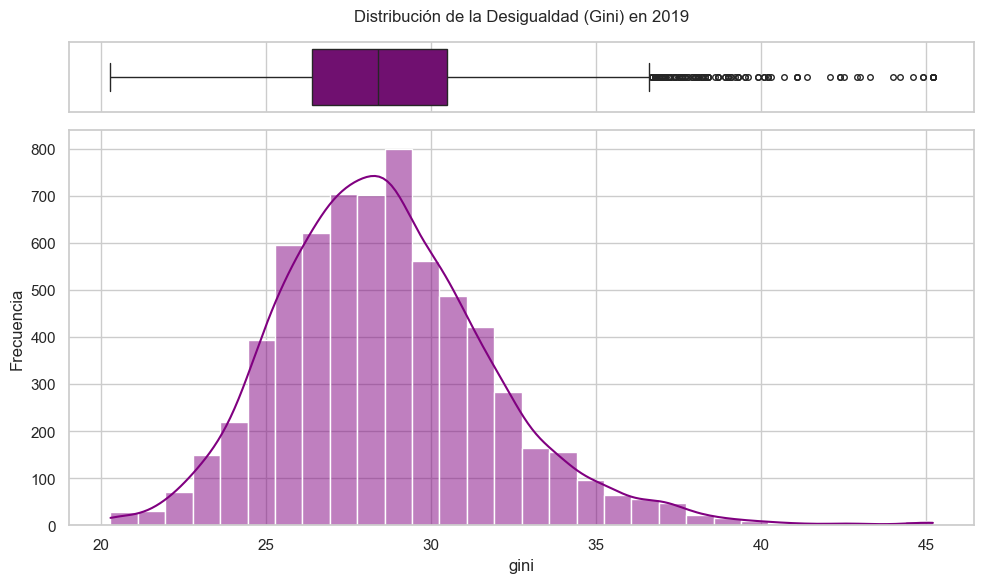

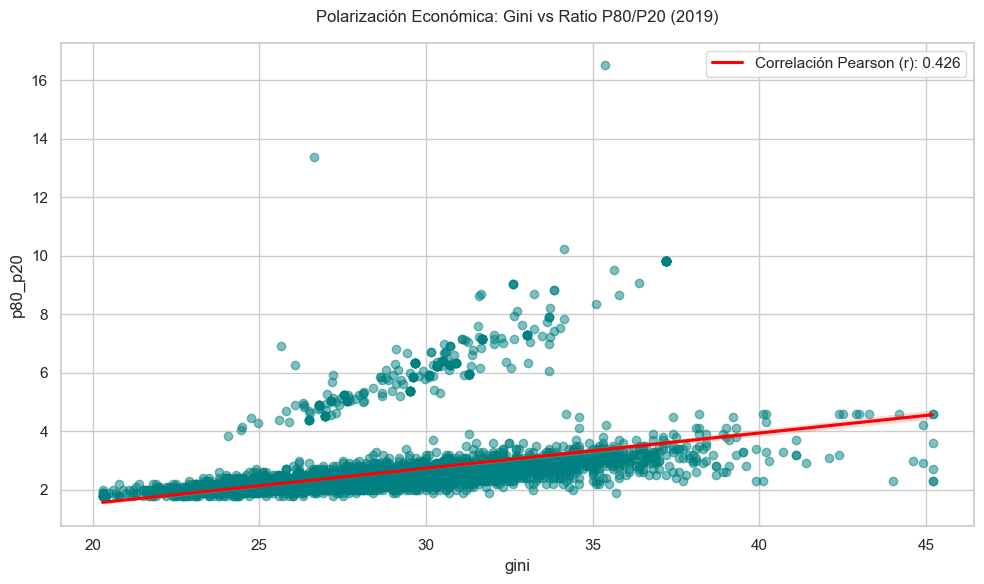

In [16]:
df_desigualdad_2019 = eda_gini_p80p20(df_gini_completo=df_renta_completa.reset_index(), anyo="2019")

Podemos observar que la gráfica de relación entre el índice de Gini y el P80/P20 presenta una dispersión considerable en los datos. Esto se debe a que, en el caso de Navarra, disponemos del indicador S80/S20 en lugar del P80/P20; al existir esta discrepancia, no lo consideramos un resultado válido para la comparativa. Por este motivo, nos centraremos únicamente en los histogramas de Gini.

A continuación, repetiremos el análisis excluyendo el dato de Navarra para observar la relación real. Sabemos que la correlación entre el índice de Gini y el P80/P20 es elevada, por lo que descartaremos esta última métrica al no disponer de la serie completa de datos. No obstante, esta decisión se confirmará más adelante mediante un mapa de correlaciones.

 INICIANDO ANÁLISIS DE DESIGUALDAD Y RENTA (2019)
Info: 1693 de 8139 municipios NO tienen datos de renta en 2019.

TOP 10 MUNICIPIOS MÁS DESIGUALES (2019)
 1. Benasau                   | Gini: 45.2 | Los ricos ganan 2.3x más que los pobres
 2. Mediana de Voltoya        | Gini: 45.2 | Los ricos ganan 3.6x más que los pobres
 3. Carataunas                | Gini: 45.2 | Los ricos ganan 4.6x más que los pobres
 4. Alocén                    | Gini: 45.2 | Los ricos ganan 2.7x más que los pobres
 5. Guadramiro                | Gini: 45.2 | Los ricos ganan 2.3x más que los pobres
 6. Villarluengo              | Gini: 45.2 | Los ricos ganan 4.6x más que los pobres
 7. Campillo de Ranas         | Gini: 44.9 | Los ricos ganan 4.2x más que los pobres
 8. Villardondiego            | Gini: 44.9 | Los ricos ganan 2.9x más que los pobres
 9. Pobla de Benifassà, la    | Gini: 44.6 | Los ricos ganan 3.0x más que los pobres
10. Sant Mori                 | Gini: 44.0 | Los ricos ganan 2.3x más que los po

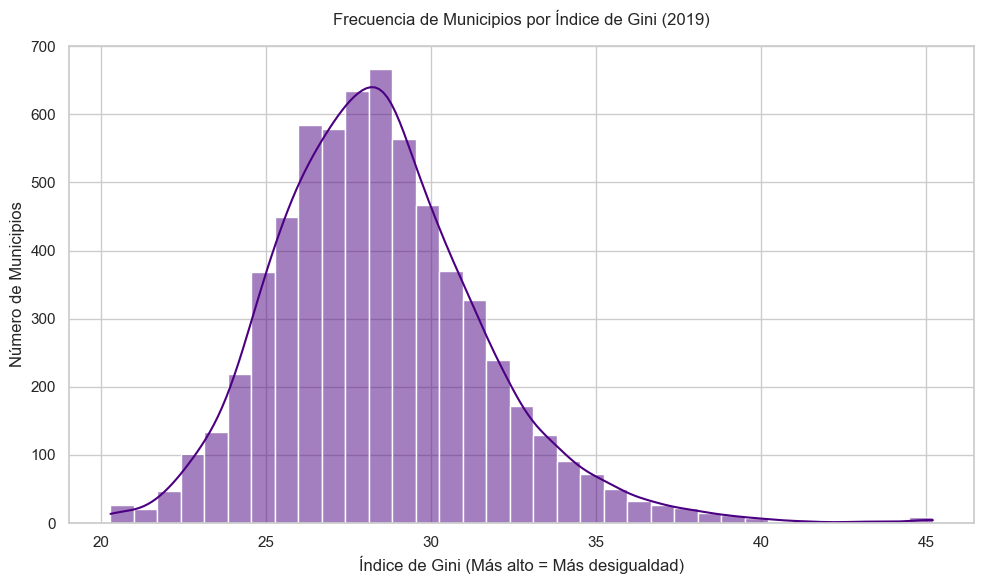

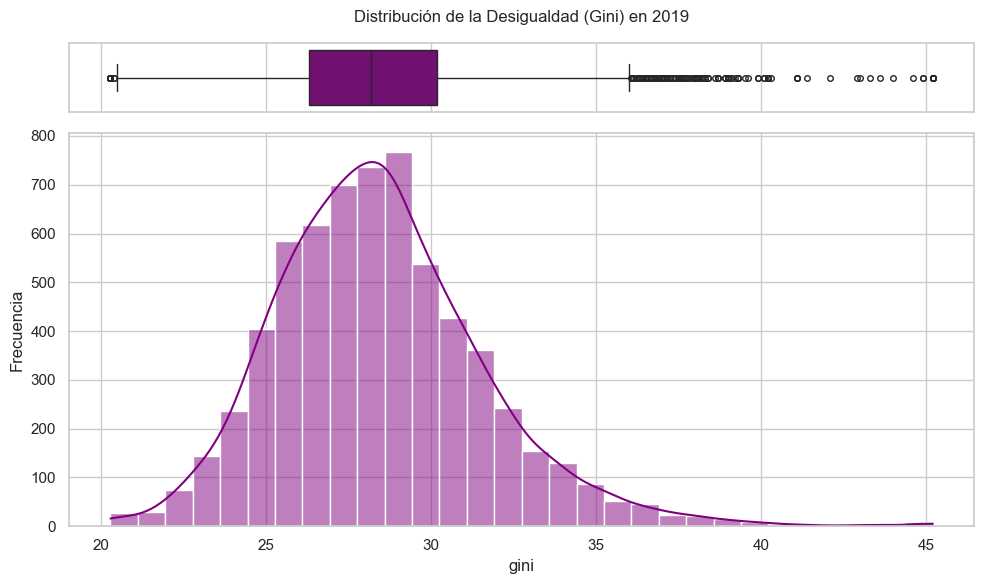

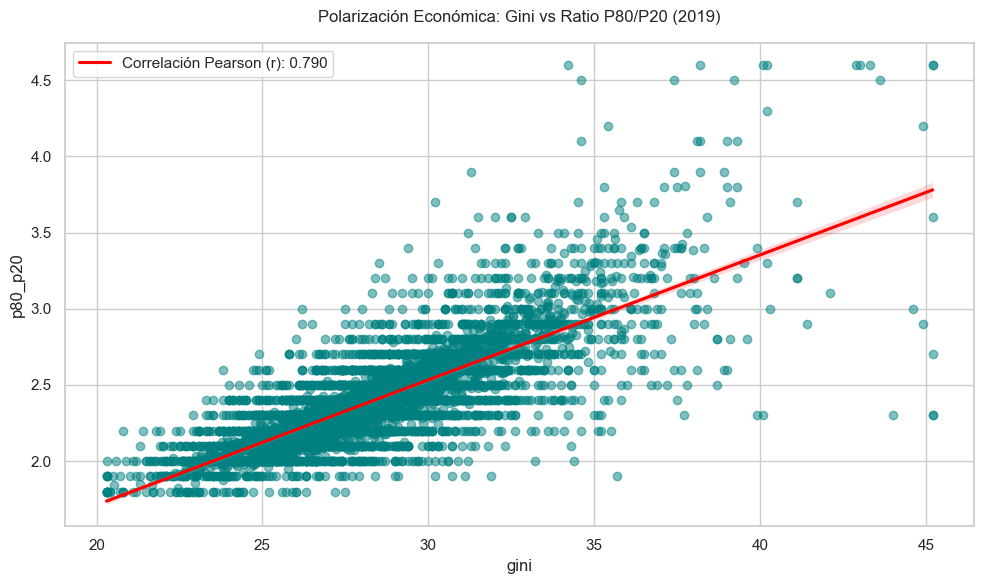

In [17]:
df_desigualdad_2019 = eda_gini_p80p20(df_gini_completo=df_2019_GINI_P80P20, anyo="2019")

Tras el procesamiento y visualización de los indicadores de renta relativos a 2019, se observa una radiografía de la desigualdad municipal que resulta determinante para entender el clima previo a los comicios. Para interpretar estos datos, es necesario precisar que el Índice de Gini es una medida de desigualdad que oscila entre 0 (igualdad total) y 100 (desigualdad máxima, donde una sola persona concentra toda la renta). En el contexto español, un Gini inferior a 25 se considera una cota de igualdad muy alta, el rango entre 28 y 32 representa el estándar medio nacional, y valores superiores a 35 o 40 indican una fractura social severa. Complementariamente, el Ratio P80/P20 cuantifica la polarización de los extremos, indicando cuántas veces superan los ingresos del 20% más rico de la población a los del 20% más pobre.

El análisis de distribución mediante el histograma confirma que la mayoría de los municipios españoles presentan una morfología de campana con una fuerte concentración en el intervalo de 26 a 31 puntos de Gini, lo que define la normalidad estadística de la desigualdad moderada en el país. Sin embargo, los resultados arrojan una sombra estadística significativa: 1.693 municipios (el 20,8% del total nacional) no presentan datos de renta. Este vacío no es aleatorio, sino que coincide con municipios de pequeño tamaño —la "España vaciada"— protegidos por el secreto estadístico del INE para preservar la privacidad en entornos de baja población. Esta ausencia de datos en el bloque de renta refuerza la tesis del desequilibrio territorial analizado en capítulos anteriores, donde la falta de visibilidad económica suele correlacionar con una marginalidad política que el sistema electoral intenta compensar.

En la gráfica se observa la relación entre ambas métricas, se ha obtenido un coeficiente de correlación de Pearson de $r = 0,790$. Este valor indica una correlación positiva fuerte, confirmando que la desigualdad en España se manifiesta de forma predominante como una polarización de los extremos. Matemáticamente, este resultado valida que en los municipios donde el Índice de Gini se eleva, la brecha social se ensancha de forma drástica y predecible: el enriquecimiento del bloque superior de renta ocurre de forma simultánea al estancamiento del bloque inferior. En localidades donde el Gini supera los 40 puntos, esta "fractura" social genera un entorno económico que suele traducirse en un ratio $P80/P20$ elevado (llegando a 4,6x en casos como Villarluengo).

Desde la perspectiva de este TFM, esta consistencia estadística ($r = 0,790$) sugiere que será importante observar si los los municipios situados en la parte alta de esta correlación, tienen comportamientos de voto dispares aquellos que ocupan la parte baja de la gráfica.ç

## distrivución de fuente de ingresos


==================== INICIANDO ANÁLISIS DE FUENTES DE INGRESOS (2019) ====================

AUDITORÍA DE DATOS FALTANTES FUENTES INGRESOS (2019)


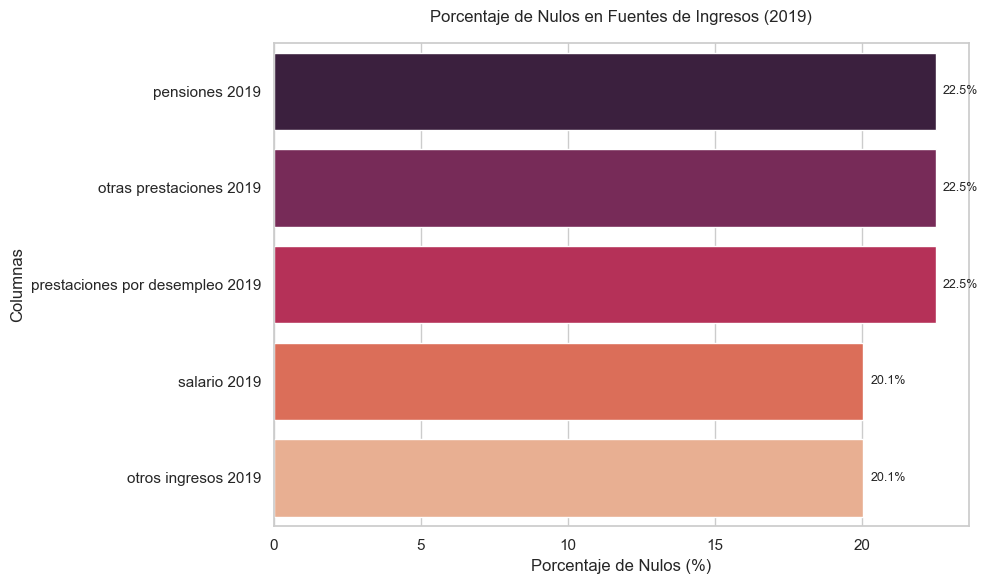

Nota: No se puede mostrar el perfil por tamaño de municipio para Fuentes Ingresos porque la columna no existe en los datos proporcionados.

IMPACTO POR PROVINCIA Fuentes Ingresos (2019)
Top 10 provincias con más nulos Fuentes Ingresos:
 - Navarra             :  211 municipios (13.0%)
 - Guadalajara         :  182 municipios (11.2%)
 - Burgos              :  171 municipios (10.5%)
 - Soria               :  118 municipios (7.3%)
 - Ávila               :  100 municipios (6.2%)
 - Teruel              :   96 municipios (5.9%)
 - Zaragoza            :   88 municipios (5.4%)
 - Salamanca           :   87 municipios (5.4%)
 - Segovia             :   79 municipios (4.9%)
 - Cuenca              :   78 municipios (4.8%)

RESUMEN NACIONAL: Peso Medio de las Fuentes de Ingresos (2019)
 - salario             : 52.6%
 - pensiones           : 26.9%
 - otros_ingresos      : 13.5%
 - otras_prestaciones  : 4.7%
 - desempleo           : 2.6%


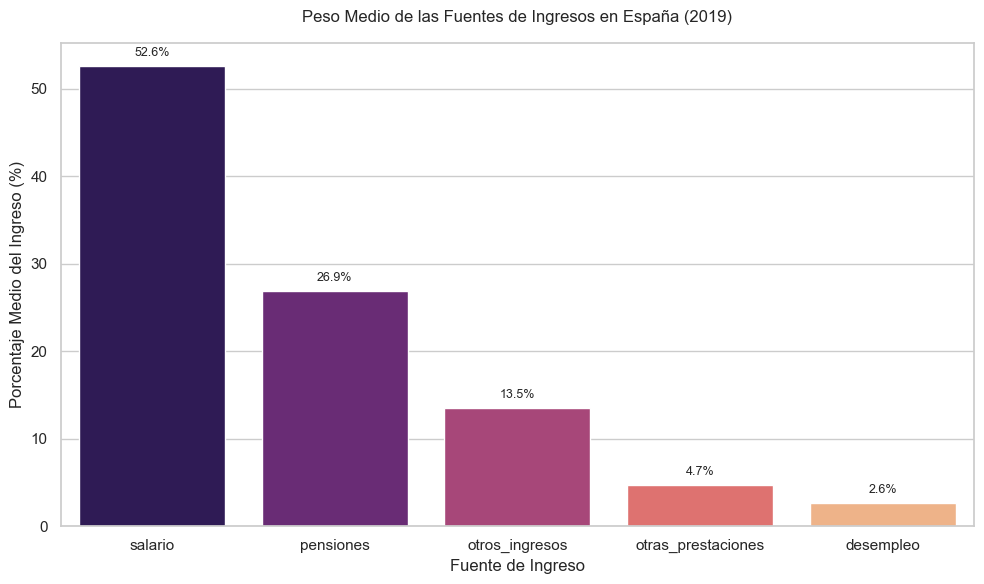

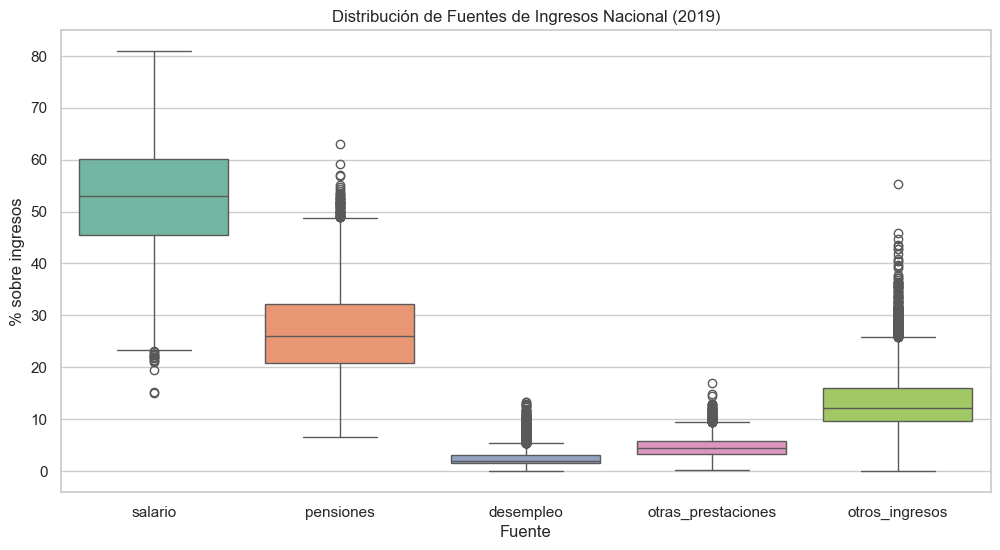


ANÁLISIS ESTRUCTURAL: Fuentes de Ingresos por Tamaño de Municipio (2019)


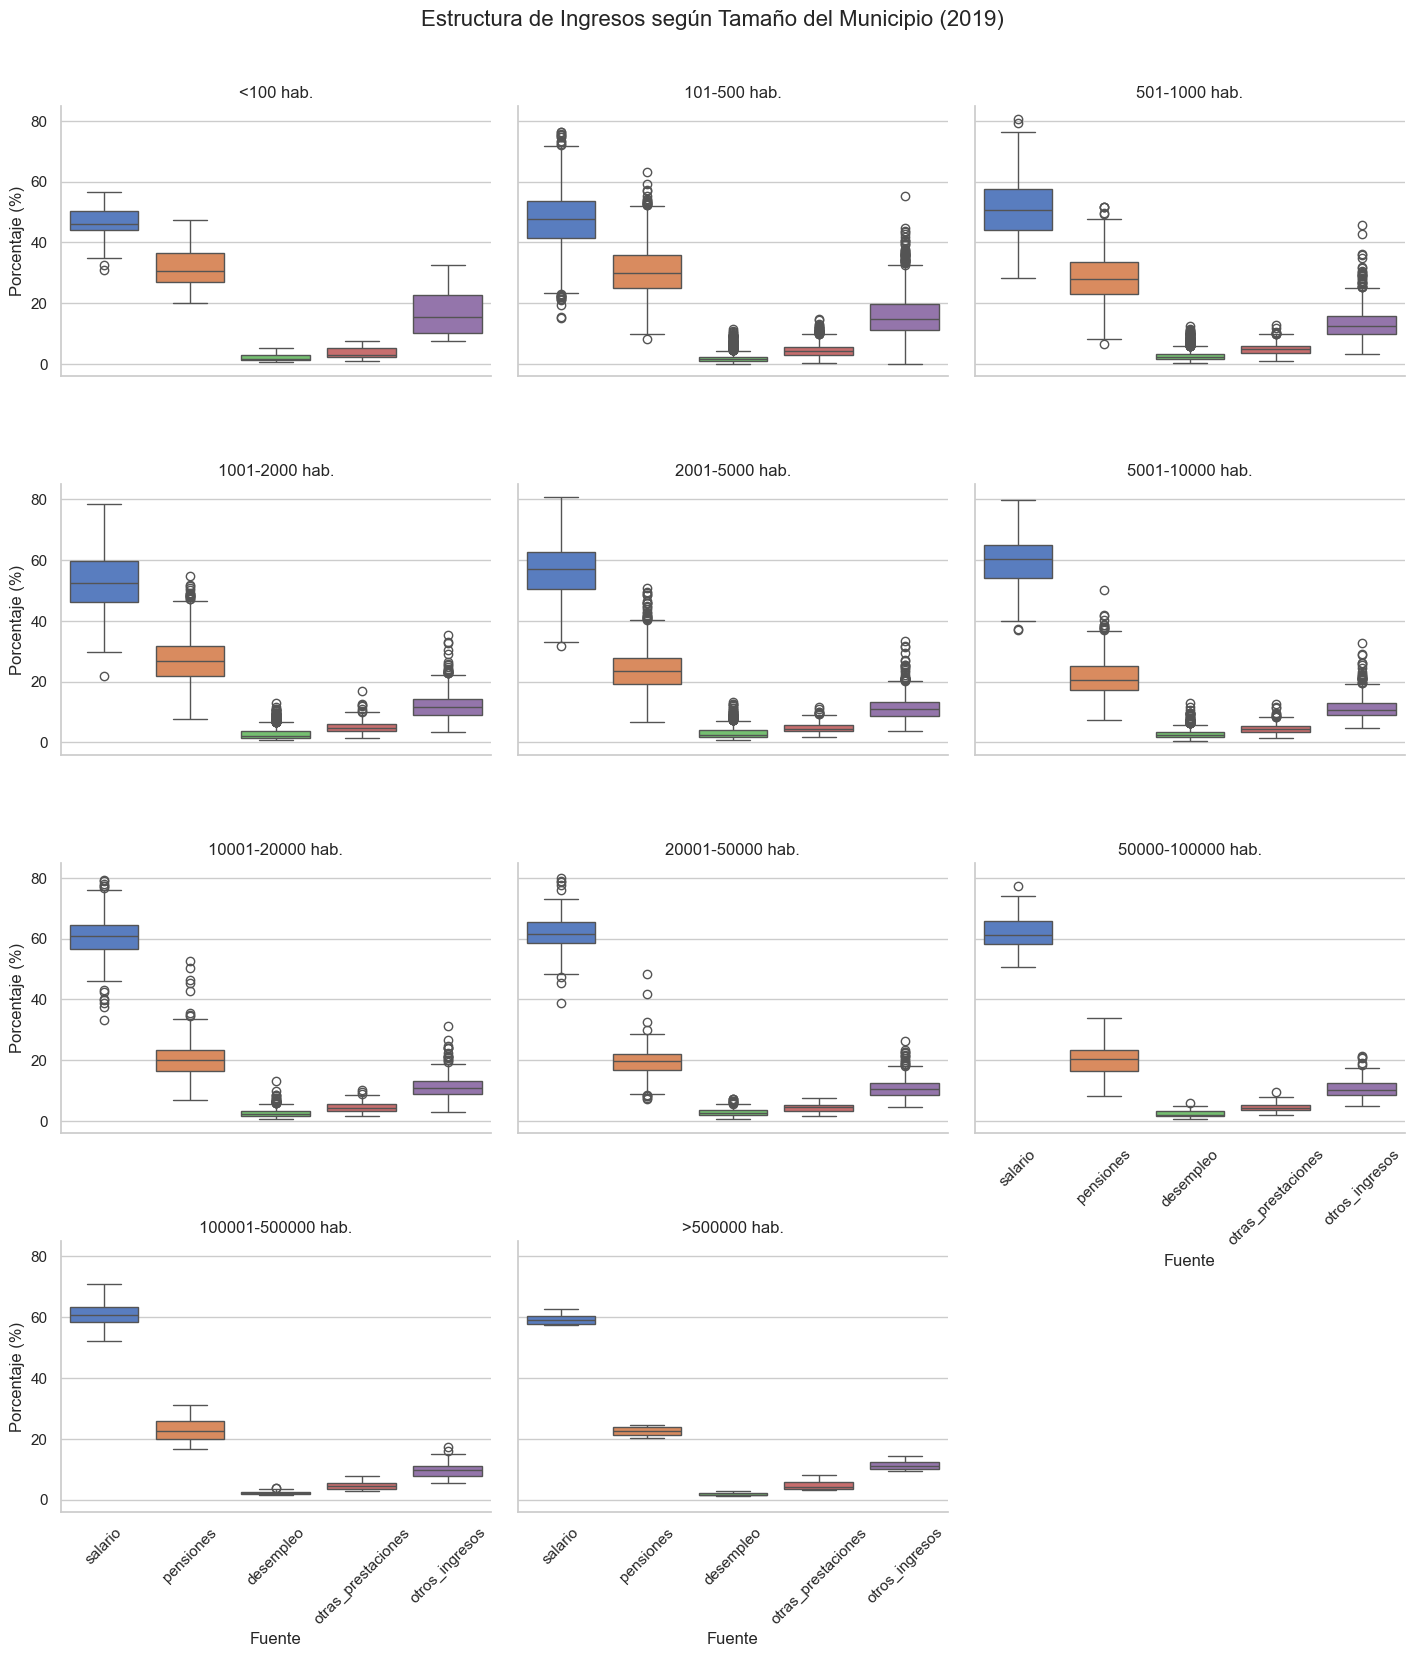

In [18]:
df_fuentes_2019 = eda_fuente_ingresos(df_2019_fuente_ingresos, df_2019_poblacion_csv, anyo="2019")

La distribución del Porcentaje Medio de Ingresos actúa como un indicador del promedio nacional y revela una jerarquía clara: España es, eminentemente, una economía basada en el trabajo. Los salarios constituyen el 52,6% de los ingresos medios, seguidos por las pensiones con un 26,9%. Otras fuentes, como las prestaciones por desempleo o las ayudas sociales, aparecen como componentes residuales que no alcanzan el 5% del peso total.
Sin embargo, el boxplot revela que esta uniformidad es solo aparente. Aunque la mediana del salario es mayoritaria, presenta una volatilidad intermunicipal extrema. Es especialmente significativo el comportamiento de las pensiones y otras rentas: a pesar de tener medianas bajas, el gráfico muestra una alta densidad de outliers en el decil superior. Esto confirma la existencia de municipios con naturalezas económicas opuestas; verdaderas "islas" demográficas donde la dependencia de la prestación pública o de las rentas patrimoniales anula la relevancia del mercado laboral privado.

Al analizar la estructura de ingresos por rango poblacional, se observa una tendencia clara: el crecimiento del municipio correlaciona con una estructura económica más predecible y centrada en el salario.
* Municipios de baja densidad (<100 a 1.000 hab.): Es donde reside la mayor volatilidad económica. La cuota salarial es sensiblemente inferior y la dependencia de las pensiones es mucho más elevada. En los núcleos de menos de 100 habitantes, la brecha entre salario y pensiones se estrecha críticamente, reflejando el envejecimiento demográfico de la "España vaciada".
* Áreas Metropolitanas (>100.000 a >500.000 hab.): El escenario se invierte. El salario se dispara por encima del 60% y la dispersión se reduce drásticamente. Son entornos de ingresos homogéneos, estrechamente vinculados a la actividad profesional y al sector servicios avanzado.

**Posibles Implicaciones para la Modelización Electoral**

Esta segmentación por tamaños sugiere dos frentes de batalla electoral muy distintos:
1.	El "Voto Senior" y la Seguridad Social: En municipios pequeños, donde las pensiones representan el eje vital (con medianas que rozan el 40%), el electorado muestra una sensibilidad extrema a los mensajes sobre la sostenibilidad del sistema público de previsión. La supervivencia económica depende directamente del Estado, lo que suele traducirse en un voto que prima la seguridad y la aversión al riesgo institucional.
2.	El "Voto Activo" Urbano: En las metrópolis, el motor es el salario. Este electorado es más receptivo a políticas de presión fiscal (IRPF), coste de la vida y dinamismo empresarial. En estas zonas, los programas centrados exclusivamente en las pensiones pueden percibirse como secundarios frente a la gestión de la economía productiva.
3.	Transversalidad de las Rentas de Capital: Resulta notable que la categoría de "otros ingresos" (rentas y capital) mantenga valores atípicos constantes independientemente del tamaño del municipio. Esto sugiere un perfil de votante con alto patrimonio distribuido de forma ubicua, cuya motivación de voto podría estar ligada a la fiscalidad patrimonial, con independencia de su entorno geográfico.
En conclusión, los datos sugieren que una estrategia electoral unidimensional ignora la realidad económica del territorio: los incentivos que movilizan a una urbe de 500.000 habitantes (salario) son diametralmente opuestos a los que rigen en un municipio de 500 residentes (pensiones).


## Indicadores de renta

Ahora probamos con los datos extraídos del INE, donde faltan los datos de Navarra, y posteriormente los compararemos con los resultados de dicha comunidad.


INICIANDO ANÁLISIS DE INDICADORES DE RENTA (2019)

AUDITORÍA DE DATOS FALTANTES INDICADORES RENTA (2019)
Total de municipios en el dataset: 8139
Municipios sin datos de renta: 1582 (19.4%)


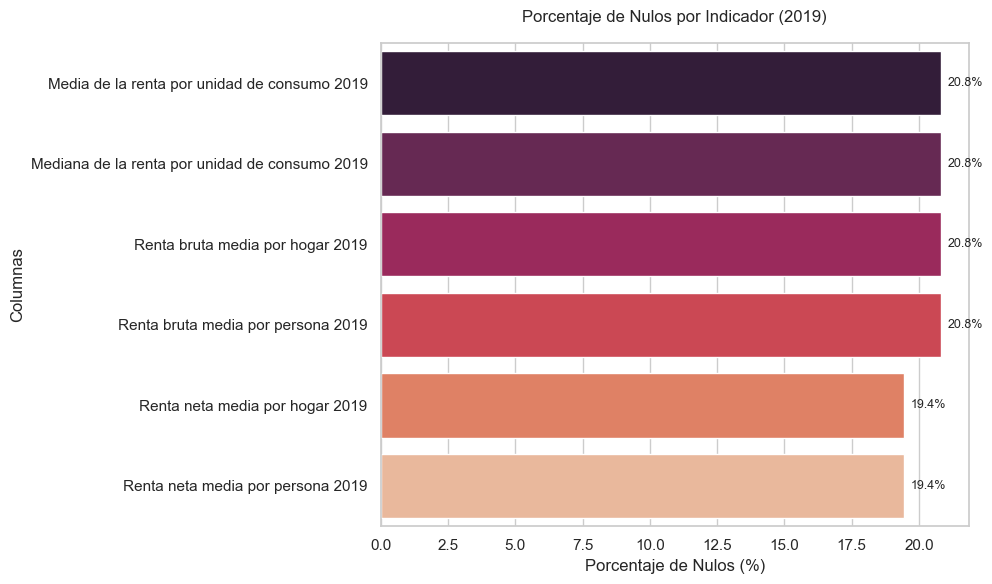

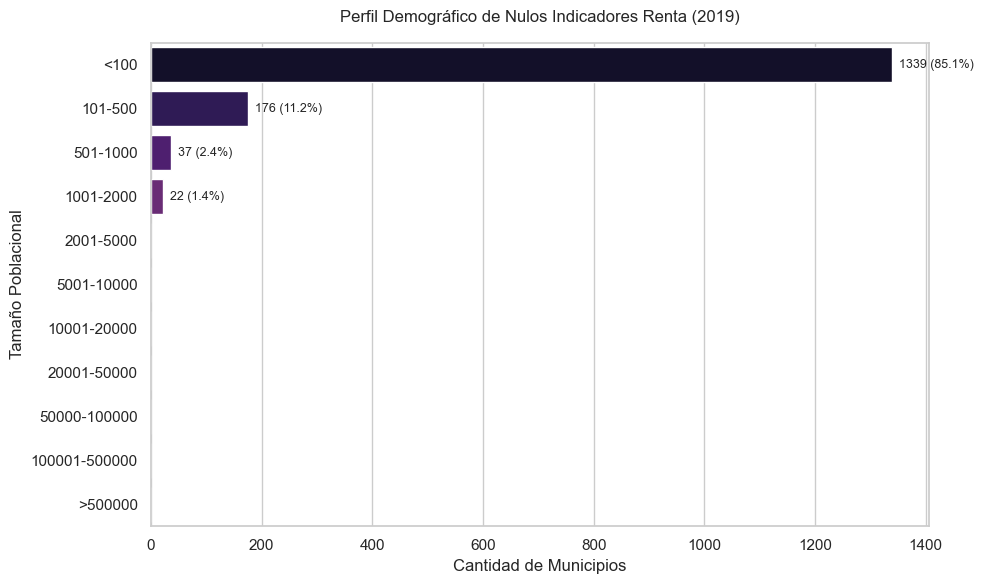


IMPACTO POR PROVINCIA Indicadores Renta (2019)
Top 10 provincias con más nulos Indicadores Renta:
 - Navarra             :  211 municipios (13.4%)
 - Guadalajara         :  182 municipios (11.6%)
 - Burgos              :  171 municipios (10.9%)
 - Soria               :  118 municipios (7.5%)
 - Ávila               :  100 municipios (6.4%)
 - Teruel              :   96 municipios (6.1%)
 - Zaragoza            :   88 municipios (5.6%)
 - Salamanca           :   87 municipios (5.5%)
 - Segovia             :   79 municipios (5.0%)
 - Cuenca              :   78 municipios (5.0%)


In [19]:
df_indicadores_renta_2019 = eda_indicadores_renta( df_renta_completo = df_2019_renta_disponible, df_pob = df_poblacion_superficie_2019, anyo = "2019")

El análisis de calidad revela que el 19,4% de los municipios (1.582 localidades) carece de datos de renta para el año 2019. Esta ausencia de información no responde a errores de registro, sino a la aplicación estricta del secreto estadístico por parte del INE, que busca proteger la privacidad de los ciudadanos en zonas donde la baja densidad de población permitiría identificar rentas individuales.

Demográficamente, este "apagón" informativo es absoluto en los estratos de municipios con menos de 1.000 habitantes, coincidiendo plenamente con el perfil de la España rural vaciada. Geográficamente, el impacto se concentra con especial dureza en Navarra (13,4% de los nulos), Guadalajara (11,6%) y Burgos (10,9%), seguidas por otras provincias con alta dispersión como Soria y Ávila.

Estos resultados demuestran que los indicadores de renta poseen un sesgo urbano intrínseco. Esto implica que, para casi el 20% del territorio nacional, precisamente el más envejecido, la renta no es un predictor electoral viable por falta de datos, lo que obliga a recurrir a variables alternativas para analizar su comportamiento en las urnas.


INICIANDO ANÁLISIS DE INDICADORES DE RENTA (2019)

AUDITORÍA DE DATOS FALTANTES INDICADORES RENTA (2019)
Total de municipios en el dataset: 8139
Municipios sin datos de renta: 1371 (16.8%)


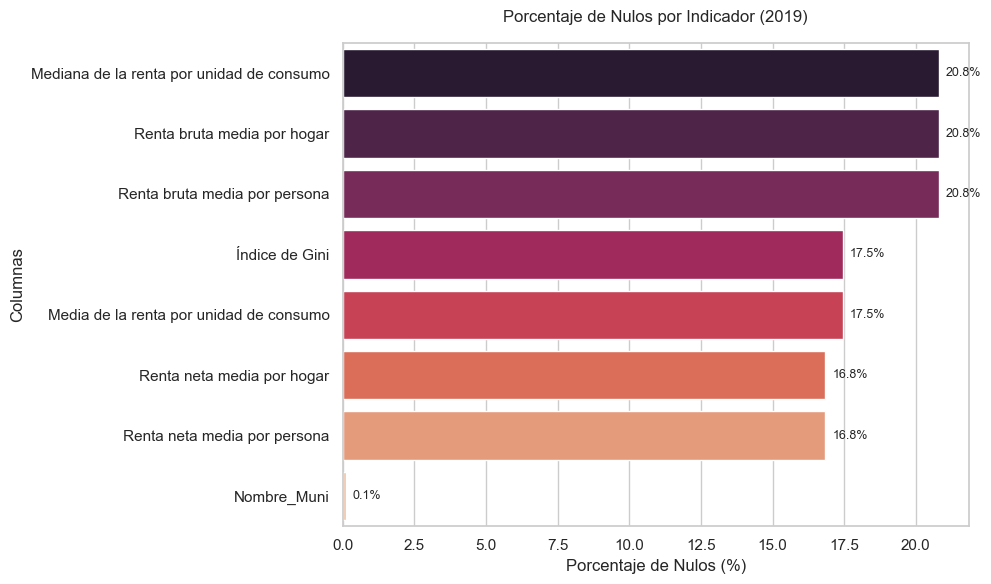

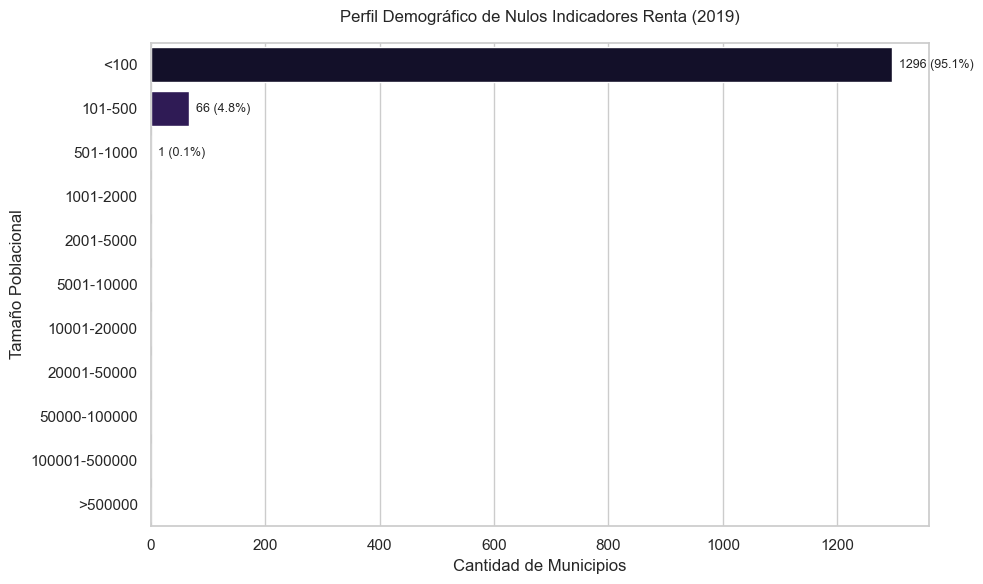


IMPACTO POR PROVINCIA Indicadores Renta (2019)
Top 10 provincias con más nulos Indicadores Renta:
 - Guadalajara         :  182 municipios (13.4%)
 - Burgos              :  171 municipios (12.5%)
 - Soria               :  118 municipios (8.7%)
 - Ávila               :  100 municipios (7.3%)
 - Teruel              :   96 municipios (7.0%)
 - Zaragoza            :   88 municipios (6.5%)
 - Salamanca           :   87 municipios (6.4%)
 - Segovia             :   79 municipios (5.8%)
 - Cuenca              :   78 municipios (5.7%)
 - Palencia            :   76 municipios (5.6%)


In [20]:
df_indicadores_renta_2019 = eda_indicadores_renta( df_renta_completo = df_renta_completa.reset_index(), df_pob = df_poblacion_superficie_2019, anyo = "2019")

Podemos observar que, al añadir los datos de Navarra, el porcentaje de valores nulos disminuye un 3%. Además, estos se concentran prácticamente en dos franjas, a diferencia de las cuatro que encontrábamos sin los datos navarros. Si bien es cierto que no son exactamente dos (ya que existe un municipio de entre 501 y 1000 habitantes sin información), procederemos a identificar de qué municipio se trata.

In [21]:
col_renta = [c for c in df_indicadores_renta_2019.columns if 'Renta neta media por persona' in c][0]
codigos_nulos = df_indicadores_renta_2019[df_indicadores_renta_2019[col_renta].isna()]['Cod_Muni']

df_pob_temp = df_poblacion_superficie_2019.copy()
df_pob_map_id = 'id_municipio' if 'id_municipio' in df_pob_temp.columns else df_pob_temp.columns[0]
df_pob_temp[df_pob_map_id] = df_pob_temp[df_pob_map_id].astype(str).str.zfill(5)

nulos_rango = pd.merge(
    df_pob_temp,
    df_indicadores_renta_2019[df_indicadores_renta_2019['Cod_Muni'].isin(codigos_nulos)],
    left_on=df_pob_map_id,
    right_on='Cod_Muni'
)

filtro_final = nulos_rango[(nulos_rango['poblacion_total'] > 500) & (nulos_rango['poblacion_total'] <= 1000)]
print(f"\nMUNICIPIOS DE 501-1000 HABITANTES SIN DATOS DE RENTA ({len(filtro_final)} casos):")
cols_mostrar = ['Nombre_Muni', 'poblacion_total']
print(filtro_final[cols_mostrar].sort_values('poblacion_total', ascending=False))


MUNICIPIOS DE 501-1000 HABITANTES SIN DATOS DE RENTA (1 casos):
     Nombre_Muni  poblacion_total
8  Arraia-Maeztu              726


Vemos que el municipio sin datos de la categoría de 501-1000 habitantes pertenece a la provincia de Álava, en el País Vasco.


GENERANDO VISUALIZACIONES DE DISTRIBUCIÓN PARA 2019


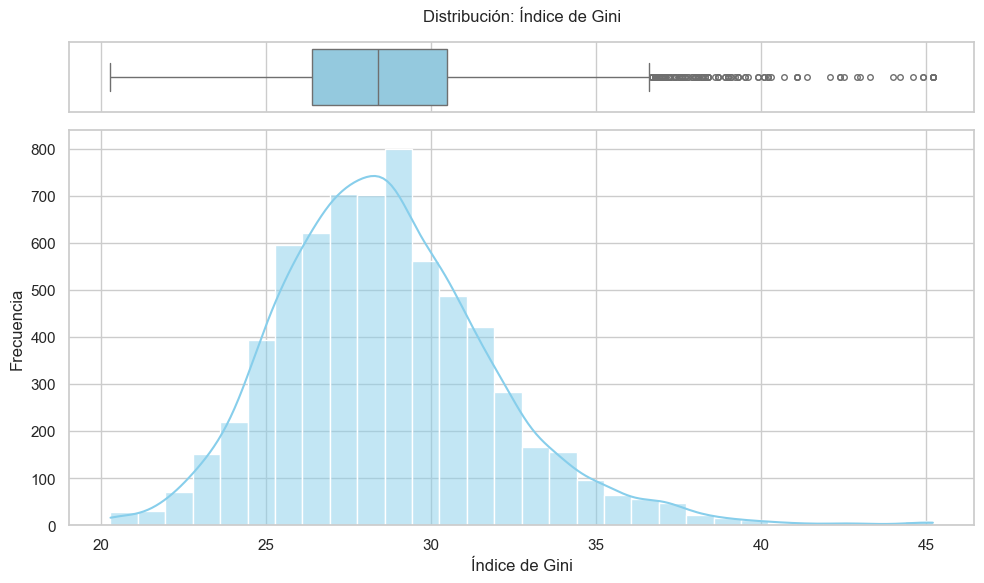

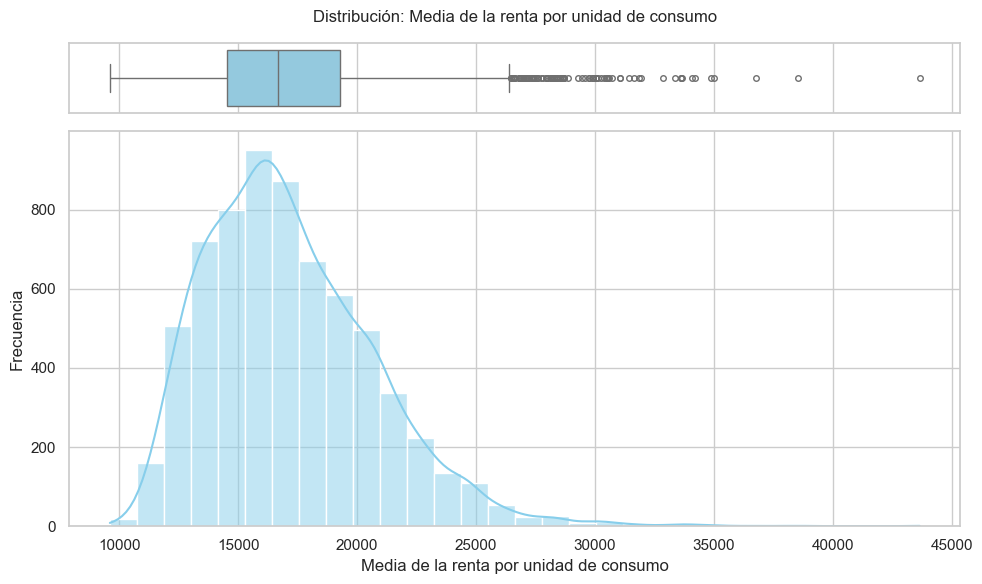

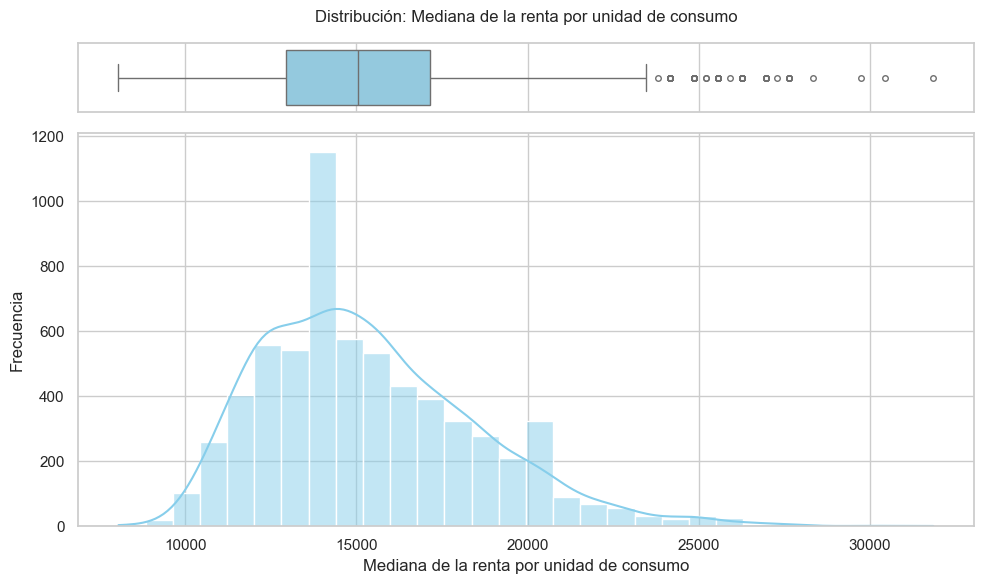

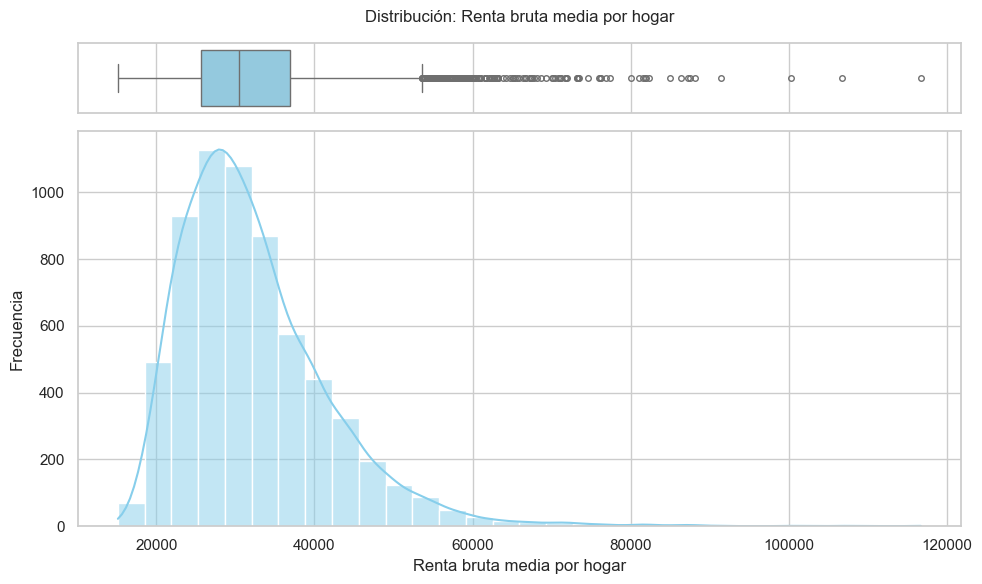

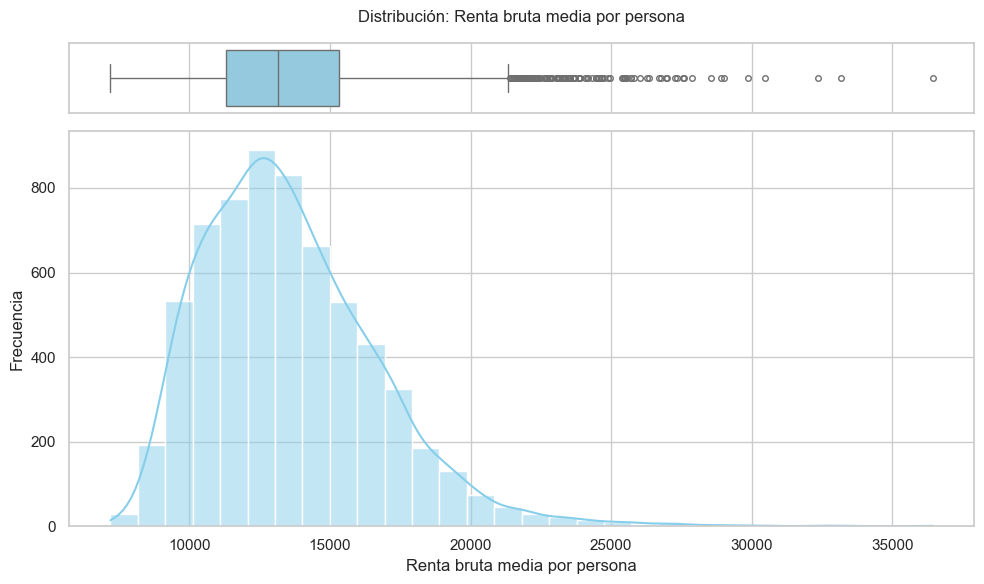

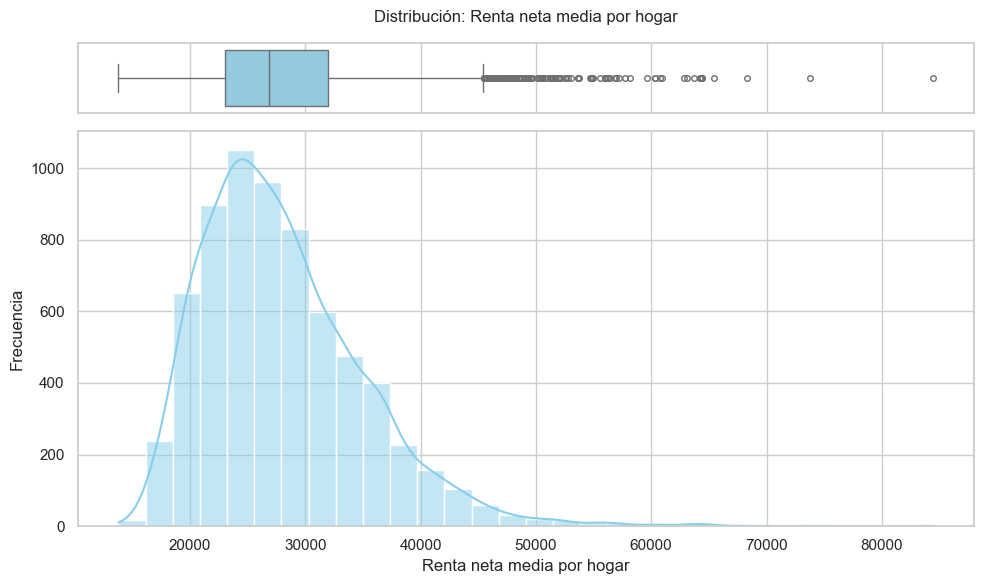

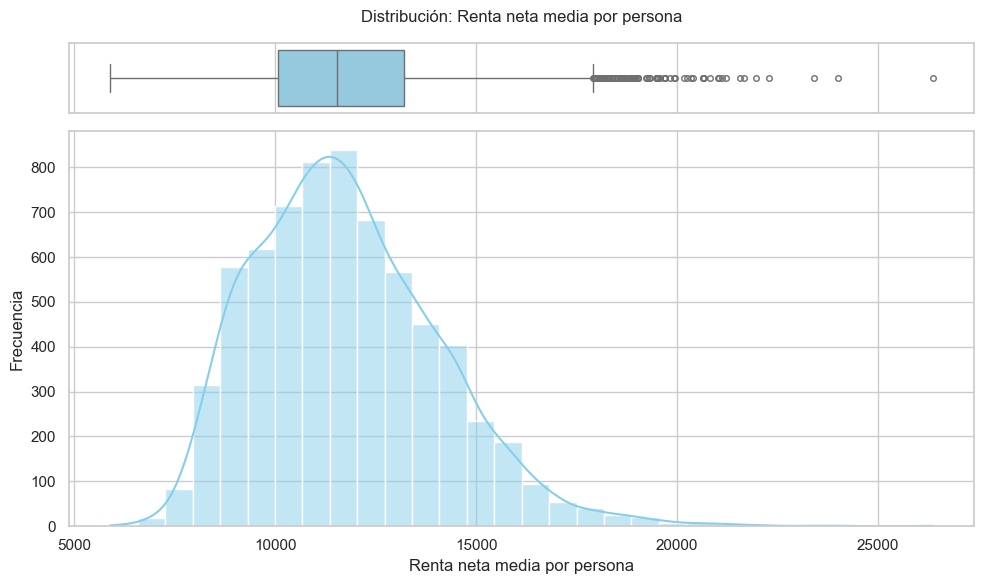

In [22]:
visualizar_histogramas_renta(df_indicadores_renta_2019, anyo="2019")

El análisis de la morfología de la renta en España revela una desigualdad estructural caracterizada por un marcado sesgo positivo. La distribución muestra una "larga cola" hacia la derecha, donde una minoría concentra ingresos excepcionalmente altos que distorsionan el promedio aritmético. Este fenómeno provoca que el ciudadano típico —representado por la moda— perciba ingresos significativamente inferiores a la media nacional, la cual se ve inflada por valores atípicos que llegan a cuadruplicar la mediana. Esta segregación geográfica de la riqueza sugiere la existencia de municipios que operan bajo una lógica económica totalmente aislada del comportamiento general del país.

Al comparar la renta bruta frente a la neta, se evidencia el impacto del sistema redistributivo. La transición hacia valores netos produce un desplazamiento de la curva hacia la izquierda y una compresión de la varianza, reduciendo la dispersión de los ingresos más altos. Mientras que la renta bruta por hogar se sitúa cerca de los 30.000€, la distribución neta se estrecha en torno a los 25.000€, acortando la distancia entre ellos. No obstante, el uso de la Unidad de Consumo (con un pico en los 16.000€) resulta ser la métrica más fiel para corregir las economías de escala de los hogares, mostrando una mayor homogeneidad en los niveles de vida reales en gran parte del territorio.

## Fase 2: Análisis del Target (Votos y Abstención)
Aquí es donde entiendes la "respuesta" que el modelo debe aprender.

2.1. Participación y Abstención
Acción: * %_Abstención = (Abstenciones / Censo_Electoral) * 100.
Análisis: * Busca si hay patrones geográficos. ¿Se vota menos en los municipios más pobres? ¿O en los más rurales?
* Identifica municipios con abstención extrema (>40%).

2.2. Concentración y Bloques
Acción: Agrupa los votos por Bloques Ideológicos (usando tu fichero de ideología).

* Bloque_Izquierda: PSOE + Sumar/Podemos + Regionalistas Izquierda.
* Bloque_Derecha: PP + VOX + Regionalistas Derecha.

Análisis:
* Dominancia: ¿En cuántos municipios el bloque de derecha supera el 60%? ¿Y el de izquierda?
* Fragmentación: ¿Cuántos partidos sacan más de un 5% en el mismo municipio? Esto te dirá dónde es más difícil predecir el escaño.

2.3. El fenómeno Regionalista
Acción: Analiza el peso de los partidos regionales que has sumado a los estatales.
* Análisis: ¿Hay provincias donde la suma de partidos regionales cambia el ganador del bloque? (Muy común en Cataluña o País Vasco).

In [23]:
#df_votos_provincial = eda_votos_granularidad_total(df_2019_Votos_Granularidad_Total_2019)

In [24]:
#df_votos_provincial = eda_votos_granularidad_total(df_2019_Votos_Agrupados_Padres_2019) 

# tengo que sacar conclusiones DE ARRIBA 

In [25]:
analizar_umbral_votos_nacional(df_2019_Votos_Agrupados_Padres_2019)

ANÁLISIS DE RELEVANCIA PROVINCIAL (Umbral: 3.0%)
Provincia 01:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 02:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 03:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 04:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 05:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 06:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 07:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 08:  8 partidos superan umbral | 54 no lo alcanzan.
Provincia 09:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 10:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 11:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 12:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 13:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 14:  5 partidos superan umbral | 57 no lo alcanzan.
Provincia 15:  6 partidos superan umbral | 56 no lo alcanzan.
Provincia 16:  5 part

### 2.2. Estructura de slots de partido (target ML)

Partiendo del análisis anterior (25 candidaturas superan el umbral del 3% provincial), definimos los **slots de partido** que serán los targets del modelo de ML. 
La decisión sigue slots estables para estatales (resolviendo la consistencia 2019→2023 cuando Podemos se convierte en Sumar) más columna individual para cada regionalista con escaño propio (necesario para aplicar D'Hondt correctamente).

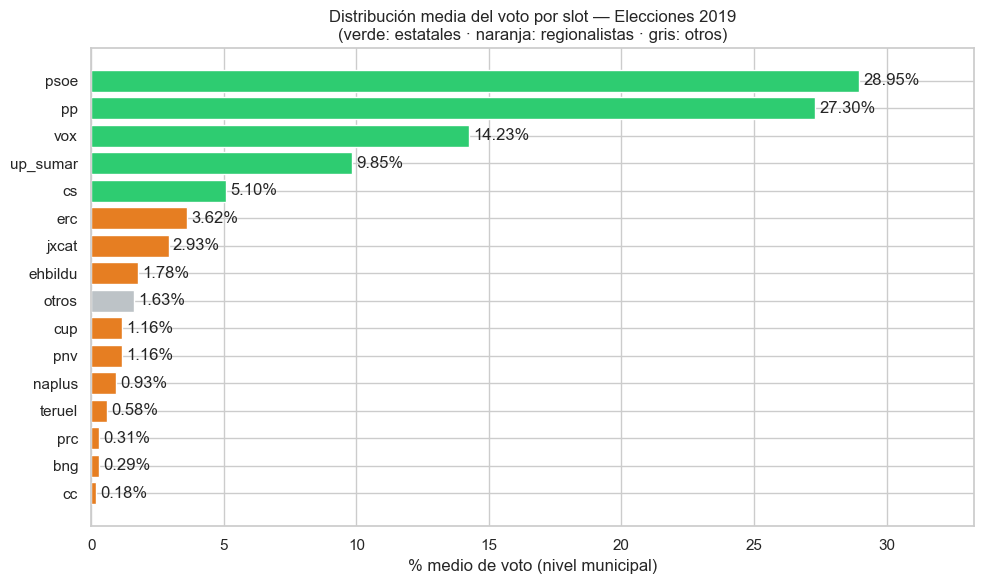

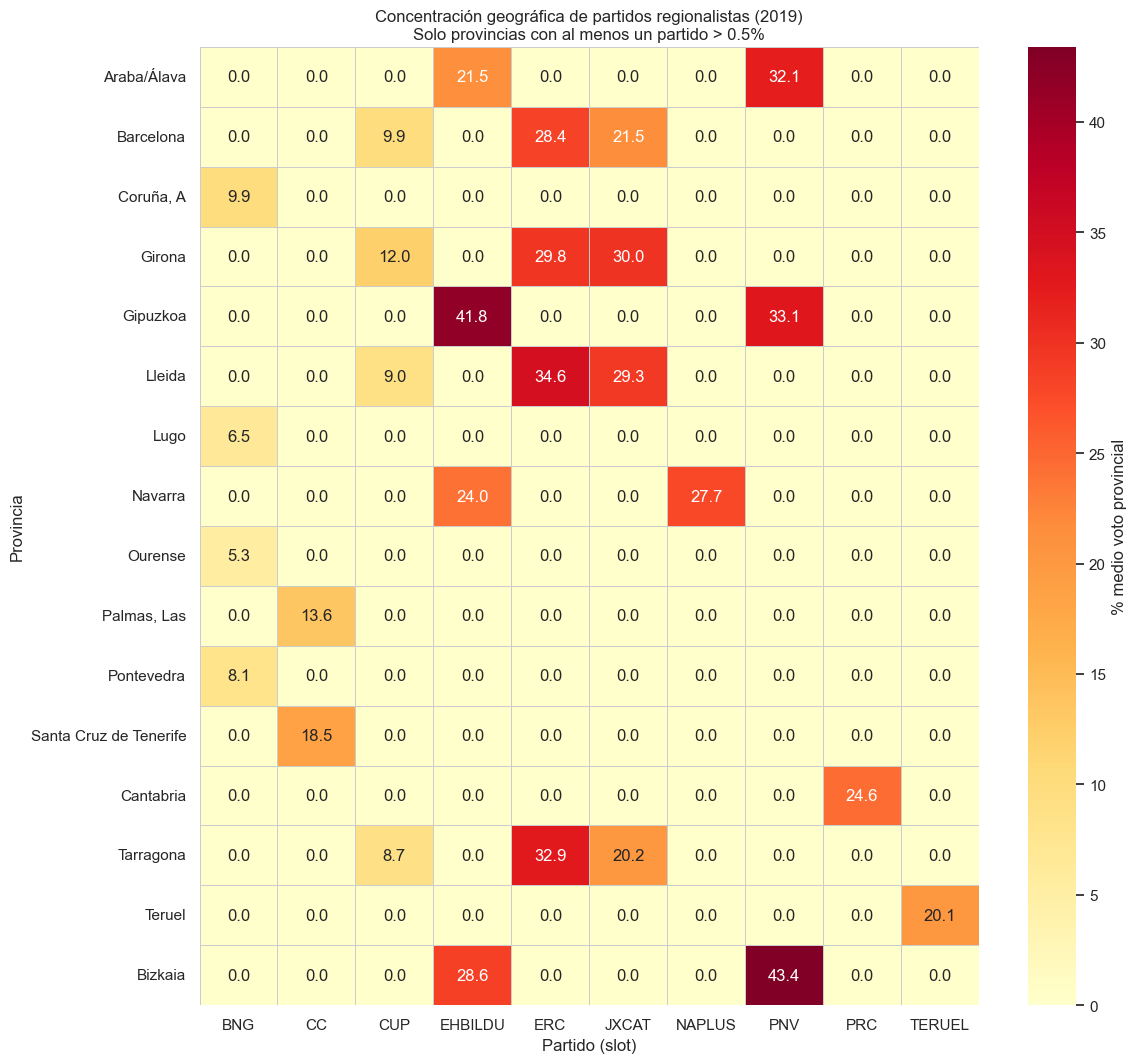

RESUMEN DE COBERTURA DE SLOTS — 2019
Slot                  Media      Max   Municipios>0
psoe                 28.95%   82.35%        8,083
pp                   27.30%  100.00%        7,790
vox                  14.23%   66.67%        7,874
up_sumar              9.85%   71.93%        7,745
cs                    5.10%   46.46%        7,339
erc                   3.62%   60.87%          947
jxcat                 2.93%   65.43%          947
ehbildu               1.78%   97.33%          519
otros                 1.63%   45.45%        6,416
cup                   1.16%   36.76%          942
pnv                   1.16%   63.39%          251
naplus                0.93%   81.82%          271
teruel                0.58%   60.00%          231
prc                   0.31%   43.51%          102
bng                   0.29%   31.57%          313
cc                    0.18%   38.85%           88

pct_otros cubre el 1.63% del voto de media.
Municipios con pct_otros > 5%: 455 de 8131


In [26]:
eda_slots_pct_votos(df_2019_votos_pct, anyo="2019")

Podemos ver que, de las 62 candidaturas principales, es decir, aquellas que agrupan varias a nivel nacional o son unicas, solo 25 obtienen más del 3% de los votos en las provincias donde se presentan. Esto permite que su candidatura no sea descartada por el umbral marcado por la ley y tras agruparlos en slots que nos permitiran aplicar el modelo a diferentes años.

Tras analizar los datos por separado, utilizamos la función unificar_datos_eda("año"). Esta permite generar un archivo CSV y un DataFrame con información general, lo que facilitará el cruce de variables con los datasets de votos. De este modo, podremos analizar cómo ciertos factores influyen en los resultados, realizar correlaciones y completar las etapas finales del EDA.

In [27]:
#df_2019_datos_unificados = unificar_datos_eda(2019)

In [28]:
df_2019_datos_unificados.isna().sum()

municipio                        0
nombre                           0
provincia                        0
superficie                       0
latitud                          0
longitud                         0
altitud                          0
rango tamaño población           0
poblacion                        0
poblacion hombres                0
poblacion mujeres                0
densidad poblacional             0
indice gini                   1413
P80P20                        1685
Renta media hogar             1363
renta media unidad consumo    1413
renta media persona           1363
salarios                      1624
pensiones                     1824
otros ingresos                1624
otras prestaciones            1824
desempleo                     1824
edad media                    7981
votos totales                    0
votos blancos                    0
participacion                    0
pct_psoe                         0
pct_pp                           0
pct_vox             

Ahora que tenemos el fichero unificado podemos mirar dos puntos claves de las votaciones, por lo tanto miraremos el porcentaje de participación general y según el rango de territorio.


--- Análisis de Participación y Votos en Blanco (2019) ---


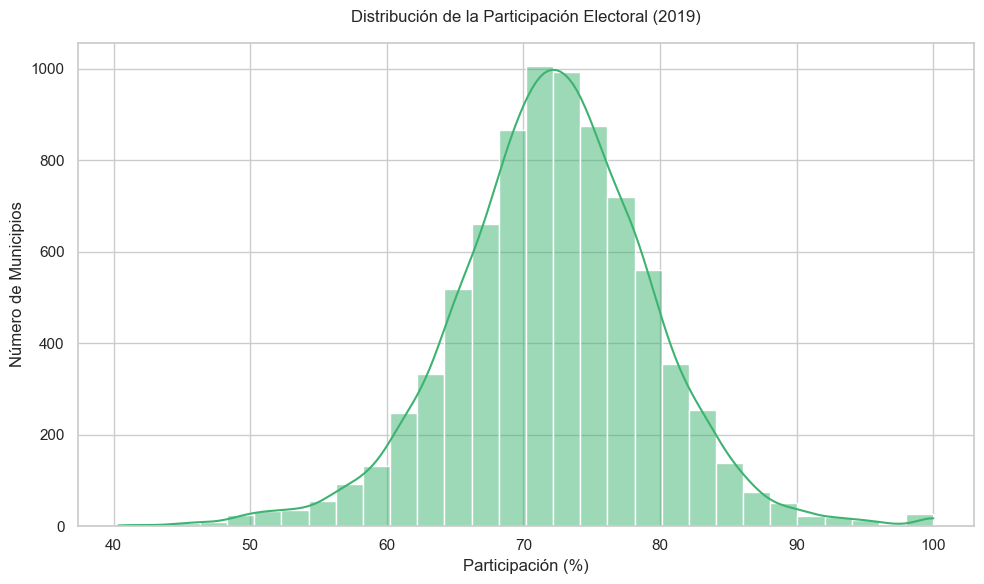

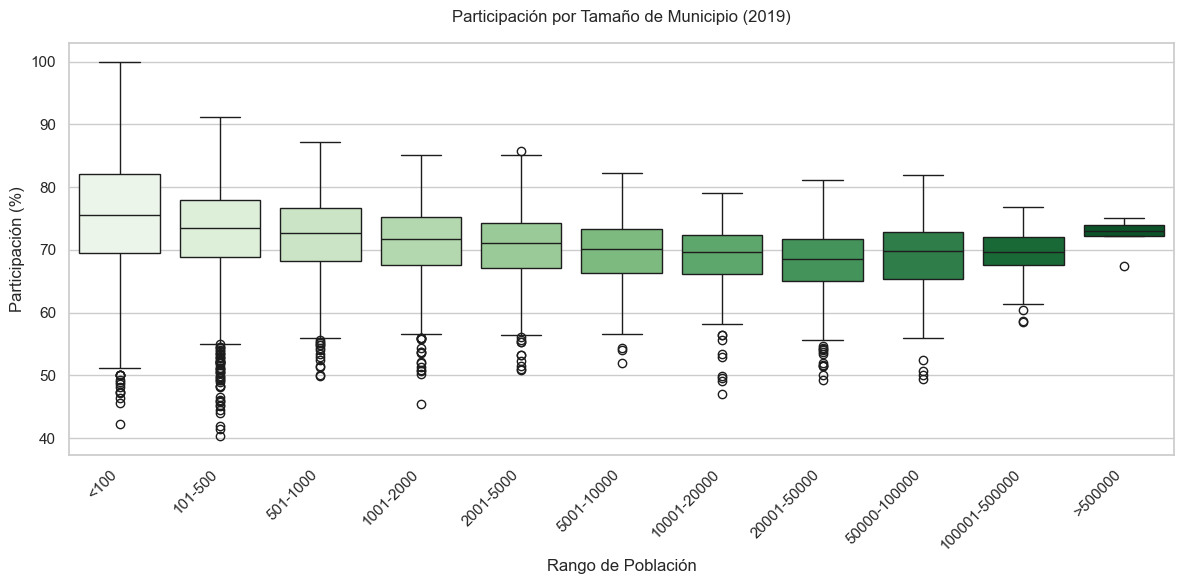

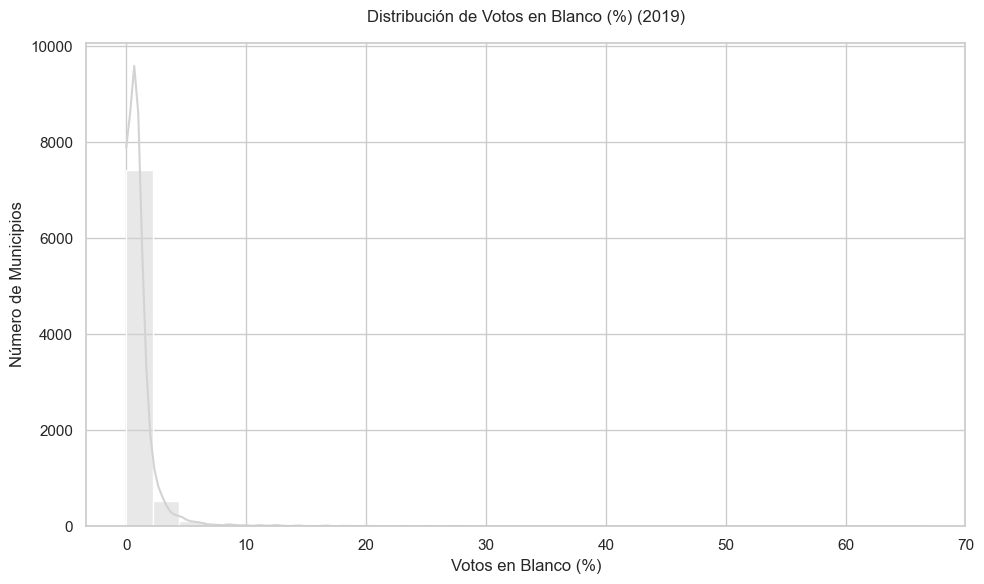

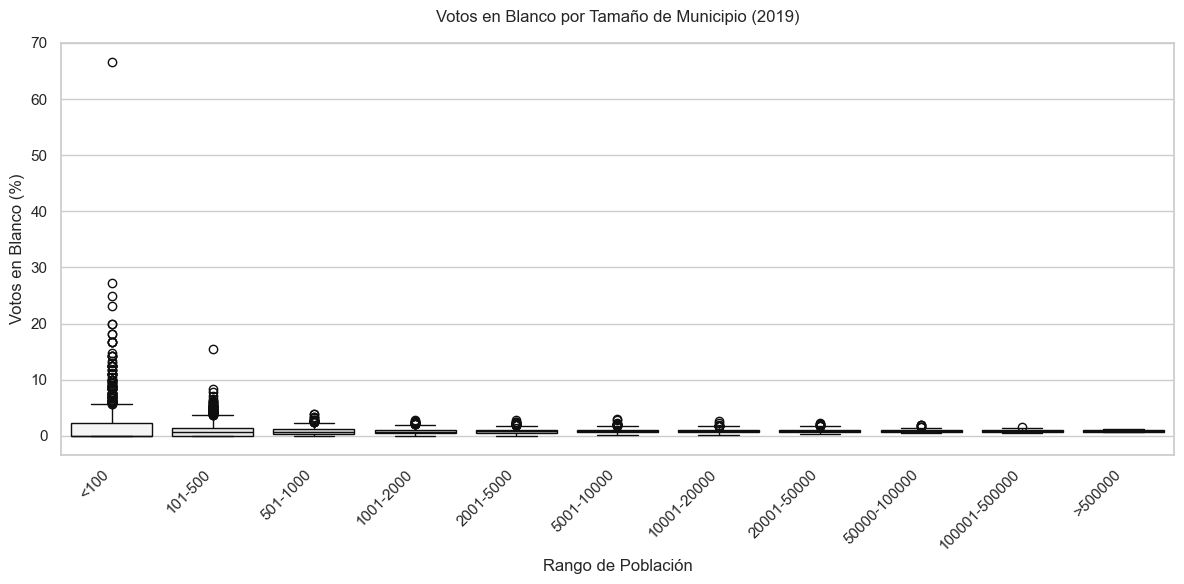

In [29]:
participacion_electoral(df_2019_datos_unificados, "2019")


--- Análisis de Votos en Blanco: Municipios < 100 hab. (2019) ---
Total de municipios analizados: 1352


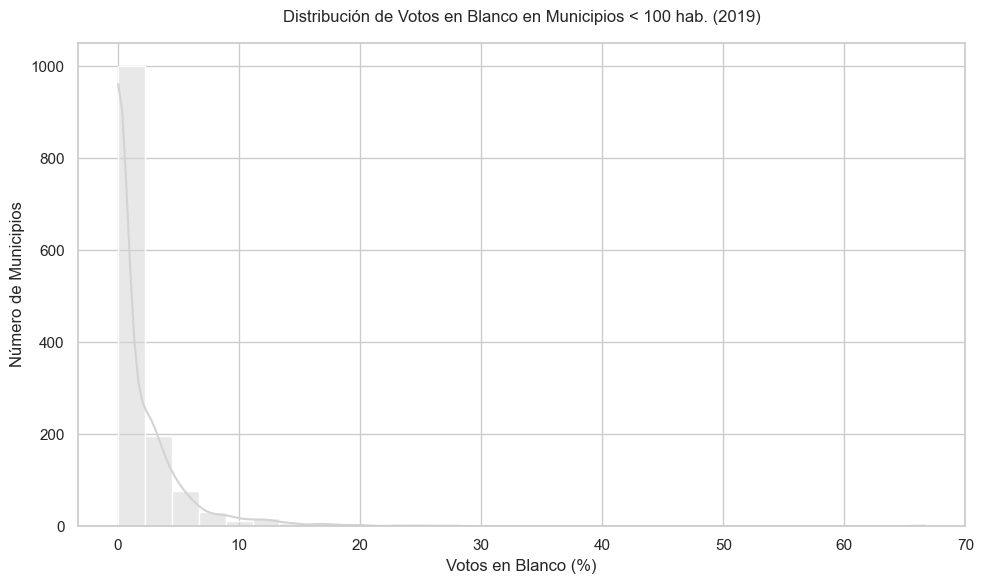

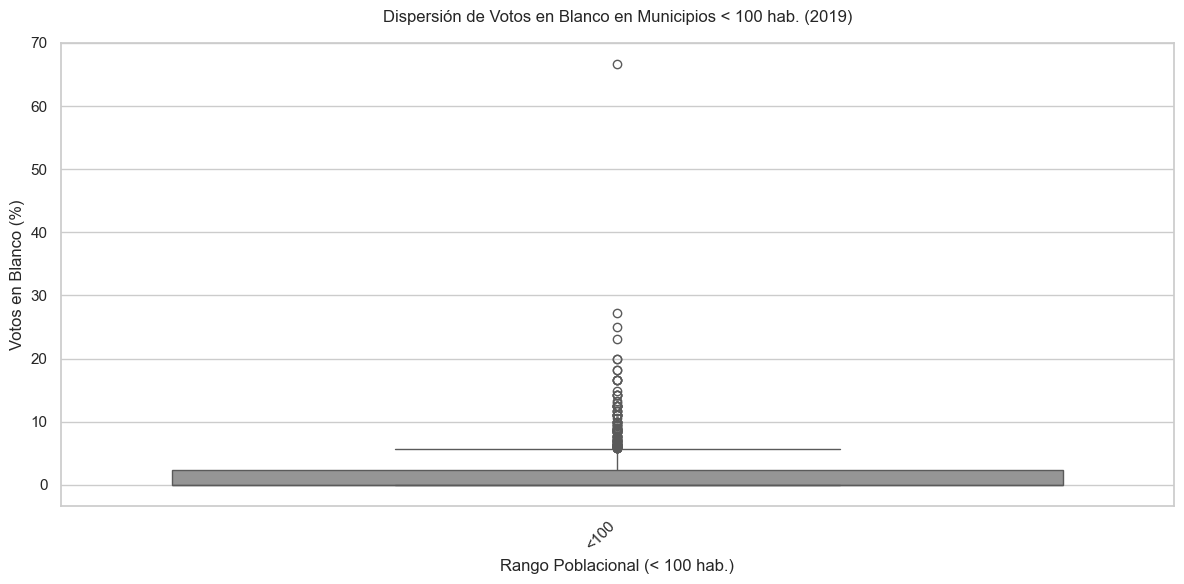

In [30]:
participacion_electoral_100(df_2019_datos_unificados, "2019")

El histograma de participación electoral se observa una distribución que sigue una curva aproximadamente normal, centrada en torno al 70-75%. La gran mayoría de los municipios presentan niveles de movilización ciudadana elevados, con una caída drástica en la frecuencia de municipios que registran una participación inferior al 50% o superior al 90%. Esta concentración sugiere un comportamiento electoral bastante homogéneo en el grueso del territorio nacional, además onservamos municipios con el 100% de participación.

Por su parte, los boxplots muestran una relación inversa entre el tamaño del municipio y la variabilidad de la participación. Los municipios más pequeños (menos de 500 habitantes) presentan los rangos más amplios y los valores máximos de participación más altos, llegando en casos al 100%. A medida que aumenta la población, la participación tiende a estabilizarse y la mediana se sitúa en valores ligeramente inferiores, aunque en las ciudades de más de 500000 habitantes se observa un repunte en la mediana de participación con una dispersión mínima, indicando un comportamiento más predecible en las grandes metrópolis.

El histograma de votos en blanco, muestra un sesgo positivo extremo, donde la inmensa mayoría de los municipios registran menos de un 2-3% de votos en blanco, lo que indica que esta opción de voto es minoritaria y poco frecuente como fenómeno masivo en la mayoría de las localidades españolas.

Los boxplots profundiza en esta tendencia, revelando que la mayor cantidad de outliers se encuentra en los municipios de menor tamaño. En localidades con menos de 100 habitantes, se registran casos excepcionales donde el voto en blanco llega a superar el 60%, un fenómeno que desaparece por completo en municipios de más de 1,000 habitantes. En las poblaciones medianas y grandes, el porcentaje de votos en blanco es notablemente bajo y extremadamente estable, lo que sugiere que el voto de protesta o indecisión bajo esta modalidad es una particularidad estadística de núcleos rurales muy reducidos. Lo que tiene una implicación directa bajo la Ley d'Hondt: al ser el voto en blanco un voto válido, eleva el umbral del 3% necesario para que una candidatura sea considerada en el reparto de escaños. En estos escenarios de alta concentración de voto en blanco, el número de votos requeridos para superar la barrera electoral aumenta, dificultando la entrada de partidos pequeños y favoreciendo indirectamente a las formaciones mayoritarias.

Para evitar el sesgo de selección y la pérdida de representatividad de la 'España Vaciada', se procederá a la imputación de variables socioeconómicas en municipios con secreto estadístico. Se utilizará la estructura de grafo para asignar a los municipios nulos la media ponderada de sus vecinos geográficos, basándose en el principio de autocorrelación espacial.

Pasamos a crear el grafo de vecinos.

In [31]:
gdf, w = generar_grafo_adyacencia()

Cargando grafo de adyacencia existente desde caché...
Grafo cargado con 8131 municipios.


In [32]:
#visualizar_grafo_maestro(gdf, w)

Una vez obtenido el grafo de colindancia municipal, generaremos un dataframe final. En él, imputaremos los valores faltantes de los municipios pequeños utilizando la media de sus municipios limítrofes. Esta decisión se fundamenta en que, al pertenecer a una misma región geográfica, es altamente probable que compartan características similares.


ANÁLISIS DE COHESIÓN VECINAL FILTRADO (2019)
Municipios con datos económicos encontrados en el grafo: 6768
Municipios finales analizados (excluyendo islas resultantes): 6753


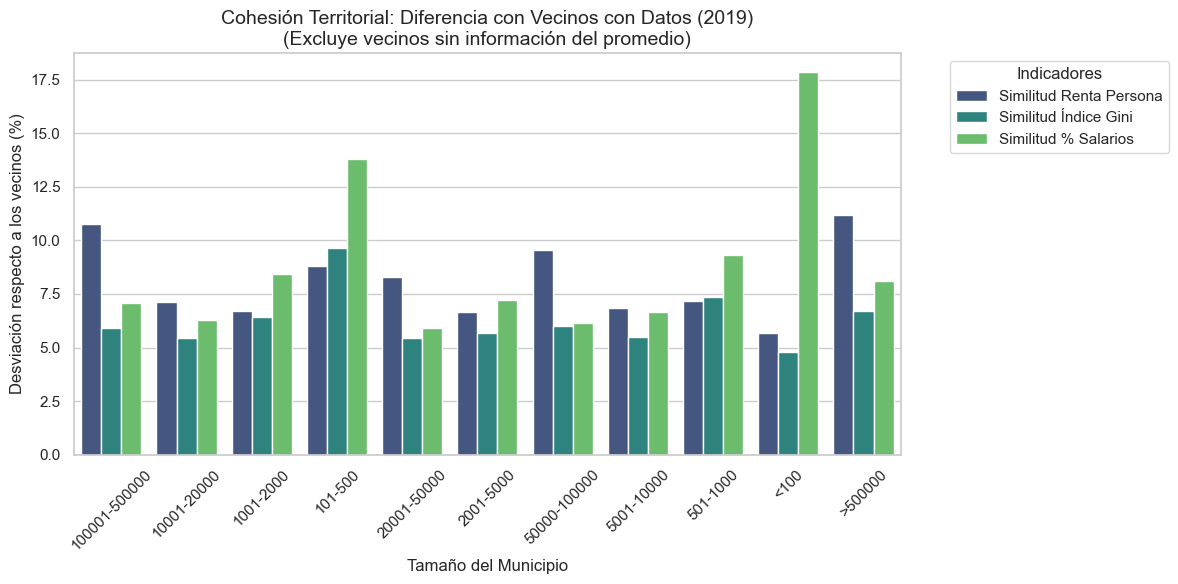

In [33]:
resumen_vecindad = analizar_similitud_vecinal_economica(df_2019_datos_unificados, w, anyo="2019")

A partir de la gráfica de desviación porcentual media respecto a la vecindad, se observa que en los municipios con menos de 100 habitantes existe una cohesión espacial alta en el Índice de Gini, pero una volatilidad crítica (cercana al 18%) en la estructura de ingresos por salarios. Ante esta evidencia de 'islas económicas' en el ámbito rural, se decide implementar una técnica de imputación híbrida basada en grafos: para las variables de baja desviación (Gini y Renta), se utilizará la media de los nodos colindantes siempre que estos pertenezcan a un estrato poblacional similar (evitando así la contaminación por parte de núcleos urbanos cercanos). por el contrario, para las variables de alta dispersión como los salarios, se optará por la mediana provincial del estrato rural. Esta estrategia permite recuperar la representatividad de la 'España Vaciada' en el modelo, garantizando que los datos imputados respeten la realidad regional observada sin introducir el ruido estadístico que generaría una media vecinal simple.

In [34]:
df_2019_completo = imputar_datos_socioeconomicos(df = df_2019_datos_unificados, w = w, anyo = 2019)

INICIANDO PROCESO DE IMPUTACIÓN SOCIOECONÓMICA (2019)
 -> Imputando Grupo B (Fuentes volátiles) mediante mediana provincial rural
 -> Imputando Grupo A (Indicadores estables) mediante adyacencia física...
 -> Imputando edad media mediante ponderación por género...

   Municipios con edad media imputada: 7981
   Fórmula aplicada:
     edad_media = (edad_media_hombres_prov × pob_hombres
                  + edad_media_mujeres_prov × pob_mujeres)
                  / (pob_hombres + pob_mujeres)
   Fuente provincial: edad_media_provincias_2019.csv

Resultados de Imputación por Provincia:
 - Albacete: 86 municipios imputados.
 - Alicante/Alacant: 133 municipios imputados.
 - Almería: 100 municipios imputados.
 - Araba/Álava: 51 municipios imputados.
 - Asturias: 74 municipios imputados.
 - Badajoz: 163 municipios imputados.
 - Balears, Illes: 65 municipios imputados.
 - Barcelona: 292 municipios imputados.
 - Bizkaia: 109 municipios imputados.
 - Burgos: 370 municipios imputados.
 - Cantabria

In [35]:
df_2019_completo.isna().sum()

municipio                       0
nombre                          0
provincia                       0
superficie                      0
latitud                         0
longitud                        0
altitud                         0
rango tamaño población          0
poblacion                       0
poblacion hombres               0
poblacion mujeres               0
densidad poblacional            0
indice gini                     7
P80P20                        202
Renta media hogar               0
renta media unidad consumo      7
renta media persona             0
salarios                       51
pensiones                     251
otros ingresos                 51
otras prestaciones            251
desempleo                     251
edad media                      0
votos totales                   0
votos blancos                   0
participacion                   0
pct_psoe                        0
pct_pp                          0
pct_vox                         0
pct_cs        

Observamos que hemos reducido considerablemente el número de nulos. En el análisis de P80P20, ya vimos que los 202 valores NA corresponden a Navarra, ya que dicha comunidad/provincia no proporciona este dato, por lo tanto, resulta imposible imputarlos mediante vecinos o mediana provincial. Por otro lado, analizaremos los siete municipios a los que no se les ha podido imputar un valor en GINI y/o renta media por unidad de consumo.

In [36]:
municipios_nulos = df_2019_completo[df_2019_completo['indice gini'].isna() | df_2019_completo['renta media unidad consumo'].isna()]
print(f"Municipios con datos faltantes ({len(municipios_nulos)} detectados):")
print(municipios_nulos[['municipio', 'nombre', 'provincia', 'rango tamaño población']])

Municipios con datos faltantes (7 detectados):
    municipio                        nombre    provincia  \
331     01051           Agurain/Salvatierra  Araba/Álava   
332     01001              Alegría-Dulantzi  Araba/Álava   
333     01002                       Amurrio  Araba/Álava   
334     01049                         Añana  Araba/Álava   
337     01037                 Arraia-Maeztu  Araba/Álava   
349     01023                Elvillar/Bilar  Araba/Álava   
366     01039  Moreda de Álava/Moreda Araba  Araba/Álava   

    rango tamaño población  
331             5001-10000  
332              2001-5000  
333            10001-20000  
334                101-500  
337               501-1000  
349                101-500  
366                101-500  


Podemos ver que las siete pertenecen a la comunidad autónoma del País Vasco, la cual, al igual que Navarra, cuenta con un régimen foral propio que puede impedir que los datos de la provincia estén publicadosenel INE.


CORRELACIONES ML (2019)
Features: ['superficie', 'poblacion', 'poblacion hombres', 'poblacion mujeres', 'densidad poblacional', 'indice gini', 'P80P20', 'Renta media hogar', 'renta media unidad consumo', 'renta media persona', 'salarios', 'pensiones', 'otros ingresos', 'otras prestaciones', 'desempleo', 'edad media', 'votos totales', 'participacion']
Targets:  ['pct_psoe', 'pct_pp', 'pct_vox', 'pct_cs', 'pct_up_sumar', 'pct_erc', 'pct_jxcat', 'pct_cup', 'pct_pnv', 'pct_ehbildu', 'pct_bng', 'pct_cc', 'pct_prc', 'pct_naplus', 'pct_teruel', 'pct_otros']
Total municipios: 8131


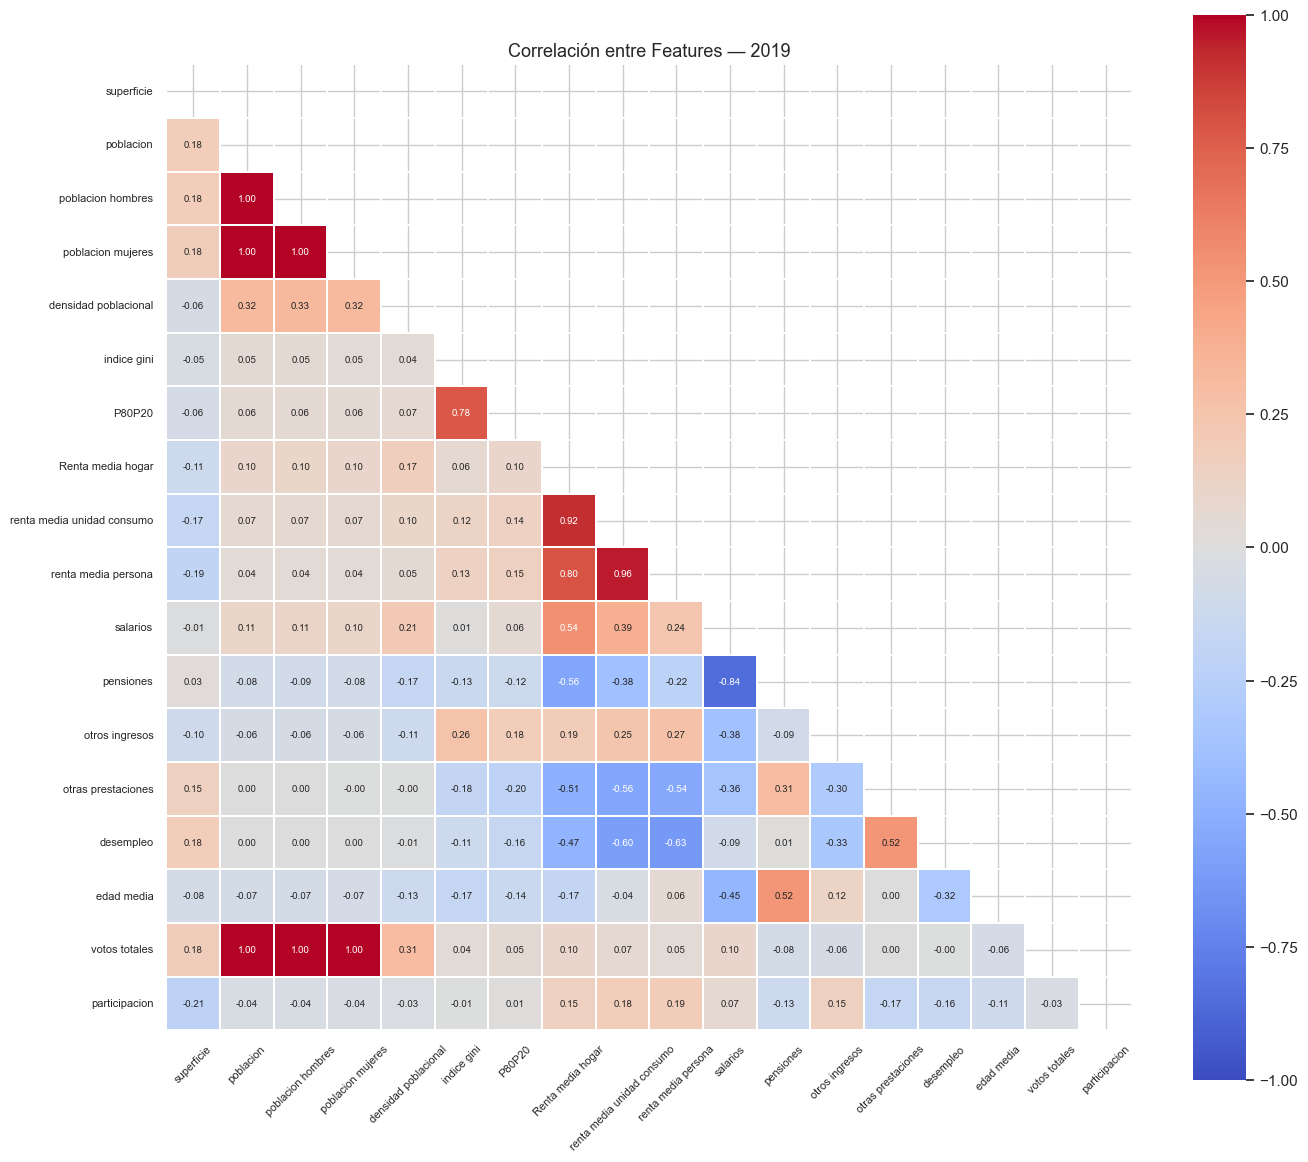

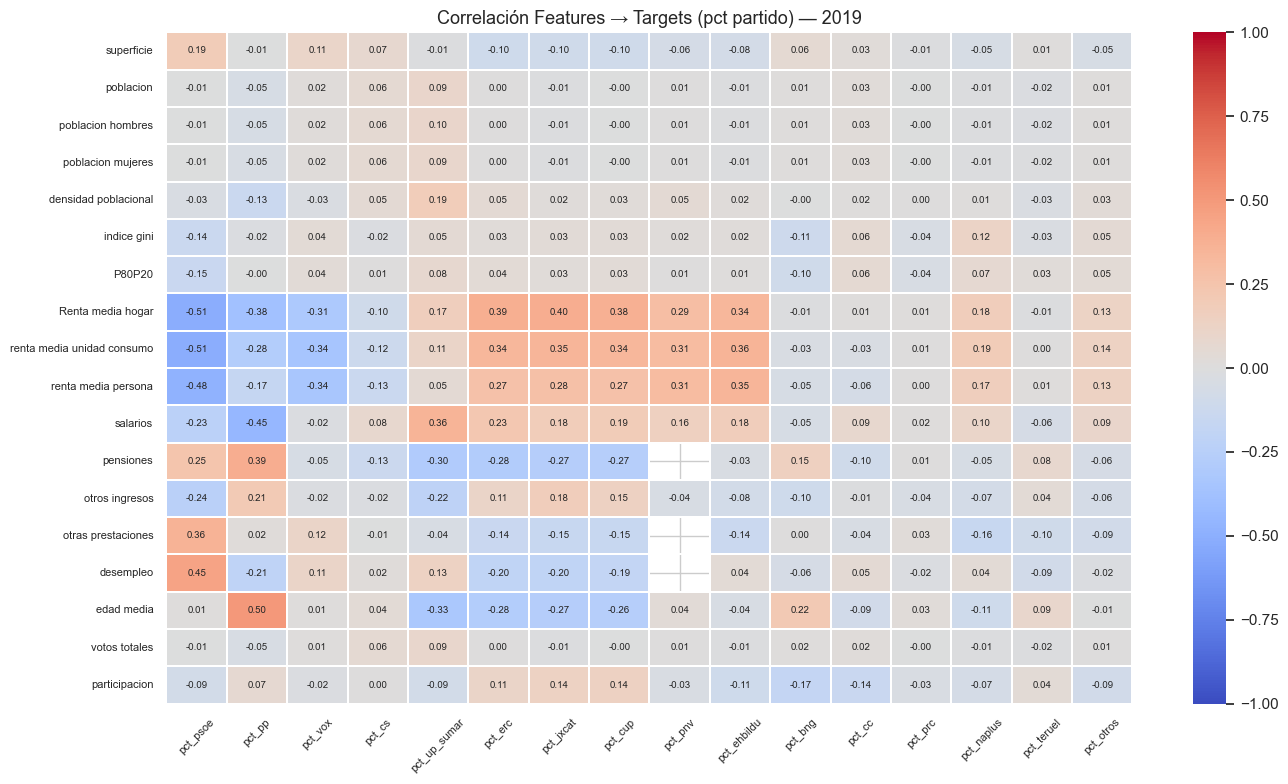

In [37]:
analizar_correlaciones_eda(df_2019_completo, anyo=2019)

### Análisis de correlaciones y selección de variables
Correlación entre variables socioeconómicas (features)
El primer paso antes de construir los modelos de Gradient Boosting fue analizar la estructura de correlaciones entre las variables socioeconómicas disponibles, con el objetivo de identificar redundancias que pudieran introducir multicolinealidad y dificultar la interpretabilidad del modelo.
Como puede observarse en la Figura X, existen varios grupos de variables con una correlación muy elevada entre sí:

* Población, población hombres y población mujeres presentan una correlación prácticamente perfecta (r = 1.00 entre sí). Esto es esperable, ya que las dos últimas son simplemente la desagregación por sexo de la primera. Mantener las tres simultáneamente no aportaría información adicional al modelo, por lo que se descarta poblacion_hombres y poblacion_mujeres, conservando únicamente poblacion como indicador de tamaño demográfico del municipio. De forma análoga, votos_totales correlaciona también con r = 1.00 con las variables de población, lo que indica que en municipios más grandes hay más votos de forma casi lineal; esta variable también se descarta como feature por ser una consecuencia directa del tamaño poblacional y no una característica socioeconómica independiente.

* Renta media del hogar, renta media por unidad de consumo y renta media por persona muestran correlaciones muy altas entre sí (r entre 0.80 y 0.96). Las tres miden esencialmente el nivel de renta del municipio desde ángulos ligeramente distintos, pero su contenido informativo es muy similar. Se opta por conservar renta_media_persona, ya que es la medida más directa del nivel adquisitivo individual y la que habitualmente presenta mayor poder explicativo en estudios electorales de base municipal.

* P80P20 e índice de Gini son ambas medidas de desigualdad con una correlación moderada-alta (r = 0.78). Aunque el P80P20 resulta algo más intuitivo, el análisis de valores ausentes revela que presenta 202 municipios sin dato, frente a tan solo 7 del índice de Gini. Dado que el análisis opera a nivel municipal y la pérdida de observaciones tendría un impacto relevante sobre la capacidad de generalización del modelo, se opta por conservar indice_gini como indicador de desigualdad.

* Pensiones y salarios presentan una correlación negativa significativa (r = −0.84), lo que refleja la composición demográfica de los municipios: aquellos con mayor peso de población mayor tienden a tener más pensionistas y menos asalariados en activo. Ambas variables se conservan, ya que capturan dimensiones distintas y complementarias de la estructura socioeconómica local.

* Otras prestaciones y desempleo muestran una correlación positiva moderada (r = 0.52), coherente con el hecho de que las prestaciones no contributivas suelen estar asociadas a contextos de mayor desempleo estructural. Se conservan las dos, ya que su correlación no es suficientemente alta como para considerarlas redundantes, y cada una puede tener una relación diferenciada con el voto según el partido.

El resto de variables —superficie, densidad_poblacional, edad_media, otros_ingresos y participacion— presentan correlaciones bajas o moderadas con el resto de features, por lo que se mantienen todas en el conjunto inicial de variables.

### Correlación entre variables socioeconómicas y voto por partido (features → targets)
La segunda matriz analizada recoge la correlación de Pearson entre cada variable socioeconómica y el porcentaje de voto obtenido por cada partido en las elecciones generales de 2019. Este análisis permite anticipar qué variables tienen mayor capacidad predictiva y ayuda a interpretar la lógica socioeconómica subyacente a los patrones de voto.
Los resultados más destacados son los siguientes:

* Las variables de renta (renta media del hogar, por unidad de consumo y por persona) son las que presentan correlaciones más altas y consistentes con el voto. Concretamente, la renta correlaciona de forma negativa con el voto al PSOE (r ≈ −0.51) y de forma positiva con partidos regionalistas catalanes o de centro-derecha como Ciudadanos, ERC, Junts per Catalunya o la CUP (r entre 0.27 y 0.40). Este patrón sugiere que los municipios con mayor renta per cápita tienden a votar en mayor medida a partidos no socialistas, un hallazgo consistente con la literatura sobre geografía electoral española.

* La edad media destaca como predictor del voto al PP (r = 0.50), lo que refleja que este partido concentra su apoyo en municipios más envejecidos, especialmente en el mundo rural. En sentido contrario, correlaciona negativamente con los partidos de centro e izquierda.
El desempleo muestra una correlación positiva con el voto al PSOE (r = 0.45) y negativa con partidos de derecha, apuntando a que los municipios con mayor tasa de paro tienden a inclinarse hacia opciones políticas de izquierda. Esta variable, junto con otras_prestaciones (r = 0.36 con PSOE), captura condiciones de vulnerabilidad económica estructural que tienen un reflejo claro en el comportamiento electoral.

* Las pensiones correlacionan positivamente con el PP (r = 0.39) y negativamente con el PSOE (r = −0.30) y partidos de izquierda, reforzando la idea de que los municipios más envejecidos y dependientes de pensiones presentan un perfil de voto más conservador.
Los partidos de ámbito regional no catalan, como EH Bildu, BNG o PNV presentan en general correlaciones bajas con las variables socioeconómicas generales, lo que es coherente con su naturaleza: su apoyo está determinado en mayor medida por la identidad territorial que por factores de renta o empleo comunes al conjunto del territorio español.

* La participación electoral muestra correlaciones débiles con la mayoría de variables socioeconómicas, lo que indica que no es un factor directamente determinado por la situación económica del municipio y que su inclusión como feature tiene sentido para capturar dinámicas de movilización política independientes.

En conjunto, este análisis pone de manifiesto que las variables con mayor capacidad discriminativa son la renta, la edad media, el desempleo, las pensiones y las prestaciones sociales. Estas variables no solo presentan correlaciones más altas con los targets, sino que además capturan dimensiones estructurales del municipio —nivel de vida, composición demográfica y situación laboral— que la literatura electoral identifica como determinantes clave del voto. El resto de variables se mantienen igualmente en el modelo inicial, dado que los algoritmos de Gradient Boosting (XGBoost, LightGBM) son robustos frente a variables poco informativas y aplican su propia selección implícita mediante la importancia de características.



# Aplicamos la imputación también para 2023 para poder hacer los modelos

In [38]:
df_2023_completo = imputar_datos_socioeconomicos(df = df_2023_datos_unificados, w = w, anyo = 2023)

INICIANDO PROCESO DE IMPUTACIÓN SOCIOECONÓMICA (2023)
 -> Imputando Grupo B (Fuentes volátiles) mediante mediana provincial rural
 -> Imputando Grupo A (Indicadores estables) mediante adyacencia física...
 -> Imputando edad media mediante ponderación por género...

   Municipios con edad media imputada: 7976
   Fórmula aplicada:
     edad_media = (edad_media_hombres_prov × pob_hombres
                  + edad_media_mujeres_prov × pob_mujeres)
                  / (pob_hombres + pob_mujeres)
   Fuente provincial: edad_media_provincias_2023.csv

Resultados de Imputación por Provincia:
 - Albacete: 86 municipios imputados.
 - Alicante/Alacant: 133 municipios imputados.
 - Almería: 100 municipios imputados.
 - Araba/Álava: 50 municipios imputados.
 - Asturias: 74 municipios imputados.
 - Badajoz: 163 municipios imputados.
 - Balears, Illes: 64 municipios imputados.
 - Barcelona: 292 municipios imputados.
 - Bizkaia: 107 municipios imputados.
 - Burgos: 370 municipios imputados.
 - Cantabria

# 3. Modelo ML — Predicción de voto por partido

**Objetivo**: predecir el porcentaje de voto de cada partido en cada municipio usando los indicadores socioeconómicos como features.

**Diseño**: se entrena un modelo XGBoost independiente por cada uno de los 15 partidos modelados (pct_otros se calcula como residuo para garantizar que la suma sea 1.0). El entrenamiento usa datos de 2019 y la validación se hace contra los resultados reales de 2023.

**Features usadas** (17 variables): superficie, población, densidad, Gini, P80P20, rentas media, fuente de ingresos (salarios/pensiones/desempleo), edad media y provincia codificada.

### 3.3 Entrenamiento (datos 2019)

Se entrena un modelo XGBoost por cada partido sobre los 8131 municipios de 2019. El MAE que aparece aquí es el **error en train** — sirve para comprobar que el modelo ha aprendido patrones, pero no mide su capacidad de generalización. Para eso usamos 2023.

In [39]:
modelos = entrenar_modelos(df_2019_completo)

ENTRENAMIENTO ML
Municipios train : 8131
Las variables seleccionadas son: ['superficie', 'poblacion', 'densidad poblacional', 'indice gini', 'renta media persona', 'salarios', 'pensiones', 'otros ingresos', 'otras prestaciones', 'desempleo', 'edad media', 'participacion', 'provincia_enc']
Modelos a entrenar: 15

  pct_psoe             MAE train = 0.0359
  pct_pp               MAE train = 0.0336
  pct_vox              MAE train = 0.0236
  pct_cs               MAE train = 0.0109
  pct_up_sumar         MAE train = 0.0203
  pct_erc              MAE train = 0.0027
  pct_jxcat            MAE train = 0.0027
  pct_cup              MAE train = 0.0015
  pct_pnv              MAE train = 0.0001
  pct_ehbildu          MAE train = 0.0017
  pct_bng              MAE train = 0.0004
  pct_cc               MAE train = 0.0002
  pct_prc              MAE train = 0.0002
  pct_naplus           MAE train = 0.0012
  pct_teruel           MAE train = 0.0007

Modelos guardados en 'modelos/modelos_guardados/'


### 3.4 Evaluación — train (2019) vs test (2023)

**Por qué evaluar en los dos años:**
- **2019 (train)**: si el MAE es muy bajo, el modelo ha aprendido bien los datos de entrenamiento.
- **2023 (test)**: este es el resultado que importa. Mide si el modelo generaliza a un año que no ha visto. Si el MAE sube mucho respecto a 2019, hay sobreajuste.

**Cómo leer las métricas:**
- **MAE**: error absoluto medio en puntos porcentuales. Un MAE de 0.03 significa que el modelo se equivoca de media 3 puntos porcentuales por municipio.
- **R²**: proporción de varianza explicada. Un R² de 0.8 significa que el modelo explica el 80% de la variación del voto entre municipios. Por encima de 0.5 es razonable para partidos estatales. Los regionalistas (PNV, Bildu, ERC...) tendrán R² más alto porque su distribución geográfica está muy correlada con la provincia.

In [40]:
metricas_train = evaluar_modelos(modelos, df_2019_completo, etiqueta="2019 (train)")


METRICAS — 2019 (train)
 partido    MAE   RMSE     R2  media_real
     pnv 0.0001 0.0008 0.9999      0.0116
      cc 0.0002 0.0006 0.9989      0.0018
     prc 0.0002 0.0007 0.9994      0.0031
     bng 0.0004 0.0010 0.9964      0.0029
  teruel 0.0007 0.0027 0.9952      0.0058
  naplus 0.0012 0.0037 0.9955      0.0093
     cup 0.0015 0.0037 0.9900      0.0116
 ehbildu 0.0017 0.0052 0.9958      0.0178
     erc 0.0027 0.0062 0.9964      0.0362
   jxcat 0.0027 0.0063 0.9950      0.0293
      cs 0.0109 0.0156 0.8081      0.0510
up_sumar 0.0203 0.0279 0.8517      0.0985
     vox 0.0236 0.0319 0.8612      0.1423
      pp 0.0336 0.0460 0.9212      0.2730
    psoe 0.0359 0.0478 0.8740      0.2895


In [41]:
metricas_test = evaluar_modelos(modelos, df_2023_completo, etiqueta="2023 (test)")


METRICAS — 2023 (test)
 partido    MAE   RMSE     R2  media_real
      cc 0.0021 0.0158 0.2453      0.0017
     prc 0.0037 0.0248 0.0000      0.0000
     pnv 0.0039 0.0221 0.8332      0.0092
     bng 0.0039 0.0131 0.5144      0.0035
  naplus 0.0057 0.0198 0.5885      0.0050
  teruel 0.0057 0.0215 0.4324      0.0058
     cup 0.0085 0.0202 0.2566      0.0065
 ehbildu 0.0145 0.0480 0.7060      0.0200
   jxcat 0.0233 0.0556 0.4534      0.0246
     erc 0.0262 0.0569 0.3006      0.0232
up_sumar 0.0404 0.0527 0.2641      0.0847
     vox 0.0451 0.0613 0.2612      0.1237
      cs 0.0559 0.0595 0.0000      0.0000
    psoe 0.0752 0.0965 0.2706      0.3068
      pp 0.1121 0.1416 0.2884      0.3604


**Gráfico de métricas 2023**: barras horizontales de MAE y R² por partido. Permite identificar de un vistazo qué partidos predice bien el modelo (MAE bajo, R² alto) y cuáles son más difíciles de predecir (VOX y Cs suelen ser los más volátiles entre elecciones).

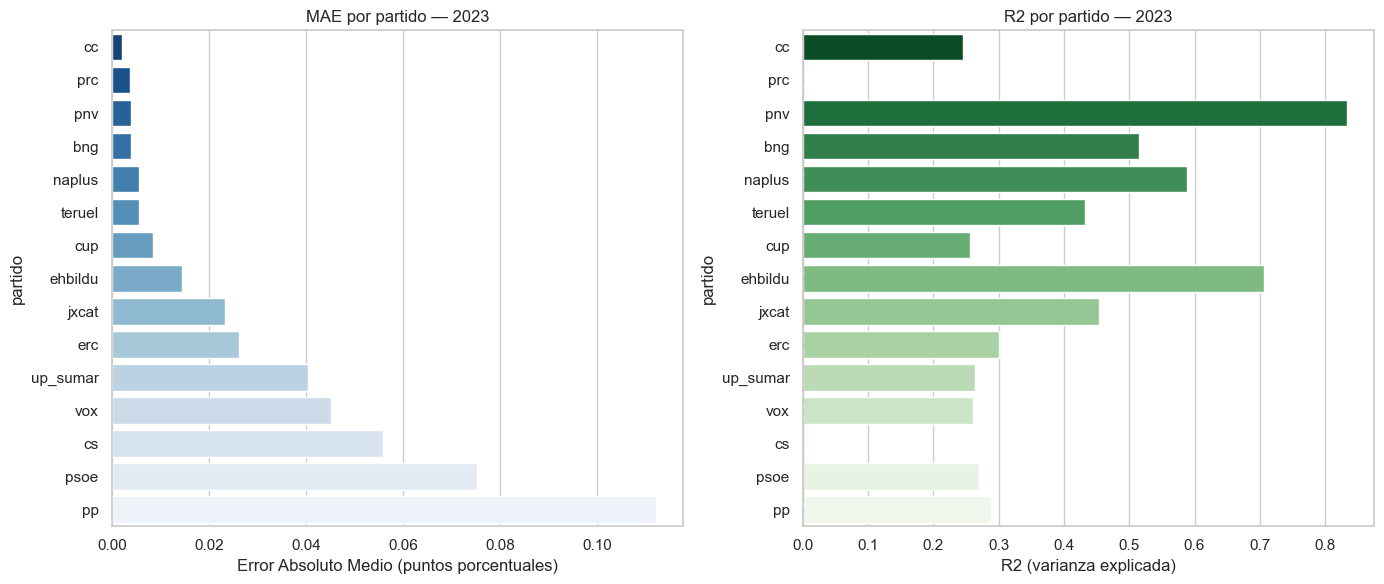

In [42]:
visualizar_metricas(metricas_test, etiqueta="2023")

### 3.5 Predicción 2023

El pipeline ejecuta 3 pasos:
1. **Predicción**: cada uno de los 15 modelos genera su pct para los 8131 municipios.
2. **Normalización**: se calcula pct_otros = 1 - suma(15 predicciones), garantizando que los 16 slots sumen exactamente 1.0 por municipio.
3. **Conversión a votos**: se multiplica cada pct predicho por los votos totales reales de 2023 (el modelo predice el *reparto* del voto, no la participación).

El resultado es un dataframe con columnas pct_* (porcentaje predicho) y votos_* (votos absolutos predichos), listo para alimentar la Ley D'Hondt.

In [43]:
df_predicciones_2023 = pipeline_prediccion(modelos, df_2023_completo)

Paso 1: Prediciendo porcentajes por municipio...
Paso 2: Normalizando (calculando pct_otros como residuo)...
  Desviacion media de la suma respecto a 1.0: 3.16e-08
Paso 3: Convirtiendo a votos absolutos con votos totales reales...
Prediccion completada: 8131 municipios


### 3.6 Interpretabilidad — SHAP

**Qué es SHAP**: descompone la predicción de cada municipio en la contribución de cada feature. Permite responder preguntas como: *¿qué variables hacen que un municipio vote más al PSOE?*

**Cómo leer el gráfico de importancia global**: cada fila es una feature, el valor es la media del |SHAP| promediado sobre todos los partidos y municipios. Las features más altas son las que más influyen en el modelo en general.

**Heatmap**: muestra la importancia relativa de cada feature para cada partido. Permite ver si los mismos indicadores importan para todos los partidos o si cada uno responde a variables distintas.

In [44]:
# Importancia global de features
#df_importancia = importancia_global_shap(modelos, df_2019_completo)
#heatmap_importancia_shap(df_importancia)

**SHAP por partido**: muestra para un partido concreto cómo cada feature empuja el voto hacia arriba (rojo) o hacia abajo (azul). El eje X es el valor SHAP (impacto en la predicción) y el color indica si el valor de la feature es alto o bajo.

Por ejemplo en pct_psoe: si la feature pensiones aparece en rojo con SHAP positivo, significa que municipios con alta proporción de pensionistas votan más al PSOE.

Cambia pct_psoe por cualquier otro partido para explorar.

In [45]:
#analizar_shap_partido(modelos, df_2019_completo, partido="pct_psoe")

In [46]:
#analizar_shap_partido(modelos, df_2019_completo, partido="pct_pp")

In [47]:
#analizar_shap_partido(modelos, df_2019_completo, partido="pct_vox")

In [48]:
#analizar_shap_partido(modelos, df_2019_completo, partido="pct_up_sumar")

In [49]:
#df_direccion = heatmap_direccion_shap(modelos, df_2019_completo)

### Análisis de valores SHAP por variable y partido
Una vez entrenados los modelos de Gradient Boosting, se calcularon los valores SHAP para cuantificar la contribución de cada variable socioeconómica sobre la predicción del porcentaje de voto de cada partido. La matriz resultante recoge el efecto relativo normalizado de cada variable, donde valores positivos (rojo) indican que la variable aumenta el voto predicho y valores negativos (azul) que lo reduce.

La variable provincia_enc sirve para que el modelo aprenda en que regiones y en cuales no se presentan los aprtidos regionalistas.

**Variables con mayor poder explicativo global**

**edad_media** es la variable con mayor capacidad discriminativa del conjunto, presentando efectos fuertes y de signo opuesto según el partido. Un municipio más envejecido favorece claramente el voto al PP (SHAP = 1.00) y en menor medida a Naplus y Teruel Existe (0.50 y 0.80 respectivamente), mientras que penaliza de forma muy intensa el voto a CUP (−1.00), PRC (−1.00), ERC (−0.88) y PSOE (−0.85). Este resultado es coherente con la conocida brecha generacional en el voto español: los municipios más envejecidos, predominantemente rurales, tienden a concentrar el voto conservador.

**desempleo** es la segunda variable más influyente. Aumenta el voto a ERC (1.00), Junts (1.00), UP/Sumar (0.60) y CUP (0.95), y lo reduce en Ciudadanos (−1.00) y PP (−0.38). Este patrón resulta llamativo en el caso de los partidos independentistas catalanes, y podría reflejar que los municipios catalanes con mayor desempleo tienen también un perfil de voto más movilizado hacia opciones soberanistas de izquierda.

**renta_media_persona** muestra un efecto negativo sobre VOX (−1.00) y PP (−0.60), y positivo sobre PSOE (0.28) y Ciudadanos (0.37). Este resultado es contraintuitivo respecto a la narrativa habitual que asocia mayor renta con voto de derechas, y merece una reflexión: en el contexto municipal español, los municipios de mayor renta per cápita son frecuentemente grandes urbes donde el voto a PP y VOX no es mayoritario, mientras que el voto a partidos de centro o izquierda urbana sí lo es.
poblacion penaliza el voto al PSOE (−0.80), VOX (−0.65) y BNG (−0.82), y tiene efectos más neutros en el resto. Esto apunta a que estos partidos obtienen proporcionalmente más voto en municipios pequeños y medianos que en grandes ciudades.

**Variables de estructura económica y laboral**

**pensiones** tiene un efecto positivo sobre VOX (0.95) y PP (0.57), y negativo sobre PNV (−0.69), reforzando el perfil demográfico ya apuntado por edad_media: los municipios con mayor peso de pensionistas —más envejecidos y rurales— votan en mayor medida a la derecha.

**salarios** favorece el voto al PNV (0.85) y Ciudadanos (0.56), y lo reduce en Naplus (−0.50). Los municipios con mayor peso salarial —más industriales y urbanos— presentan un perfil de voto más orientado hacia partidos de centro y nacionalismo vasco moderado.

**desempleo y otras prestaciones** actúan en direcciones similares para varios partidos, capturando conjuntamente la dimensión de vulnerabilidad económica estructural del municipio. otras prestaciones penaliza el voto a Ciudadanos (−0.54) y Naplus (−0.76), y lo incrementa ligeramente para Teruel Existe (0.47), lo que tiene sentido dado el perfil de municipios despoblados y con mayor dependencia de prestaciones que caracterizan el electorado de este partido.

**otros ingresos** presenta su efecto más destacado en el PNV (0.52) y penaliza el voto a Naplus (−0.78), aunque en general su impacto es moderado en el resto de partidos.

**Variables con menor aportación explicativa**

**indice_gini, participacion y superficie** presentan valores SHAP reducidos y poco consistentes en la mayoría de partidos, lo que indica que su contribución al modelo es marginal. En una iteración futura del modelo podría valorarse su eliminación para simplificar el pipeline, aunque dado que el Gradient Boosting penaliza implícitamente las variables poco informativas mediante su mecanismo de selección de splits, su presencia no perjudica el rendimiento.

**Síntesis**

En conjunto, el análisis SHAP confirma que las variables con mayor poder explicativo para la predicción del voto municipal son edad_media, desempleo, renta_media_persona, poblacion y pensiones. Estas cinco variables capturan tres ejes estructurales del comportamiento electoral a nivel municipal: la composición demográfica (edad, pensiones), el nivel y estructura económica (renta, salarios) y la situación laboral (desempleo, prestaciones). El resto de variables aportan información complementaria, especialmente para partidos de ámbito regional cuyo voto responde a dinámicas territoriales más específicas.

# Modelo con ajuste de hyperpatametros 

In [50]:
# --- Tuning (primera vez es lento ~20-40 min, luego carga caché automáticamente) ---
modelos_tuned = tunear_todos_modelos(df_2019_completo, n_iter=30, cv=5)

Modelos tuned encontrados en 'modelos/modelos_tuned/' — cargando sin re-tunear.
  (Usa forzar=True para volver a ejecutar el tuning.)
Cargados 15 modelos desde 'modelos/modelos_tuned/'


In [51]:
# --- Evaluación (reutiliza evaluar_modelos existente) ---
metricas_train_tuned = evaluar_modelos(modelos_tuned, df_2019_completo, etiqueta="2019 tuned (train)")
metricas_test_tuned  = evaluar_modelos(modelos_tuned, df_2023_completo, etiqueta="2023 tuned (test)")


METRICAS — 2019 tuned (train)
 partido    MAE   RMSE     R2  media_real
     prc 0.0002 0.0006 0.9995      0.0031
     bng 0.0011 0.0051 0.9033      0.0029
     pnv 0.0012 0.0085 0.9843      0.0116
      cc 0.0029 0.0157 0.2765      0.0018
  teruel 0.0035 0.0176 0.7879      0.0058
     cup 0.0075 0.0186 0.7422      0.0116
 ehbildu 0.0083 0.0330 0.8327      0.0178
  naplus 0.0083 0.0330 0.6466      0.0093
   jxcat 0.0139 0.0343 0.8497      0.0293
     erc 0.0152 0.0344 0.8884      0.0362
      cs 0.0223 0.0313 0.2329      0.0510
up_sumar 0.0343 0.0484 0.5528      0.0985
     vox 0.0492 0.0646 0.4311      0.1423
      pp 0.0637 0.0882 0.7110      0.2730
    psoe 0.0652 0.0873 0.5799      0.2895

METRICAS — 2023 tuned (test)
 partido    MAE   RMSE      R2  media_real
      cc 0.0032 0.0180  0.0194      0.0017
     pnv 0.0034 0.0210  0.8500      0.0092
     prc 0.0036 0.0252  0.0000      0.0000
     bng 0.0044 0.0135  0.4837      0.0035
  teruel 0.0050 0.0176  0.6227      0.0058
  naplus 

  COMPARACIÓN BASELINE vs TUNED — 2023 (test)

MAE (↓ mejor):
 partido  MAE_base  MAE_tuned  mejora_pp  mejora_pct
      pp    0.1121     0.1151    -0.0030        -2.7
    psoe    0.0752     0.0773    -0.0021        -2.8
      cs    0.0559     0.0526     0.0033         5.9
     vox    0.0451     0.0488    -0.0037        -8.2
up_sumar    0.0404     0.0389     0.0015         3.7
     erc    0.0262     0.0281    -0.0019        -7.3
   jxcat    0.0233     0.0256    -0.0023        -9.9
 ehbildu    0.0145     0.0152    -0.0007        -4.8
     cup    0.0085     0.0089    -0.0004        -4.7
  teruel    0.0057     0.0050     0.0007        12.3
  naplus    0.0057     0.0088    -0.0031       -54.4
     bng    0.0039     0.0044    -0.0005       -12.8
     pnv    0.0039     0.0034     0.0005        12.8
     prc    0.0037     0.0036     0.0001         2.7
      cc    0.0021     0.0032    -0.0011       -52.4

R² (↑ mejor):
 partido  R2_base  R2_tuned  mejora_pp  mejora_pct
     pnv   0.8332    0.8

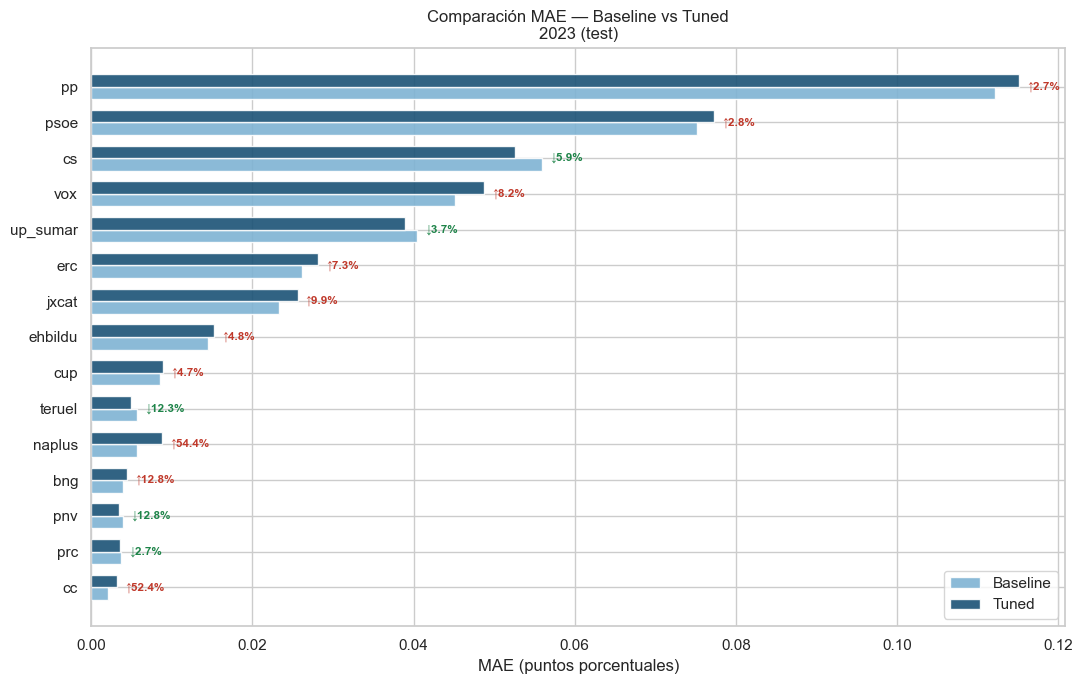

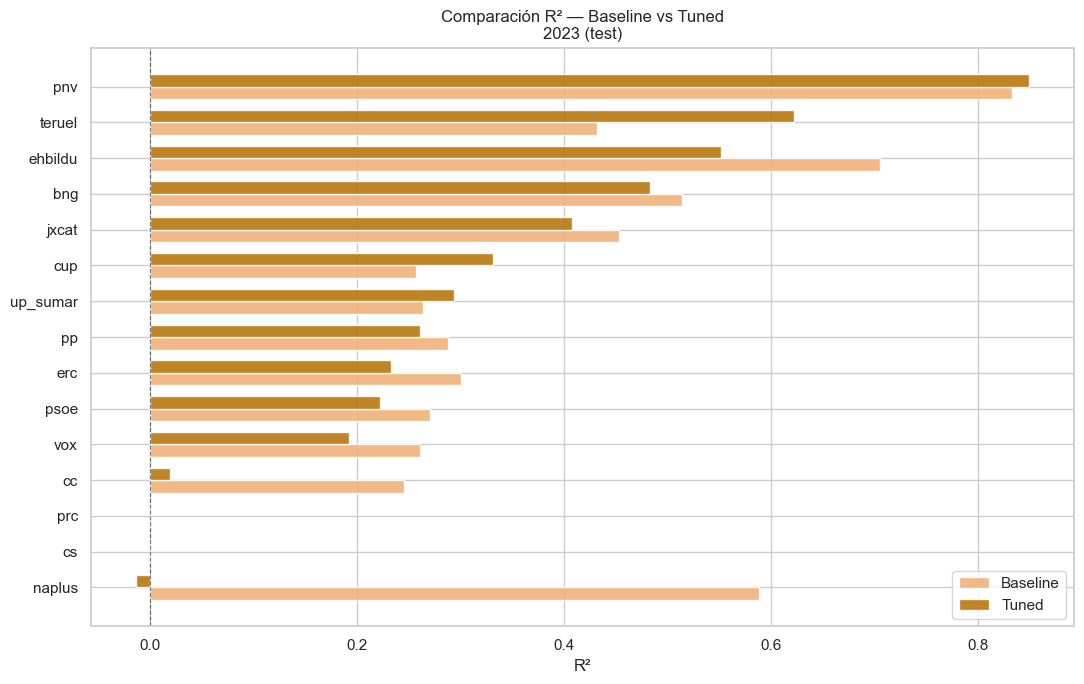

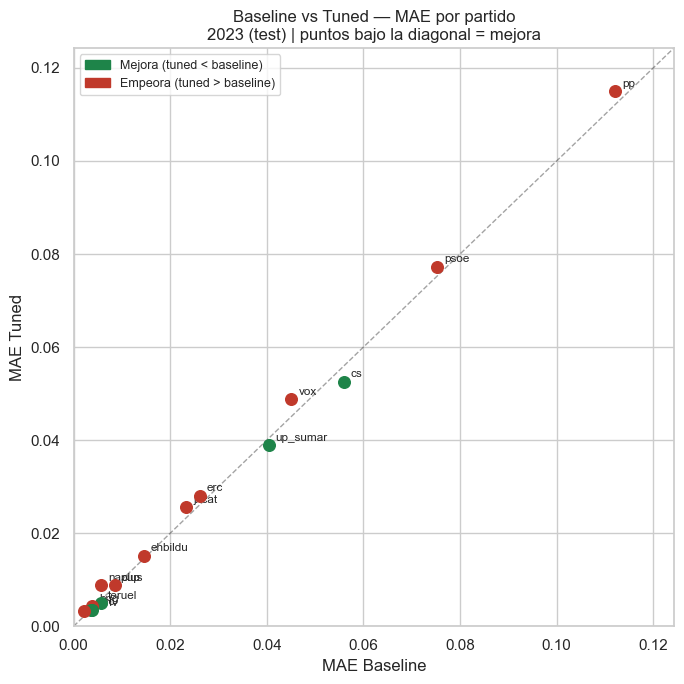

In [52]:
pipeline_comparacion(metricas_test, metricas_test_tuned, etiqueta="2023 (test)")

Conclusión del proceso de tuning — ¿por qué nos quedamos con el modelo baseline?
 
El proceso de ajuste de hiperparámetros mediante RandomizedSearchCV (30 iteraciones, 5-fold CV) encontró configuraciones más regularizadas que el baseline, reduciendo el ratio overfitting en train significativamente — PP pasó de ×3.3 a ×1.8 y VOX quedó prácticamente en ×1.0. Sin embargo, al evaluar ambos modelos sobre los datos reales de 2023, el tuned empeoró en 10 de 15 partidos.

Este resultado aparentemente paradójico tiene una explicación clara: el límite del modelo no está en los hiperparámetros sino en el desplazamiento distribucional entre elecciones. El modelo aprende la estructura socioeconómica del voto en 2019, pero entre 2019 y 2023 se produjeron cambios políticos (recuperación del PP bajo Feijóo, formación de Sumar, colapso de Cs) que no están codificados en ninguna variable del dataset. Ninguna combinación de hiperparámetros puede predecir lo que las features no contienen.

Adicionalmente, el modelo tuned presenta underfitting en CC (R²=0.28 en train), Cs (R²=0.23 en train) y UP/Sumar (R²=0.55 en train), lo que indica que la regularización impuesta por el CV fue excesiva para partidos con distribuciones geográficas muy concentradas o poco estables.

Por tanto, se descarta el modelo tuned y se continúa con el baseline para las fases de análisis SHAP y simulación D'Hondt. Esta decisión no implica que el tuning fuera innecesario — el ejercicio confirma empíricamente que la barrera de mejora es de naturaleza estructural (datos, no modelo) y aporta una conclusión relevante para la memoria: las variables socioeconómicas explican la estructura estable del voto pero no su dinámica entre elecciones.

Ahora aplicamos la ley d'hont

  SIMULACIÓN LEY D'HONDT

Paso 1 — Escaños predichos:
  [Predicho] Generando predicciones por municipio...
Paso 1: Prediciendo porcentajes por municipio...
Paso 2: Normalizando (calculando pct_otros como residuo)...
  Desviacion media de la suma respecto a 1.0: 3.16e-08
Paso 3: Convirtiendo a votos absolutos con votos totales reales...
Prediccion completada: 8131 municipios
  [Predicho] Agregando a nivel provincial...
  [Predicho] Aplicando Ley D'Hondt...
  [Predicho] Total escaños repartidos: 350

Paso 2 — Escaños reales (benchmark slots):
  [Real] Calculando votos reales por slot...
  [Real] Aplicando Ley D'Hondt...
  [Real] Total escaños repartidos: 350

Paso 3 — Tabla comparativa:
 partido  escanos_pred  escanos_real  error
      pp            96           136    -40
    psoe           123           122      1
     vox            44            33     11
up_sumar            48            31     17
     erc            11             7      4
   jxcat             5             7     -

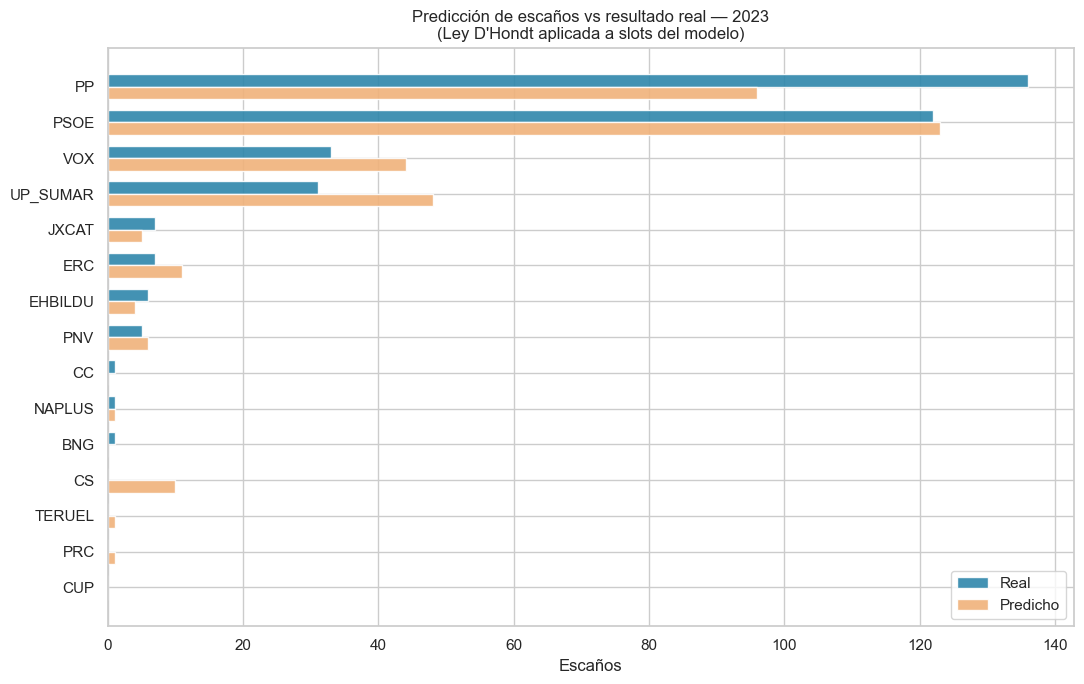

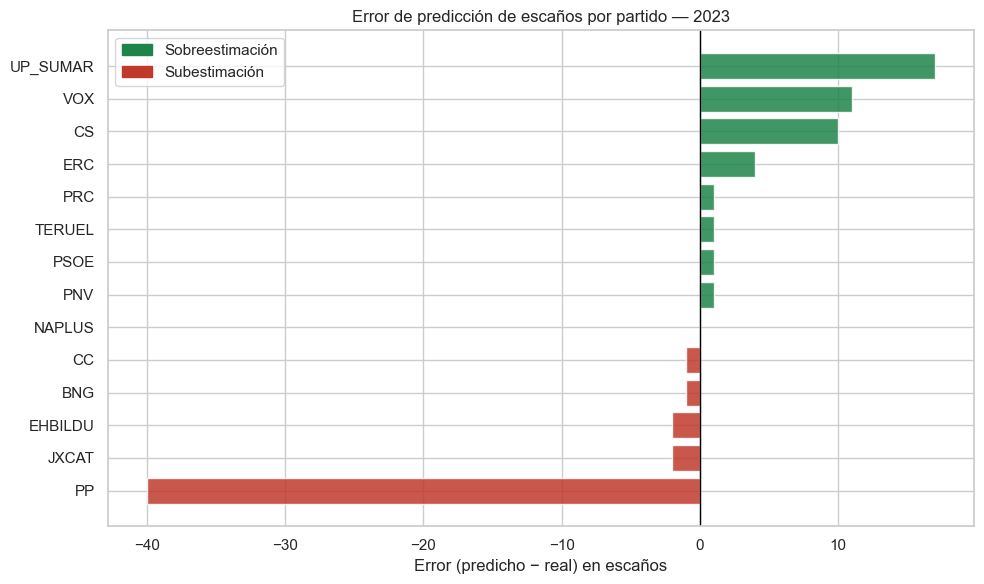

In [53]:
with open('config_path.json') as f:
    config = json.load(f)

ruta_json_pob = config['2023']['processed']['poblacion_json']

df_escanos = pipeline_comparacion_dhondt(modelos, df_2023_completo, ruta_json_pob)

## 4. Visualización de resultados — Hemiciclo y mapa provincial

Se generan dos visualizaciones comparativas (real vs predicho):

- **Hemiciclo**: distribución de los 350 escaños del Congreso coloreados por partido en orden político izquierda→derecha.
- **Mapa provincial**: mapa de España coloreado por el partido más votado en cada provincia.

Ambas imágenes se guardan en `documentation/imagenes_EDA/`.

  VISUALIZACIÓN DE RESULTADOS ELECTORALES

[1/4] Prediciendo votos por municipio...
Paso 1: Prediciendo porcentajes por municipio...
Paso 2: Normalizando (calculando pct_otros como residuo)...
  Desviacion media de la suma respecto a 1.0: 3.16e-08
Paso 3: Convirtiendo a votos absolutos con votos totales reales...
Prediccion completada: 8131 municipios
[2/4] Agregando a nivel provincial...
[3/4] Calculando D'Hondt y ganadores por provincia...
[4/4] Generando gráficos...


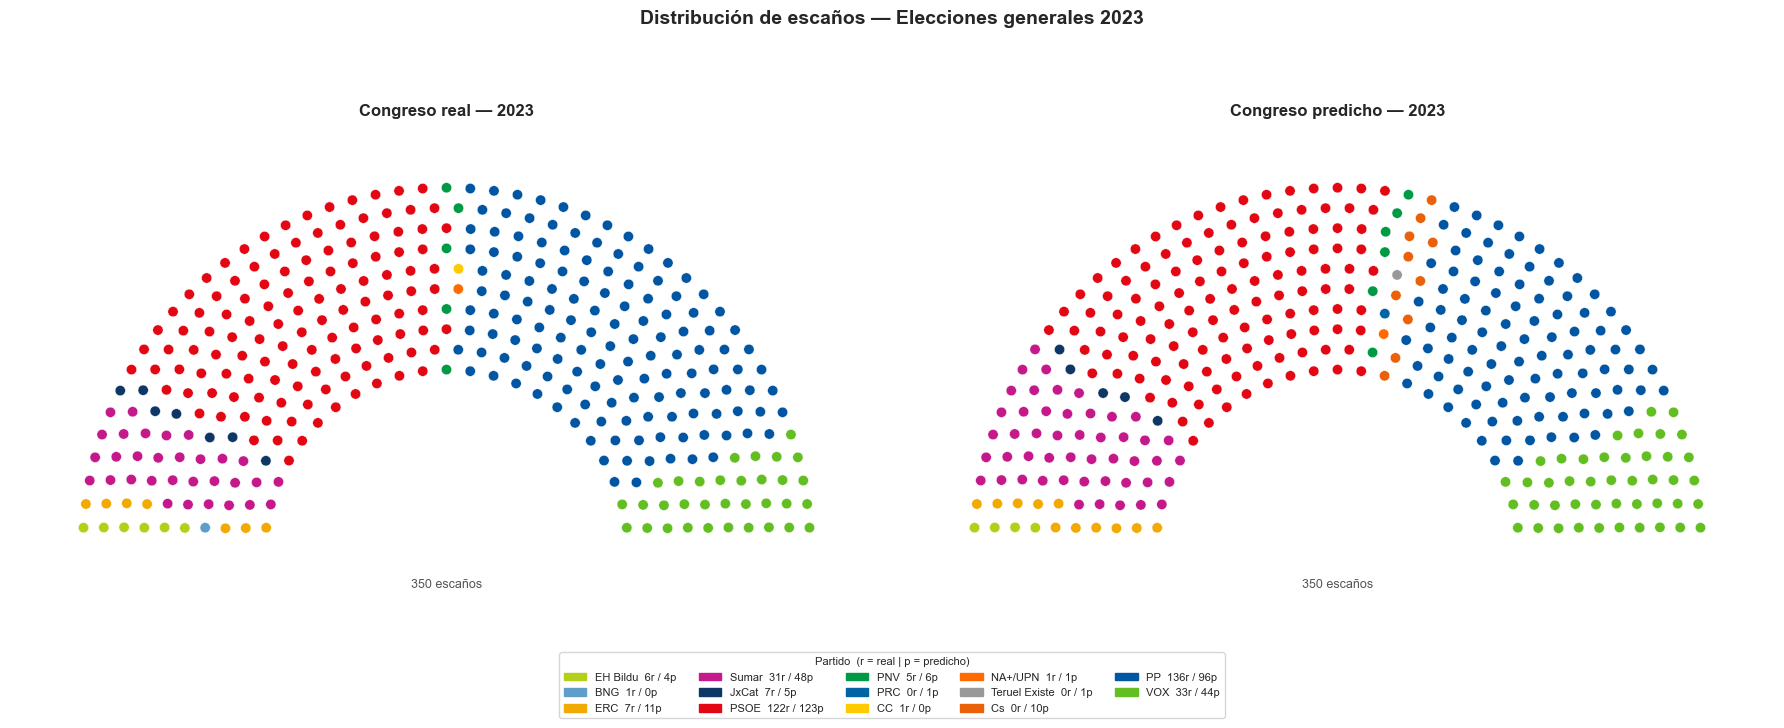

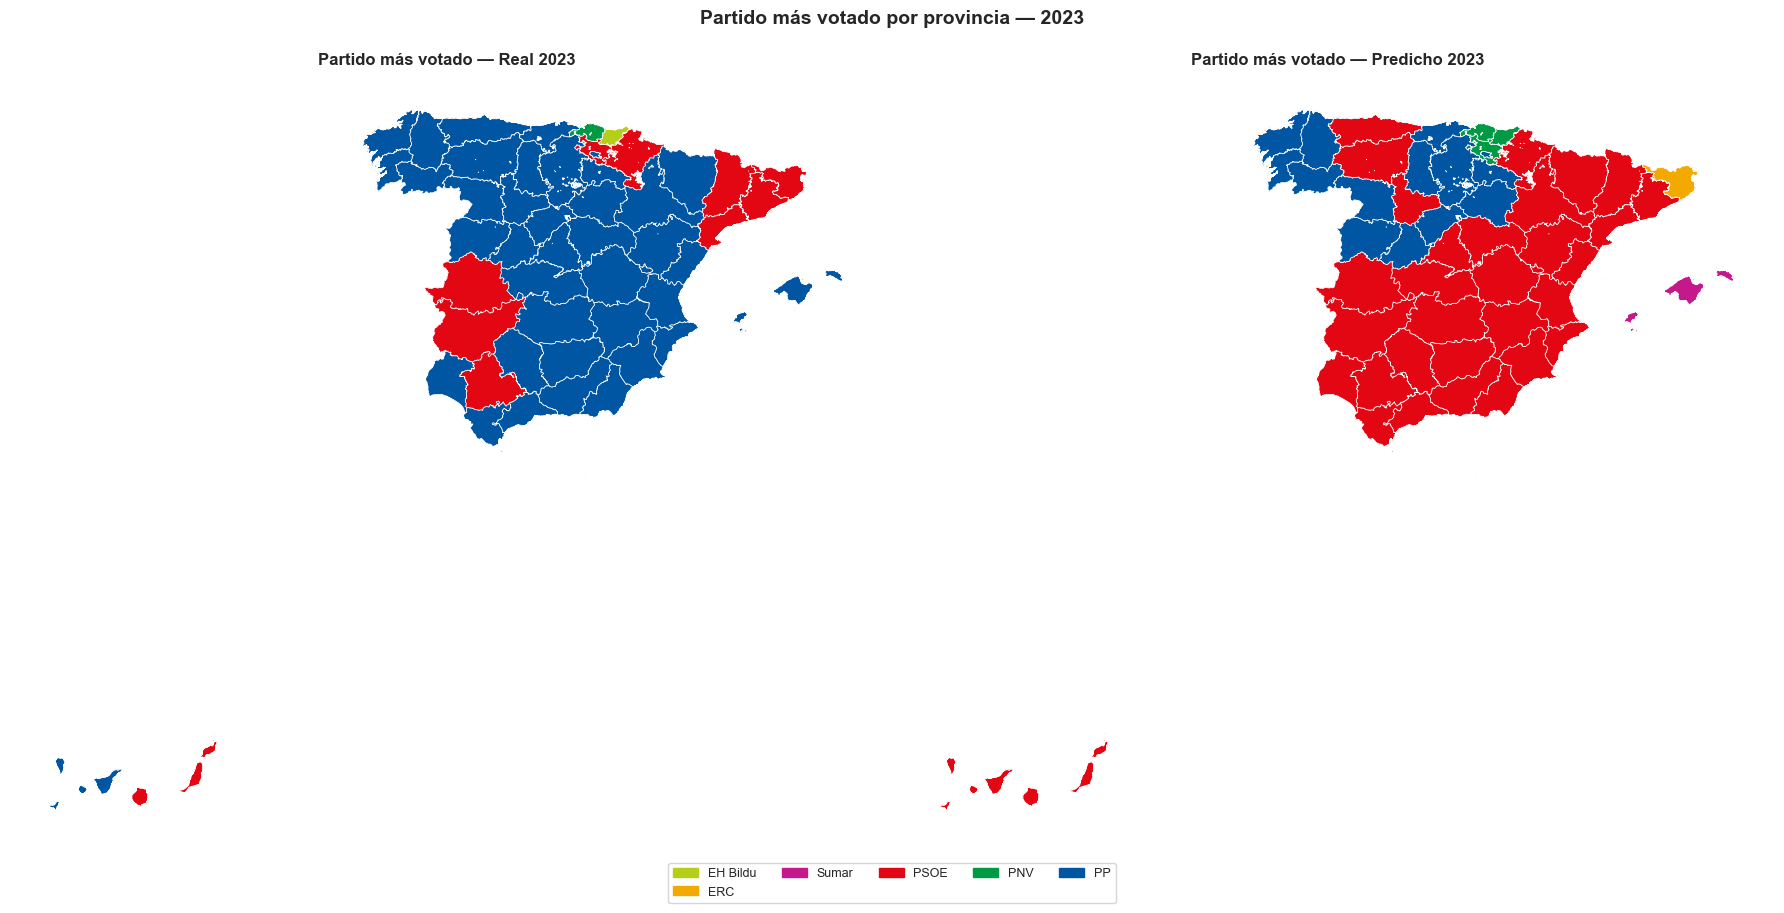


Listo. Imágenes en documentation/imagenes_EDA


In [54]:
ruta_parquet = "data_processed/geografia/mapa_municipios.parquet"

pipeline_visualizacion(
    modelos,
    df_2023_completo,
    ruta_json_pob,
    ruta_parquet,
    etiqueta="2023",
    guardar=True,
)

## 5. Modelos mejorados — comparativa con el baseline

Se entrenan dos versiones adicionales para evaluar si las mejoras identificadas
reducen el error de prediccion en 2023:

- **V2** (Mejora A): mismo modelo global con `grupo_tamano` como feature adicional
  (rural=0 / semiurbano=1 / urbano=2).
- **Subgrupos** (Mejora E): tres modelos independientes entrenados cada uno
  solo con municipios de su rango de tamaño.

Los modelos originales en `modelos/modelos_guardados/` no se modifican.

### 5.1 Modelo V2 — baseline + grupo_tamano

In [55]:
modelos_v2 = entrenar_modelos_v2(df_2019_completo)

ENTRENAMIENTO ML V2  (baseline + grupo_tamano)
Municipios train : 8131
Features (14): ['superficie', 'poblacion', 'densidad poblacional', 'indice gini', 'renta media persona', 'salarios', 'pensiones', 'otros ingresos', 'otras prestaciones', 'desempleo', 'edad media', 'participacion', 'provincia_enc', 'grupo_tamano']

  pct_psoe             MAE train = 0.0359
  pct_pp               MAE train = 0.0332
  pct_vox              MAE train = 0.0236
  pct_cs               MAE train = 0.0109
  pct_up_sumar         MAE train = 0.0204
  pct_erc              MAE train = 0.0027
  pct_jxcat            MAE train = 0.0027
  pct_cup              MAE train = 0.0015
  pct_pnv              MAE train = 0.0001
  pct_ehbildu          MAE train = 0.0018
  pct_bng              MAE train = 0.0004
  pct_cc               MAE train = 0.0002
  pct_prc              MAE train = 0.0003
  pct_naplus           MAE train = 0.0012
  pct_teruel           MAE train = 0.0007

Modelos v2 guardados en 'modelos/modelos_v2/'


In [56]:
metricas_train_v2 = evaluar_modelos_v2(modelos_v2, df_2019_completo, etiqueta="2019 v2 (train)")
metricas_test_v2  = evaluar_modelos_v2(modelos_v2, df_2023_completo, etiqueta="2023 v2 (test)")


METRICAS — 2019 v2 (train)
 partido    MAE   RMSE     R2  media_real
     pnv 0.0001 0.0008 0.9999      0.0116
      cc 0.0002 0.0006 0.9989      0.0018
     prc 0.0003 0.0007 0.9994      0.0031
     bng 0.0004 0.0009 0.9969      0.0029
  teruel 0.0007 0.0026 0.9954      0.0058
  naplus 0.0012 0.0036 0.9958      0.0093
     cup 0.0015 0.0036 0.9906      0.0116
 ehbildu 0.0018 0.0052 0.9959      0.0178
     erc 0.0027 0.0059 0.9967      0.0362
   jxcat 0.0027 0.0061 0.9953      0.0293
      cs 0.0109 0.0157 0.8063      0.0510
up_sumar 0.0204 0.0280 0.8500      0.0985
     vox 0.0236 0.0319 0.8610      0.1423
      pp 0.0332 0.0454 0.9233      0.2730
    psoe 0.0359 0.0478 0.8739      0.2895

METRICAS — 2023 v2 (test)
 partido    MAE   RMSE     R2  media_real
      cc 0.0018 0.0141 0.4013      0.0017
     prc 0.0036 0.0259 0.0000      0.0000
     pnv 0.0038 0.0216 0.8403      0.0092
     bng 0.0039 0.0127 0.5476      0.0035
  teruel 0.0055 0.0210 0.4591      0.0058
  naplus 0.0061 0.020

### 5.2 Modelos por subgrupos — rural / semiurbano / urbano

In [57]:
modelos_sub = entrenar_modelos_subgrupos(df_2019_completo)


== Grupo 'rural'  (<1000 hab)  —  5000 municipios ==


  pct_psoe             MAE train = 0.0368  (n=5000)
  pct_pp               MAE train = 0.0358  (n=5000)
  pct_vox              MAE train = 0.0241  (n=5000)
  pct_cs               MAE train = 0.0114  (n=5000)
  pct_up_sumar         MAE train = 0.0187  (n=5000)
  pct_erc              MAE train = 0.0016  (n=5000)
  pct_jxcat            MAE train = 0.0018  (n=5000)
  pct_cup              MAE train = 0.0010  (n=5000)
  pct_pnv              MAE train = 0.0001  (n=5000)
  pct_ehbildu          MAE train = 0.0013  (n=5000)
  pct_bng              MAE train = 0.0001  (n=5000)
  [SKIP] pct_cc               — solo 1 municipios con voto>0
  pct_prc              MAE train = 0.0002  (n=5000)
  pct_naplus           MAE train = 0.0010  (n=5000)
  pct_teruel           MAE train = 0.0010  (n=5000)

== Grupo 'semiurbano'  (1000-50000 hab)  —  2983 municipios ==
  pct_psoe             MAE train = 0.0118  (n=2983)
  pct_pp               MAE train = 0.0095  (n=2983)
  pct_vox              MAE train = 0.0074  

In [58]:
metricas_train_sub = evaluar_modelos_subgrupos(
    modelos_sub, df_2019_completo,
    modelos_fallback=modelos,
    etiqueta="2019 subgrupos (train)"
)
metricas_test_sub = evaluar_modelos_subgrupos(
    modelos_sub, df_2023_completo,
    modelos_fallback=modelos,
    etiqueta="2023 subgrupos (test)"
)


METRICAS — 2019 subgrupos (train)
 partido    MAE   RMSE      R2  media_real
     bng 0.0001 0.0006  0.9986      0.0029
     prc 0.0001 0.0006  0.9995      0.0031
     pnv 0.0001 0.0005  0.9999      0.0116
  naplus 0.0005 0.0023  0.9982      0.0093
     cup 0.0007 0.0020  0.9969      0.0116
 ehbildu 0.0008 0.0032  0.9984      0.0178
     erc 0.0011 0.0031  0.9991      0.0362
   jxcat 0.0013 0.0037  0.9983      0.0293
      cc 0.0019 0.0111  0.6368      0.0018
  teruel 0.0068 0.0406 -0.1292      0.0058
      cs 0.0081 0.0129  0.8695      0.0510
up_sumar 0.0146 0.0213  0.9138      0.0985
     vox 0.0176 0.0262  0.9067      0.1423
      pp 0.0254 0.0387  0.9443      0.2730
    psoe 0.0270 0.0392  0.9151      0.2895

METRICAS — 2023 subgrupos (test)
 partido    MAE   RMSE      R2  media_real
      cc 0.0027 0.0158  0.2403      0.0017
     prc 0.0031 0.0241  0.0000      0.0000
     pnv 0.0036 0.0225  0.8276      0.0092
     bng 0.0038 0.0155  0.3205      0.0035
  naplus 0.0059 0.0283  0.15

### 5.3 Comparativa de los tres modelos

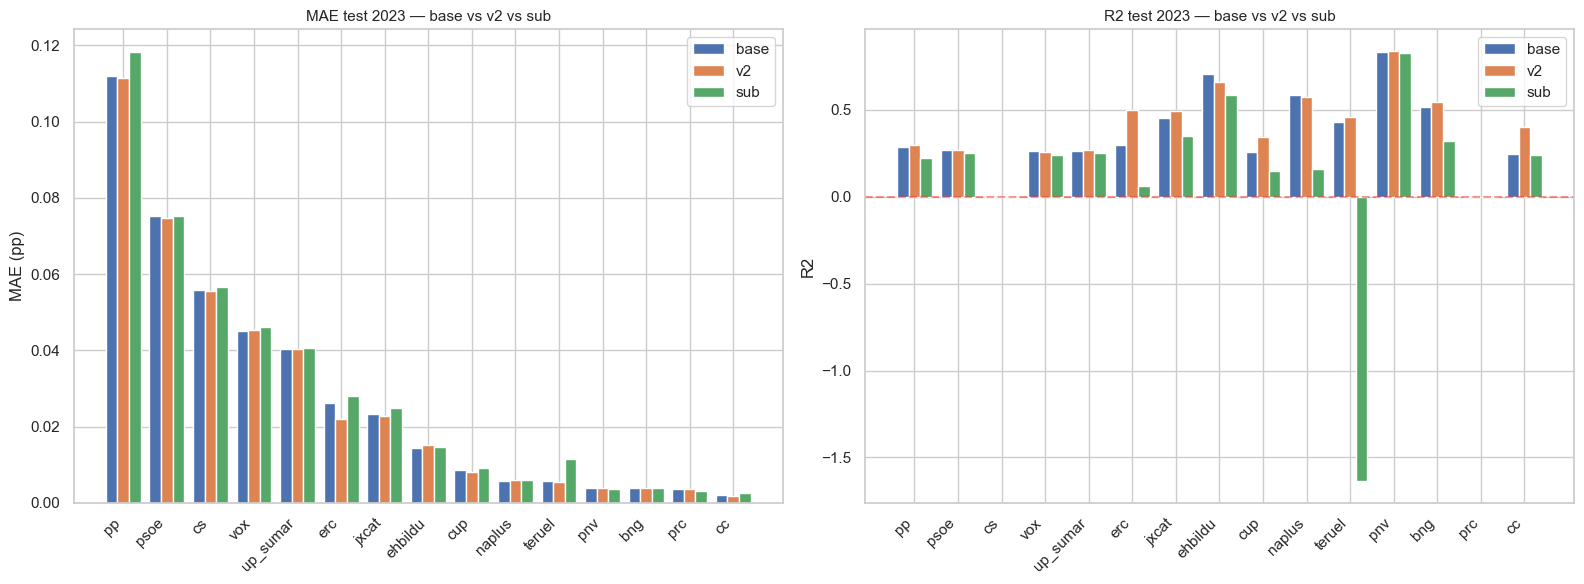


TABLA COMPARATIVA MAE TEST 2023
 partido  MAE_base  MAE_v2  MAE_sub
      pp    0.1121  0.1115   0.1183
    psoe    0.0752  0.0748   0.0753
      cs    0.0559  0.0557   0.0567
     vox    0.0451  0.0454   0.0461
up_sumar    0.0404  0.0403   0.0405
     erc    0.0262  0.0221   0.0280
   jxcat    0.0233  0.0228   0.0248
 ehbildu    0.0145  0.0151   0.0147
     cup    0.0085  0.0081   0.0092
  naplus    0.0057  0.0061   0.0059
  teruel    0.0057  0.0055   0.0116
     pnv    0.0039  0.0038   0.0036
     bng    0.0039  0.0039   0.0038
     prc    0.0037  0.0036   0.0031
      cc    0.0021  0.0018   0.0027


In [59]:
from modelos.evaluacion import comparar_metricas_modelos

df_cmp = comparar_metricas_modelos({
    "base": metricas_test,
    "v2":   metricas_test_v2,
    "sub":  metricas_test_sub,
})

### 5.4 D’Hondt con los modelos mejorados

In [60]:
from modelos.evaluacion import pipeline_comparacion_dhondt_modelos

esc_base = dict(zip(df_escanos["partido"], df_escanos["escanos_pred"]))
esc_real = dict(zip(df_escanos["partido"], df_escanos["escanos_real"]))

df_pred_v2, df_pred_sub, df_dhondt_cmp = pipeline_comparacion_dhondt_modelos(
    modelos, modelos_v2, modelos_sub,
    df_2023_completo, ruta_json_pob,
    esc_base, esc_real,
)

Paso 1: Prediciendo porcentajes (V2)...
Paso 2: Normalizando...
  Desviacion media de la suma respecto a 1.0: 2.76e-08
Paso 3: Convirtiendo a votos absolutos...
Prediccion V2 completada: 8131 municipios
Normalizando predicciones subgrupos...
  Desviacion media de la suma respecto a 1.0: 3.05e-08
Prediccion subgrupos completada: 8131 municipios
ESCANOS: real vs base vs v2 vs sub
 partido  real  base  v2  sub
      pp   136    96  94   90
    psoe   122   123 124  124
     vox    33    44  44   46
up_sumar    31    48  48   47
   jxcat     7     5   5    5
     erc     7    11  11   10
 ehbildu     6     4   4    5
     pnv     5     6   6    6
  naplus     1     1   1    1
      cc     1     0   0    0
     bng     1     0   0    0
     cup     0     0   1    1
      cs     0    10  10   10
     prc     0     1   1    1
  teruel     0     1   1    4

MAE escanos base: 6.13
MAE escanos v2: 6.40
MAE escanos sub: 6.80


### 5.5 Accuracy del partido ganador por municipio

El MAE de escaños no captura si el modelo acierta *qué partido gana* en cada municipio,
que es exactamente lo que muestra el mapa. Esta métrica mide eso directamente.

En 2023 el 33% de municipios cambió de partido ganador respecto a 2019.
Un modelo que siempre prediciera el ganador de 2019 tendría accuracy ~67%.

ACCURACY DEL PARTIDO GANADOR POR MUNICIPIO (test 2023)
----------------------------------------------------
  Baseline         61.3%  (4984 / 8131 municipios)
  V2 (+grupo)      61.7%  (5013 / 8131 municipios)
  Subgrupos        60.3%  (4903 / 8131 municipios)

RECALL POR PARTIDO (% municipios que gana en realidad y el modelo acierta)
------------------------------------------------------------
 partido  n_real  recall_baseline  recall_v2_grupo  recall_subgrupos
      pp    4466            0.607            0.611             0.598
    psoe    2756            0.734            0.740             0.721
   jxcat     295            0.159            0.122             0.149
 ehbildu     261            0.207            0.218             0.249
     erc     163            0.429            0.454             0.380
     pnv      76            0.934            0.934             0.921
up_sumar      51            0.078            0.078             0.059
     vox      36            0.083            0.056

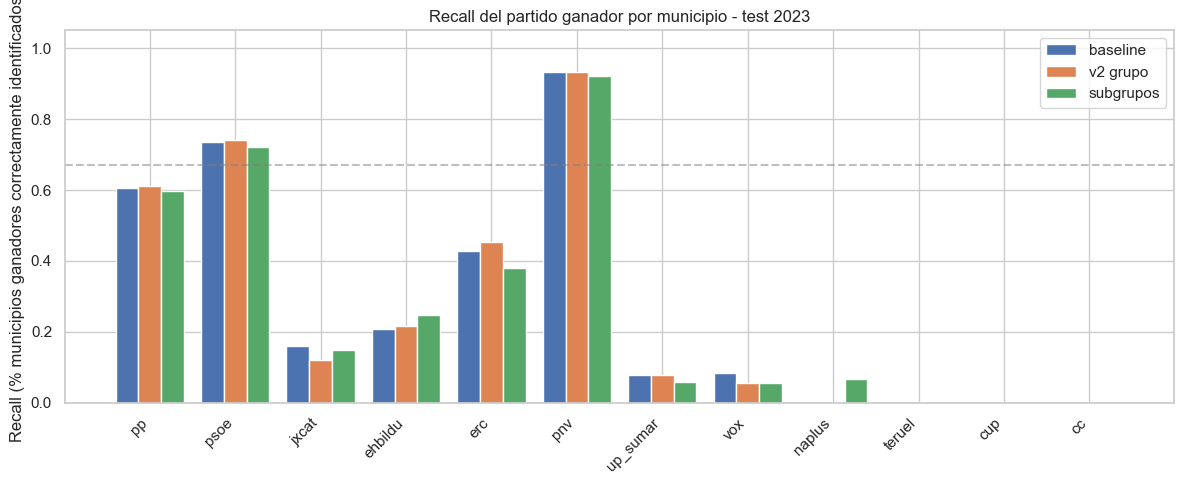

In [61]:
from modelos.evaluacion import evaluar_accuracy_ganador

df_acc = evaluar_accuracy_ganador(
    df_2023_completo,
    {
        "Baseline":    df_predicciones_2023,
        "V2 (+grupo)": df_pred_v2,
        "Subgrupos":   df_pred_sub,
    },
)

Recall del partido ganador

PP: 60% — por debajo del naive (línea gris 67%)
Este es el resultado más importante. El modelo acierta el ganador en solo 6 de cada 10 municipios donde PP ganó en 2023. Es PEOR que simplemente predecir siempre el ganador de 2019. La razón: el efecto Feijóo hizo que PP ganara en miles de municipios que en 2019 ganaba PSOE, y el modelo no lo anticipa porque ninguna variable socioeconómica cambió en esos municipios de forma diferencial.

PSOE: 73% — el único grande por encima del naive
Es el partido más estructuralmente estable. El modelo predice bien dónde gana PSOE porque su geografía electoral lleva décadas correlacionada con los mismos indicadores socioeconómicos.

PNV: 93% — prácticamente perfecto
Aquí el model acierta siempre. La razón es provincia_enc: el modelo aprendió que las provincias 01 (Álava), 20 (Gipuzkoa) y 48 (Bizkaia) → PNV, y eso es prácticamente determinístico.

ERC: 43%
Refleja el colapso de ERC: pasó de ganar en 621 municipios (2019) a solo 163 (2023). El modelo aún "cree" que ERC gana en más sitios de Cataluña de los que realmente ganó.

JxCat: 12-16%, EH Bildu: 21-25%
Muy bajos. Ambos ganaron municipios a costa de sus rivales internos de bloque (ERC y PNV respectivamente). Esto es dinámica política pura, sin explicación socioeconómica.

VOX, Sumar, Naplus: 5-9%
El modelo casi nunca predice que estos partidos ganan un municipio, porque en 2019 apenas ganaban ninguno y el modelo aprendió eso.

Los tres modelos son prácticamente idénticos en todas las barras → confirma que la mejora A y E no cambian la capacidad predictiva. El techo es estructural.

### 5.6 Mapa de error provincial del PP

El PP es el partido con mayor error de prediccion. Este mapa muestra
en qué provincias el modelo subestima más el voto del PP (azul oscuro = mayor
subestimacion). Permite localizar geográficamente el efecto Feijoo.

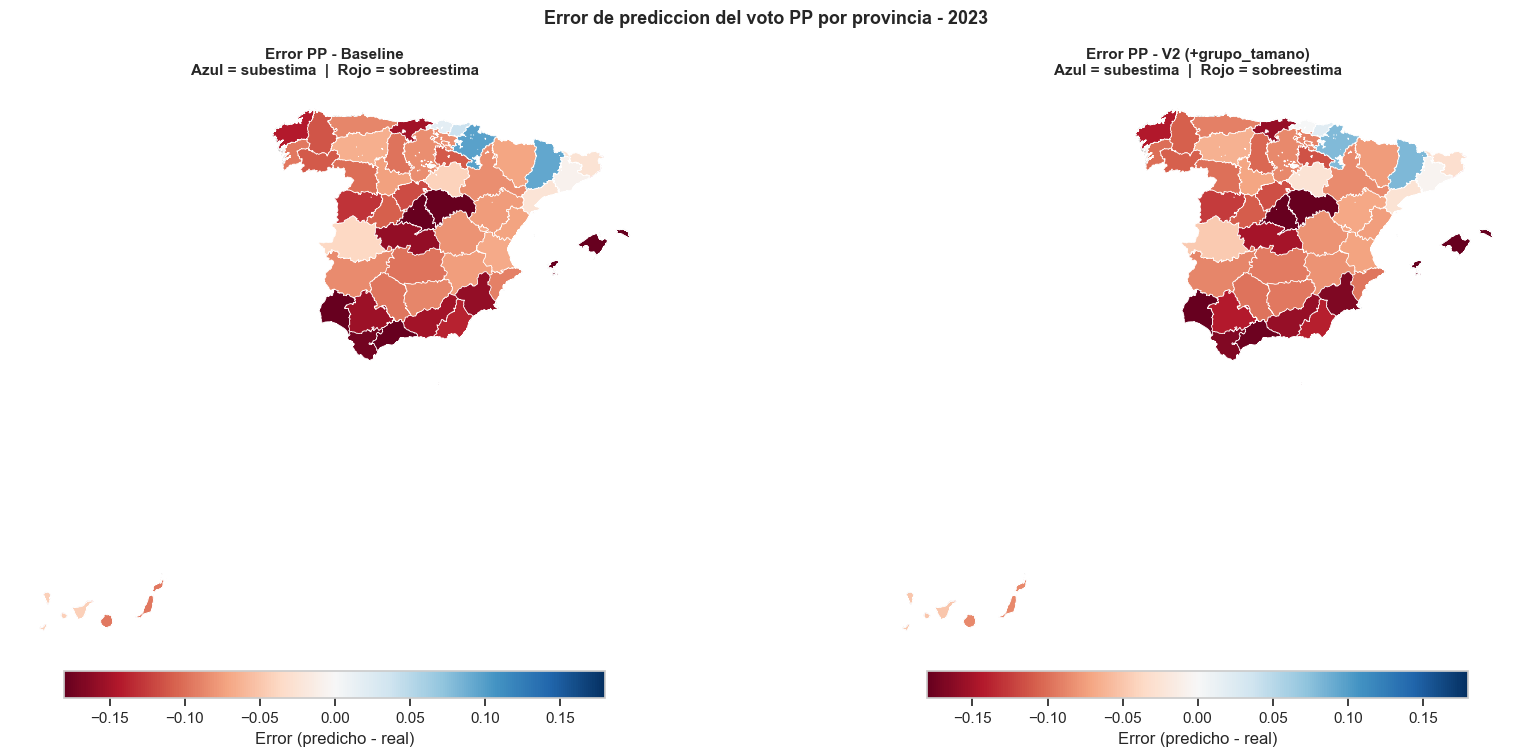

TOP 10 PROVINCIAS con mayor error en PP (Baseline):
cod_prov  error  error_abs
      19 -0.255      0.255
      07 -0.251      0.251
      28 -0.218      0.218
      52 -0.204      0.204
      21 -0.189      0.189
      51 -0.188      0.188
      29 -0.183      0.183
      11 -0.173      0.173
      30 -0.158      0.158
      45 -0.158      0.158


In [62]:
from calculos_electorales.visualizacion import mapa_error_partido

mapa_error_partido(
    [
        ("Baseline",         df_predicciones_2023),
        ("V2 (+grupo_tamano)", df_pred_v2),
    ],
    df_2023_completo,
    ruta_parquet="data_processed/geografia/mapa_municipios.parquet",
    partido="pp",
)

El modelo sobreestima PP en los pequeños municipios rurales (la mayoría del mapa). En 2019, PP ya era fuerte en el interior rural (39% en municipios <100 hab). El modelo aprendió eso y lo aplica igual a 2023. Pero en 2023, en esos municipios PP ya estaba saturado — VOX aguantó más de lo esperado, y el modelo predice más PP del que hubo.

El modelo subestima PP en las ciudades grandes (provincias azules: País Vasco, Girona, Barcelona, probablemente Madrid). En 2023, el PP urbano creció masivamente — de ~20% a ~30% en ciudades. El modelo predice los niveles de 2019 (~20%). Error grande en pocas provincias pero muy pobladas.

El D'Hondt amplifica el error urbano, no el rural. Madrid, Barcelona, Valencia reparten 30-40 escaños cada una. Si el modelo falla −10pp en PP en esas provincias, pierde decenas de escaños. Los pueblos de 50 habitantes apenas aportan 0 escaños aunque el modelo los prediga perfectamente.

### 5.7 Experimento contrafactual: modelo sin Ciudadanos

En 2019, Cs obtuvo ~5% del voto. En 2023, colapsó a ~0%. El modelo baseline
no sabe esto y predice 10 escaños fantasma para Cs, que restan a PP.

**Hipótesis**: si al entrenar fusionamos los votos de Cs dentro de PP
(como si ya supieramos que Cs no sería viable), el modelo aprende directamente
el perfil del votante PP+ex-Cs y predice mejor.

Esto permite descomponer el error de PP en dos causas:
- **Causa A** (cuantificable): votos de Cs que en 2023 fueron a PP
- **Causa B** (no predecible): efecto Feijoo puro, crecimiento más allá de Cs

In [63]:
from modelos.contrafactual import entrenar_modelos_sin_cs

modelos_sin_cs = entrenar_modelos_sin_cs(df_2019_completo)

ENTRENAMIENTO — modelo con conocimiento previo de candidaturas
  Cs  fusionada en PP   (Cs -> PP)
  PRC fusionada en PSOE (PRC no se presenta -> PSOE)
Municipios train: 8131

  pct_psoe             MAE train = 0.0365
  pct_pp               MAE train = 0.0349
  pct_vox              MAE train = 0.0236
  pct_up_sumar         MAE train = 0.0203
  pct_erc              MAE train = 0.0027
  pct_jxcat            MAE train = 0.0027
  pct_cup              MAE train = 0.0015
  pct_pnv              MAE train = 0.0001
  pct_ehbildu          MAE train = 0.0017
  pct_bng              MAE train = 0.0004
  pct_cc               MAE train = 0.0002
  pct_naplus           MAE train = 0.0012
  pct_teruel           MAE train = 0.0007

Modelos sin_cs guardados en 'modelos/modelos_sin_cs/'


In [64]:
from modelos.evaluacion import evaluar_modelos
from modelos.contrafactual import preparar_dataset_sin_cs

df_2019_sin_cs = preparar_dataset_sin_cs(df_2019_completo)

# En 2023, pct_cs ya es ~0 en realidad, no hace falta modificar el test
metricas_train_sin_cs = evaluar_modelos(modelos_sin_cs, df_2019_sin_cs, etiqueta="2019 sin Cs (train)")
metricas_test_sin_cs  = evaluar_modelos(modelos_sin_cs, df_2023_completo, etiqueta="2023 sin Cs (test)")

# Comparativa directa en pp
print("\nCOMPARATIVA PP — MAE test 2023")
print("  Baseline  pct_pp MAE:", metricas_test.loc[metricas_test.partido=="pp","MAE"].values[0])
print("  Sin Cs    pct_pp MAE:", metricas_test_sin_cs.loc[metricas_test_sin_cs.partido=="pp","MAE"].values[0])


METRICAS — 2019 sin Cs (train)
 partido    MAE   RMSE     R2  media_real
     pnv 0.0001 0.0008 0.9999      0.0116
      cc 0.0002 0.0006 0.9989      0.0018
     bng 0.0004 0.0010 0.9964      0.0029
  teruel 0.0007 0.0027 0.9952      0.0058
  naplus 0.0012 0.0037 0.9955      0.0093
     cup 0.0015 0.0037 0.9900      0.0116
 ehbildu 0.0017 0.0052 0.9958      0.0178
     erc 0.0027 0.0062 0.9964      0.0362
   jxcat 0.0027 0.0063 0.9950      0.0293
up_sumar 0.0203 0.0279 0.8517      0.0985
     vox 0.0236 0.0319 0.8612      0.1423
      pp 0.0349 0.0475 0.9255      0.3240
    psoe 0.0365 0.0486 0.8717      0.2926

METRICAS — 2023 sin Cs (test)
 partido    MAE   RMSE     R2  media_real
      cc 0.0021 0.0158 0.2453      0.0017
     pnv 0.0039 0.0221 0.8332      0.0092
     bng 0.0039 0.0131 0.5144      0.0035
  naplus 0.0057 0.0198 0.5885      0.0050
  teruel 0.0057 0.0215 0.4324      0.0058
     cup 0.0085 0.0202 0.2566      0.0065
 ehbildu 0.0145 0.0480 0.7060      0.0200
   jxcat 0.02

In [65]:
from modelos.contrafactual import pipeline_comparacion_contrafactual
from calculos_electorales.dhondt import escanos_por_provincia

dict_esc = escanos_por_provincia(ruta_json_pob)

df_cmp_cs = pipeline_comparacion_contrafactual(
    modelos_sin_cs, df_2023_completo, dict_esc, esc_base, esc_real
)

Paso 1: Prediciendo porcentajes por municipio...
Paso 2: Normalizando (calculando pct_otros como residuo)...
  Desviacion media de la suma respecto a 1.0: 3.08e-08
Paso 3: Convirtiendo a votos absolutos con votos totales reales...
Prediccion completada: 8131 municipios
ESCANOS: real vs baseline vs sin Cs+PRC
 partido  real  baseline  sin_cs_prc
      pp   136        96         121
    psoe   122       123         117
     vox    33        44          40
up_sumar    31        48          45
   jxcat     7         5           4
     erc     7        11          11
 ehbildu     6         4           4
     pnv     5         6           6
  naplus     1         1           1
      cc     1         0           0
     bng     1         0           0
     cup     0         0           0
      cs     0        10           0
     prc     0         1           0
  teruel     0         1           1

MAE escanos Baseline: 6.13
MAE escanos Sin Cs+PRC: 3.60

Descomposicion error PP:
  Error baselin

Visualización del escenario sin Ciudadanos — hemiciclo y mapa provincial.

  VISUALIZACIÓN DE RESULTADOS ELECTORALES

[1/4] Prediciendo votos por municipio...
Paso 1: Prediciendo porcentajes por municipio...


Paso 2: Normalizando (calculando pct_otros como residuo)...
  Desviacion media de la suma respecto a 1.0: 3.08e-08
Paso 3: Convirtiendo a votos absolutos con votos totales reales...
Prediccion completada: 8131 municipios
[2/4] Agregando a nivel provincial...
[3/4] Calculando D'Hondt y ganadores por provincia...
[4/4] Generando gráficos...


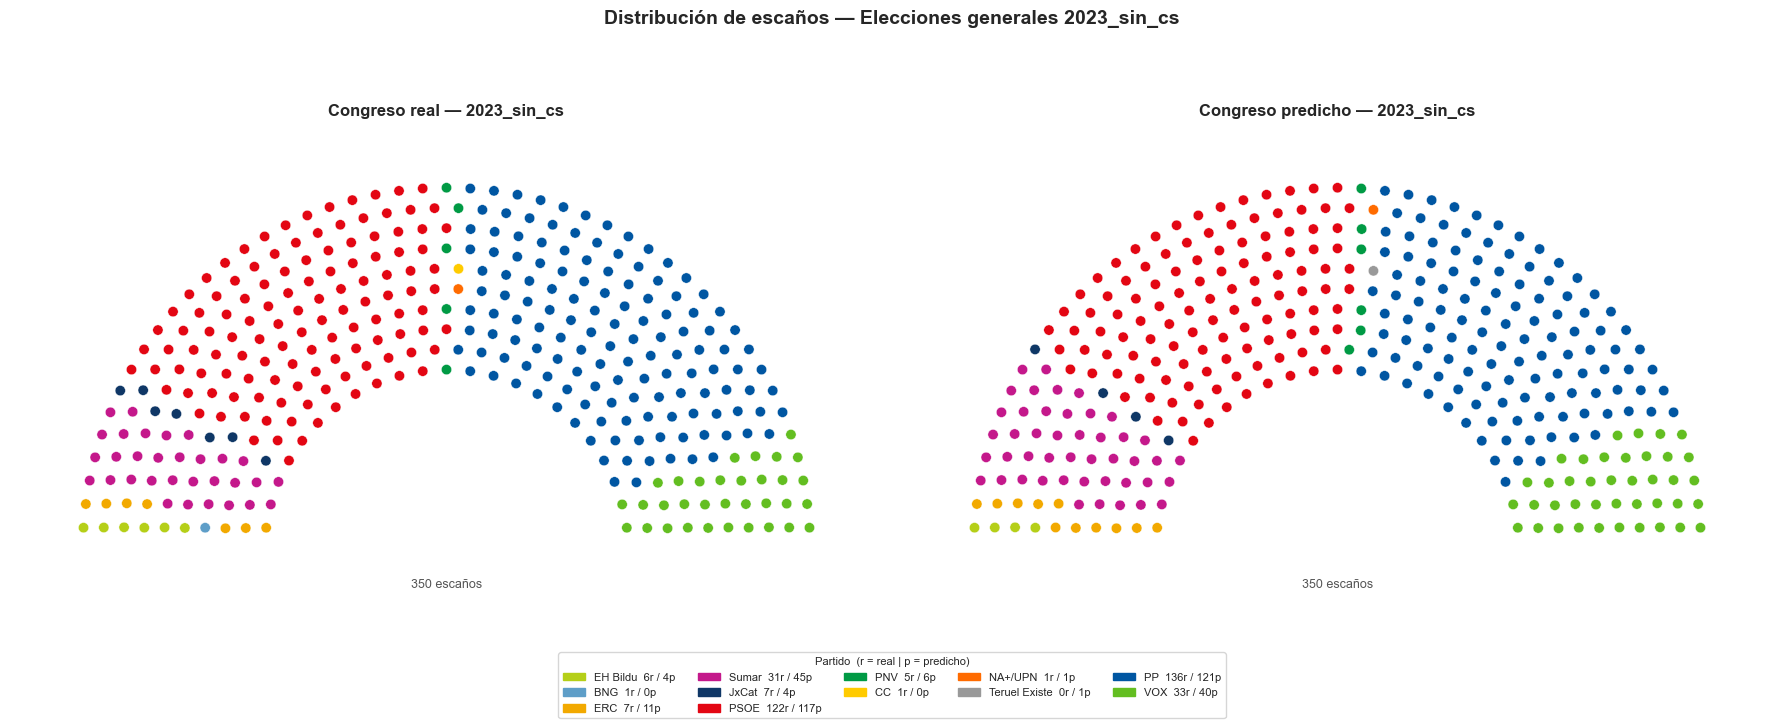

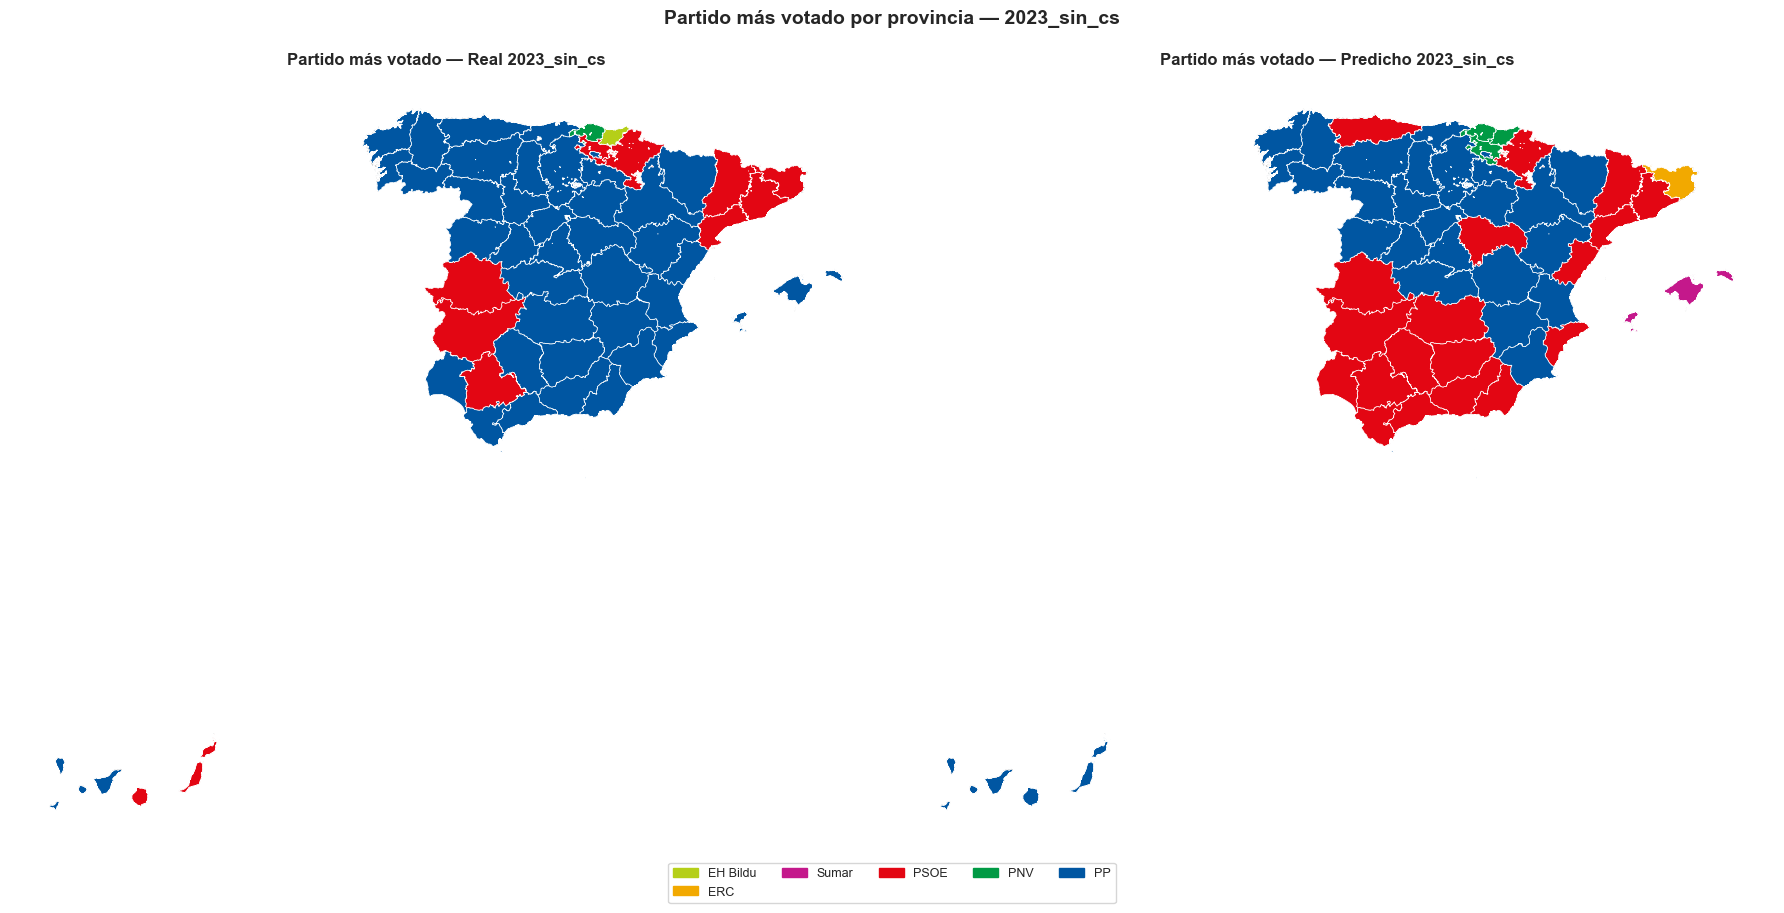


Listo. Imágenes en documentation/imagenes_EDA


In [66]:
from calculos_electorales.visualizacion import pipeline_visualizacion

pipeline_visualizacion(
    modelos_sin_cs,
    df_2023_completo,
    ruta_json_pob,
    ruta_parquet,
    etiqueta="2023_sin_cs",
    guardar=True,
)